In [10]:
# ============================================================
# Stage 7 — Scaling effect of temporal effective networks
# Round 1: full-redraw activity-driven temporal network
# ============================================================
#
# Goal
# ----
# Generate one stationary activity-driven temporal network
#
#     A_0, A_1, ..., A_{L-1}
#
# with complete edge redraw at every microscopic snapshot.
#
# Microscopic dynamics on snapshot k:
#
#     dx/dt = K_k x,
#     K_k = -kappa * L_k
#
# where L_k is the graph Laplacian.
#
# For a temporal window containing n snapshots, F_eff will be
# computed FORWARD from the known sequence of microscopic
# generators, using a BCH / Magnus expansion.
#
# Round 1:
#   - full Perra-style redraw between snapshots;
#   - fixed heterogeneous node activities;
#   - fixed microscopic dynamical law;
#   - no TIF reconstruction;
#   - no inverse inference;
#   - study how F_eff changes with observation scale.
#
# Main hierarchy:
#
#     4 -> 8 -> 16 -> 32 snapshots
#
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import sparse
from scipy.linalg import expm, logm
from pathlib import Path


# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

SEED = 20260828
rng = np.random.default_rng(SEED)


# ------------------------------------------------------------
# System size
# ------------------------------------------------------------

N = 100


# ------------------------------------------------------------
# Activity-driven temporal network
# ------------------------------------------------------------
#
# Perra-style activity potential:
#
#     F(x) ~ x^{-gamma},
#     xmin <= x <= xmax
#
# Each active node creates Q_LINKS random links.
#
# The global activity scale eta is NOT fixed here.
# It will be calibrated in Cell 1 so that the realized
# instantaneous network has approximately
#
#     <k>_snapshot = TARGET_MEAN_DEGREE.
#
# ------------------------------------------------------------

GAMMA = 2.8
XMIN = 1e-3
XMAX = 1.0

Q_LINKS = 2

# Target instantaneous mean degree.
# Perra Fig. 3 is approximately <k> ~ 0.09.
TARGET_MEAN_DEGREE = 0.10


# ------------------------------------------------------------
# Microscopic temporal scale
# ------------------------------------------------------------

# Duration for which each generated topology is held fixed
# in the continuous-time dynamical system.
TAU_SNAPSHOT = 0.05

# Pilot realization.
N_SNAPSHOTS = 128

TOTAL_TIME = N_SNAPSHOTS * TAU_SNAPSHOT


# ------------------------------------------------------------
# Microscopic dynamics
# ------------------------------------------------------------
#
# Linear consensus:
#
#     dx_i/dt = kappa * sum_j A_ij(t) (x_j - x_i)
#
# or
#
#     dx/dt = K(t) x,
#     K(t) = -kappa L(t)
#
# ------------------------------------------------------------

KAPPA = 1.0


# ------------------------------------------------------------
# Observation-window hierarchy
# ------------------------------------------------------------
#
# Main multiscale sweep:
#
#     4 -> 8 -> 16 -> 32
#
# All scales divide 128 exactly, which gives a clean
# nested dyadic hierarchy.
# ------------------------------------------------------------

WINDOW_SIZES = np.array(
    [2, 4, 8, 16, 32],
    dtype=int
)

WINDOW_TIMES = WINDOW_SIZES * TAU_SNAPSHOT

assert np.all(N_SNAPSHOTS % WINDOW_SIZES == 0)
assert WINDOW_SIZES.max() <= N_SNAPSHOTS


# ------------------------------------------------------------
# Diagnostic scales
# ------------------------------------------------------------

# Useful later for checking the microscopic and first
# composition levels, but not part of the main figures.
DEBUG_WINDOW_SIZES = np.array([1, 2], dtype=int)


# ------------------------------------------------------------
# BCH / Magnus bookkeeping
# ------------------------------------------------------------
#
# We will initially compare:
#
#   order 0 : naive temporal average
#   order 1 : + first commutator sector
#   order 2 : + nested-commutator sector
#
# Exact dense expm/logm calculations will only be used
# for small-N calibration / sanity checks if needed.
# ------------------------------------------------------------

MAX_BCH_ORDER = 2


# ------------------------------------------------------------
# Numerical tolerances
# ------------------------------------------------------------

IMAG_TOL = 1e-9
ROW_SUM_TOL = 1e-9
COEFF_TOL = 1e-10


# ------------------------------------------------------------
# Output
# ------------------------------------------------------------

OUTDIR = Path("./stage7_scaling_outputs")
OUTDIR.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# Configuration summary
# ------------------------------------------------------------

print("Stage 7 / Round 1 — pilot")
print("=========================")

print()
print("System")
print("------")
print(f"N                         = {N}")

print()
print("Activity-driven network")
print("-----------------------")
print(f"gamma                     = {GAMMA}")
print(f"x range                    = [{XMIN}, {XMAX}]")
print(f"links per active node q   = {Q_LINKS}")
print(f"target snapshot <k>       = {TARGET_MEAN_DEGREE}")

print()
print("Temporal structure")
print("------------------")
print(f"N snapshots               = {N_SNAPSHOTS}")
print(f"snapshot duration tau     = {TAU_SNAPSHOT}")
print(f"total time                = {TOTAL_TIME:.3f}")

print()
print("Dynamics")
print("--------")
print(f"consensus coupling kappa  = {KAPPA}")
print(f"max BCH order             = {MAX_BCH_ORDER}")

print()
print("Observation hierarchy")
print("---------------------")

for n, t in zip(WINDOW_SIZES, WINDOW_TIMES):
    n_sliding = N_SNAPSHOTS - n + 1
    n_nonoverlap = N_SNAPSHOTS // n

    print(
        f"{n:3d} snapshots"
        f" | time = {t:4.2f}"
        f" | sliding = {n_sliding:3d}"
        f" | non-overlap = {n_nonoverlap:2d}"
    )

print()
print("Exact dyadic nesting:")
for n in WINDOW_SIZES[:-1]:
    print(f"  {n:2d} -> {2*n:2d}")

Stage 7 / Round 1 — pilot

System
------
N                         = 100

Activity-driven network
-----------------------
gamma                     = 2.8
x range                    = [0.001, 1.0]
links per active node q   = 2
target snapshot <k>       = 0.1

Temporal structure
------------------
N snapshots               = 128
snapshot duration tau     = 0.05
total time                = 6.400

Dynamics
--------
consensus coupling kappa  = 1.0
max BCH order             = 2

Observation hierarchy
---------------------
  2 snapshots | time = 0.10 | sliding = 127 | non-overlap = 64
  4 snapshots | time = 0.20 | sliding = 125 | non-overlap = 32
  8 snapshots | time = 0.40 | sliding = 121 | non-overlap = 16
 16 snapshots | time = 0.80 | sliding = 113 | non-overlap =  8
 32 snapshots | time = 1.60 | sliding =  97 | non-overlap =  4

Exact dyadic nesting:
   2 ->  4
   4 ->  8
   8 -> 16
  16 -> 32


Activity landscape

Activity potential
------------------
mean(x)                    = 0.001849
median(x)                  = 0.001465
min(x)                     = 0.001007
max(x)                     = 0.005788

Calibrated activity scale
-------------------------
target mean degree         = 0.100
eta                        = 13.518
mean p(active)             = 0.02500
max  p(active)             = 0.07825

Expected snapshot statistics
----------------------------
expected active nodes      = 2.500 / 100
expected active fraction   = 0.0250
expected edge attempts     = 5.000
expected mean degree       = 0.100
P(no active nodes)         = 0.0786
expected empty snapshots   = 10.06 / 128

Reference scale
---------------
Perra Fig. 3 used eta = 10 and had <k> ≈ 0.09.
Our calibrated eta        = 13.518


,node,x,p_active
0,59,0.005788,0.078249
1,95,0.005599,0.075694
2,39,0.005462,0.073835
3,27,0.005277,0.071337
4,93,0.005162,0.069783
5,65,0.004545,0.061434
6,72,0.004434,0.059944
7,4,0.003391,0.045835
8,25,0.003338,0.045129
9,15,0.003238,0.043773


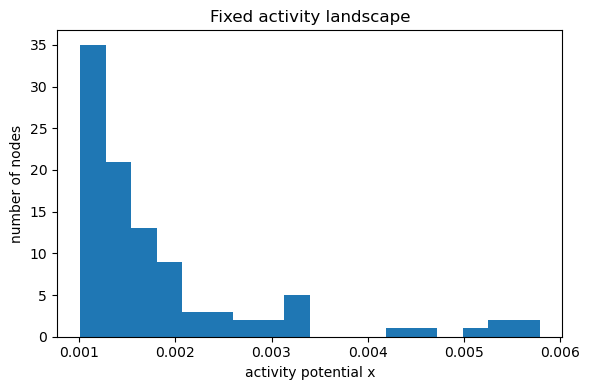

In [11]:
# ============================================================
# Cell 1 — Activity landscape and density calibration
# ============================================================
#
# Draw one fixed heterogeneous activity landscape:
#
#     F(x) ~ x^{-gamma},
#     xmin <= x <= xmax.
#
# One snapshot corresponds to one discrete activity-driven
# network update.
#
# Node i is active with probability
#
#     p_i = eta * x_i.
#
# We choose eta AFTER drawing the activity landscape so that
#
#     <k>_snapshot ≈ TARGET_MEAN_DEGREE.
#
# For the activity-driven model,
#
#     <k>_snapshot ≈ 2 q eta <x>,
#
# hence
#
#     eta = TARGET_MEAN_DEGREE / (2 q <x>).
#
# Note:
# this relation counts edge attempts. Duplicate / reciprocal
# choices can make the realized unique-edge mean degree
# slightly smaller. Cell 2 will measure the actual value.
# ============================================================


def sample_truncated_powerlaw(
    rng,
    size,
    gamma,
    xmin,
    xmax
):
    """
    Sample x from

        p(x) ~ x^{-gamma}

    on [xmin, xmax] using inverse-transform sampling.
    """

    u = rng.random(size)

    if np.isclose(gamma, 1.0):
        return xmin * (xmax / xmin) ** u

    power = 1.0 - gamma

    return (
        xmin**power
        + u * (xmax**power - xmin**power)
    ) ** (1.0 / power)


# ------------------------------------------------------------
# Fixed activity landscape
# ------------------------------------------------------------

activity_x = sample_truncated_powerlaw(
    rng=rng,
    size=N,
    gamma=GAMMA,
    xmin=XMIN,
    xmax=XMAX,
)


# ------------------------------------------------------------
# Calibrate global activity scale eta
# ------------------------------------------------------------

ETA = (
    TARGET_MEAN_DEGREE
    / (2.0 * Q_LINKS * activity_x.mean())
)

p_active = ETA * activity_x


# ------------------------------------------------------------
# Probability validity check
# ------------------------------------------------------------

if np.any(p_active > 1.0):
    offending = np.where(p_active > 1.0)[0]

    raise ValueError(
        "Some activation probabilities exceed 1. "
        f"Number offending = {len(offending)}. "
        "Reduce TARGET_MEAN_DEGREE."
    )


# ------------------------------------------------------------
# Expected microscopic snapshot statistics
# ------------------------------------------------------------

expected_active_nodes = np.sum(p_active)

expected_active_fraction = (
    expected_active_nodes / N
)

# Each active node attempts q links.
expected_edge_attempts = (
    Q_LINKS * expected_active_nodes
)

# Approximation before duplicate / reciprocal edge removal.
expected_mean_degree = (
    2.0 * expected_edge_attempts / N
)

# Exact probability, conditional on this realized
# heterogeneous activity landscape, that no node activates.
prob_no_active_nodes = np.prod(
    1.0 - p_active
)

# Approximate number of empty snapshots in this pilot.
expected_empty_snapshots = (
    N_SNAPSHOTS * prob_no_active_nodes
)


# ------------------------------------------------------------
# Report
# ------------------------------------------------------------

print("Activity landscape")
print("==================")

print()
print("Activity potential")
print("------------------")
print(f"mean(x)                    = {activity_x.mean():.6f}")
print(f"median(x)                  = {np.median(activity_x):.6f}")
print(f"min(x)                     = {activity_x.min():.6f}")
print(f"max(x)                     = {activity_x.max():.6f}")

print()
print("Calibrated activity scale")
print("-------------------------")
print(f"target mean degree         = {TARGET_MEAN_DEGREE:.3f}")
print(f"eta                        = {ETA:.3f}")
print(f"mean p(active)             = {p_active.mean():.5f}")
print(f"max  p(active)             = {p_active.max():.5f}")

print()
print("Expected snapshot statistics")
print("----------------------------")
print(
    f"expected active nodes      = "
    f"{expected_active_nodes:.3f} / {N}"
)
print(
    f"expected active fraction   = "
    f"{expected_active_fraction:.4f}"
)
print(
    f"expected edge attempts     = "
    f"{expected_edge_attempts:.3f}"
)
print(
    f"expected mean degree       = "
    f"{expected_mean_degree:.3f}"
)
print(
    f"P(no active nodes)         = "
    f"{prob_no_active_nodes:.4f}"
)
print(
    f"expected empty snapshots   = "
    f"{expected_empty_snapshots:.2f} / {N_SNAPSHOTS}"
)


# ------------------------------------------------------------
# Perra reference
# ------------------------------------------------------------

print()
print("Reference scale")
print("---------------")
print("Perra Fig. 3 used eta = 10 and had <k> ≈ 0.09.")
print(
    f"Our calibrated eta        = {ETA:.3f}"
)


# ------------------------------------------------------------
# Activity table
# ------------------------------------------------------------

activity_df = pd.DataFrame({
    "node": np.arange(N),
    "x": activity_x,
    "p_active": p_active,
})

activity_df = (
    activity_df
    .sort_values("x", ascending=False)
    .reset_index(drop=True)
)

display(activity_df.head(10))


# ------------------------------------------------------------
# Visualization
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(6, 4))

ax.hist(
    activity_x,
    bins=18
)

ax.set_xlabel("activity potential x")
ax.set_ylabel("number of nodes")
ax.set_title("Fixed activity landscape")

plt.tight_layout()
plt.show()

Realized microscopic temporal network

Snapshot activity
-----------------
mean active nodes          = 2.562
std active nodes           = 1.446
empty snapshots            = 6 / 128
empty fraction             = 0.0469

Snapshot edges
--------------
mean unique edges          = 5.125
std unique edges           = 2.892
min / max unique edges     = 0 / 16
mean realized degree       = 0.1025

Consecutive redraw
------------------
mean shared edges          = 0.0236
fraction with no overlap   = 0.9764
mean symmetric difference  = 10.205
mean edge Jaccard          = 0.00300


,snapshot,n_active,n_edges,mean_degree,empty
0,0,2,4,0.08,False
1,1,2,4,0.08,False
2,2,3,6,0.12,False
3,3,2,4,0.08,False
4,4,3,6,0.12,False
5,5,5,10,0.20,False
6,6,1,2,0.04,False
7,7,4,8,0.16,False
8,8,3,6,0.12,False
9,9,5,10,0.20,False


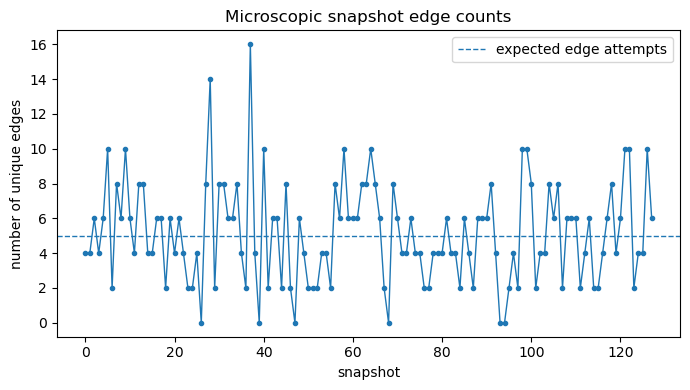

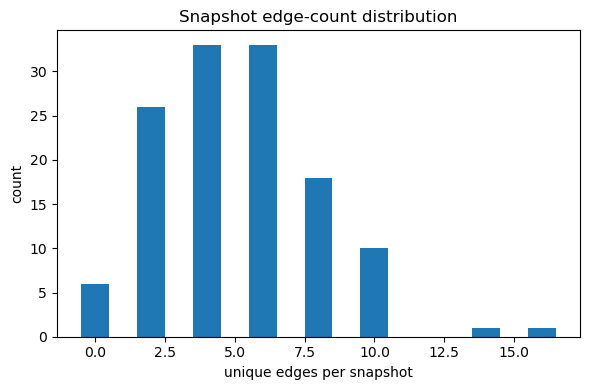

In [12]:
# ============================================================
# Cell 2 — Generate full-redraw microscopic snapshots
# ============================================================
#
# For each snapshot:
#
#   1. start from an empty graph;
#   2. activate node i independently with probability p_active[i];
#   3. each active node chooses Q_LINKS distinct random targets;
#   4. treat all links as undirected;
#   5. duplicate / reciprocal edge attempts collapse to one edge;
#   6. discard the entire graph before generating the next snapshot.
#
# We store:
#
#   - edge sets, for structural auditing;
#   - sparse adjacency matrices, for later generator/BCH analysis.
# ============================================================


def generate_activity_snapshot(
    rng,
    N,
    p_active,
    q_links
):
    """
    Generate one undirected activity-driven snapshot.

    Returns
    -------
    active_nodes : ndarray
        Nodes activated in this snapshot.

    edges : set[tuple[int, int]]
        Unique undirected edges represented as (min(i,j), max(i,j)).

    A : scipy.sparse.csr_matrix
        Sparse symmetric adjacency matrix.
    """

    # --------------------------------------------------------
    # Activate nodes
    # --------------------------------------------------------

    active_mask = rng.random(N) < p_active
    active_nodes = np.flatnonzero(active_mask)

    # --------------------------------------------------------
    # Generate edges
    # --------------------------------------------------------

    edges = set()

    all_nodes = np.arange(N)

    for i in active_nodes:

        # Candidate targets exclude self
        candidates = all_nodes[all_nodes != i]

        q_eff = min(q_links, len(candidates))

        targets = rng.choice(
            candidates,
            size=q_eff,
            replace=False
        )

        for j in targets:

            u, v = sorted((int(i), int(j)))
            edges.add((u, v))

    # --------------------------------------------------------
    # Sparse adjacency
    # --------------------------------------------------------

    if len(edges) == 0:

        A = sparse.csr_matrix(
            (N, N),
            dtype=float
        )

    else:

        rows = []
        cols = []

        for u, v in edges:
            rows.extend([u, v])
            cols.extend([v, u])

        data = np.ones(len(rows), dtype=float)

        A = sparse.csr_matrix(
            (data, (rows, cols)),
            shape=(N, N)
        )

    return active_nodes, edges, A


# ------------------------------------------------------------
# Generate the complete temporal sequence
# ------------------------------------------------------------

active_nodes_by_snapshot = []
edge_sets = []
adjacency_snapshots = []

for t in range(N_SNAPSHOTS):

    active_nodes, edges, A = generate_activity_snapshot(
        rng=rng,
        N=N,
        p_active=p_active,
        q_links=Q_LINKS
    )

    active_nodes_by_snapshot.append(active_nodes)
    edge_sets.append(edges)
    adjacency_snapshots.append(A)


# ------------------------------------------------------------
# Basic realized statistics
# ------------------------------------------------------------

n_active_realized = np.array([
    len(nodes)
    for nodes in active_nodes_by_snapshot
])

n_edges_realized = np.array([
    len(edges)
    for edges in edge_sets
])

mean_degree_realized = (
    2.0 * n_edges_realized / N
)

empty_snapshots = (
    n_edges_realized == 0
)


# ------------------------------------------------------------
# Consecutive-snapshot edge statistics
# ------------------------------------------------------------

shared_edges = []
symmetric_difference = []
edge_jaccard = []

for t in range(N_SNAPSHOTS - 1):

    E0 = edge_sets[t]
    E1 = edge_sets[t + 1]

    intersection = E0 & E1
    union = E0 | E1
    symdiff = E0 ^ E1

    shared_edges.append(
        len(intersection)
    )

    symmetric_difference.append(
        len(symdiff)
    )

    if len(union) == 0:
        edge_jaccard.append(np.nan)
    else:
        edge_jaccard.append(
            len(intersection) / len(union)
        )

shared_edges = np.asarray(shared_edges)
symmetric_difference = np.asarray(
    symmetric_difference
)
edge_jaccard = np.asarray(edge_jaccard)


# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

print("Realized microscopic temporal network")
print("=====================================")

print()
print("Snapshot activity")
print("-----------------")
print(
    f"mean active nodes          = "
    f"{n_active_realized.mean():.3f}"
)
print(
    f"std active nodes           = "
    f"{n_active_realized.std(ddof=1):.3f}"
)
print(
    f"empty snapshots            = "
    f"{empty_snapshots.sum()} / {N_SNAPSHOTS}"
)
print(
    f"empty fraction             = "
    f"{empty_snapshots.mean():.4f}"
)

print()
print("Snapshot edges")
print("--------------")
print(
    f"mean unique edges          = "
    f"{n_edges_realized.mean():.3f}"
)
print(
    f"std unique edges           = "
    f"{n_edges_realized.std(ddof=1):.3f}"
)
print(
    f"min / max unique edges     = "
    f"{n_edges_realized.min()} / "
    f"{n_edges_realized.max()}"
)
print(
    f"mean realized degree       = "
    f"{mean_degree_realized.mean():.4f}"
)

print()
print("Consecutive redraw")
print("------------------")
print(
    f"mean shared edges          = "
    f"{shared_edges.mean():.4f}"
)
print(
    f"fraction with no overlap   = "
    f"{np.mean(shared_edges == 0):.4f}"
)
print(
    f"mean symmetric difference  = "
    f"{symmetric_difference.mean():.3f}"
)

finite_jaccard = edge_jaccard[
    np.isfinite(edge_jaccard)
]

if len(finite_jaccard) > 0:
    print(
        f"mean edge Jaccard          = "
        f"{finite_jaccard.mean():.5f}"
    )


# ------------------------------------------------------------
# Snapshot-level table
# ------------------------------------------------------------

snapshot_df = pd.DataFrame({
    "snapshot": np.arange(N_SNAPSHOTS),
    "n_active": n_active_realized,
    "n_edges": n_edges_realized,
    "mean_degree": mean_degree_realized,
    "empty": empty_snapshots,
})

display(snapshot_df.head(15))


# ------------------------------------------------------------
# Quick diagnostics
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(
    np.arange(N_SNAPSHOTS),
    n_edges_realized,
    marker="o",
    markersize=3,
    linewidth=1
)

ax.axhline(
    expected_edge_attempts,
    linestyle="--",
    linewidth=1,
    label="expected edge attempts"
)

ax.set_xlabel("snapshot")
ax.set_ylabel("number of unique edges")
ax.set_title("Microscopic snapshot edge counts")
ax.legend()

plt.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(6, 4))

ax.hist(
    n_edges_realized,
    bins=np.arange(
        n_edges_realized.max() + 2
    ) - 0.5
)

ax.set_xlabel("unique edges per snapshot")
ax.set_ylabel("count")
ax.set_title("Snapshot edge-count distribution")

plt.tight_layout()
plt.show()

In [13]:
# ============================================================
# Cell 3.5a — Visualization helper library
# ============================================================
#
# This cell defines reusable helper functions for:
#   1. building graphs from edge sets;
#   2. drawing one microscopic snapshot;
#   3. drawing a gallery of snapshots;
#   4. generating save filenames with window-size tags;
#   5. selecting a block at approximately the same temporal
#      region across different observation scales.
#
# For the microscopic snapshots in the current notebook:
#   window size = 1
#
# Naming convention:
#   microscopic_w001_evenly_spaced.png
#   microscopic_w001_block_034_041.png
#
# Later, effective-network figures can use:
#   effective_w002_evenly_spaced.png
#   effective_w004_block_006_013.png
#   effective_w016_all.png
# ============================================================

import networkx as nx


# ------------------------------------------------------------
# Build graph from an undirected edge set
# ------------------------------------------------------------

def build_graph_from_edges(edge_set, N):
    G = nx.Graph()
    G.add_nodes_from(range(N))
    G.add_edges_from(edge_set)
    return G


# ------------------------------------------------------------
# Filename helper
# ------------------------------------------------------------

def make_gallery_filename(
    prefix,
    window_size,
    gallery_type,
    block_start=None,
    block_end=None
):
    """
    prefix:
        "microscopic" or "effective"

    gallery_type:
        "evenly_spaced", "block", or "all"
    """
    if gallery_type == "evenly_spaced":
        return f"{prefix}_w{window_size:03d}_evenly_spaced.png"

    elif gallery_type == "block":
        if block_start is None or block_end is None:
            raise ValueError(
                "block_start and block_end must be provided "
                "for gallery_type='block'."
            )
        return (
            f"{prefix}_w{window_size:03d}_"
            f"block_{block_start:03d}_{block_end:03d}.png"
        )

    elif gallery_type == "all":
        return f"{prefix}_w{window_size:03d}_all.png"

    else:
        raise ValueError(f"Unknown gallery_type: {gallery_type}")


# ------------------------------------------------------------
# Select a shared temporal block across scales
# ------------------------------------------------------------

def get_same_region_block(
    window_size,
    n_items,
    block_len=8,
    reference_center=None
):
    """
    Choose block_len consecutive item indices at scale `window_size`
    so that their covered microscopic-time region is centered as
    closely as possible around `reference_center`.

    Here, item j at scale w corresponds to microscopic interval:
        [j*w, (j+1)*w)

    Parameters
    ----------
    window_size : int
        Observation-window size measured in microscopic snapshots.

    n_items : int
        Number of available windows/networks at this scale.

    block_len : int
        Number of consecutive items to display.

    reference_center : float
        Center location measured in microscopic-snapshot units.
        Example:
            microscopic block [34, 35, ..., 41]
            corresponds to interval [34, 42),
            so center = 38.0

    Returns
    -------
    start : int
        Start index of the selected block.

    indices : list[int]
        Consecutive indices [start, ..., start + block_len - 1].
    """
    if reference_center is None:
        raise ValueError("reference_center must be provided.")

    if n_items < block_len:
        raise ValueError(
            f"Only {n_items} items available, fewer than "
            f"block_len={block_len}."
        )

    ideal_start = reference_center / window_size - block_len / 2
    start = int(np.round(ideal_start))
    start = int(np.clip(start, 0, n_items - block_len))

    indices = list(range(start, start + block_len))
    return start, indices


# ------------------------------------------------------------
# Draw one microscopic snapshot
# ------------------------------------------------------------

def draw_microscopic_snapshot(
    ax,
    snapshot_idx,
    pos,
    edge_sets,
    active_nodes_by_snapshot,
    n_active_realized,
    n_edges_realized,
    mean_degree_realized,
    node_size=40,
    edge_width=1.0
):
    G = build_graph_from_edges(edge_sets[snapshot_idx], N)

    active_set = set(active_nodes_by_snapshot[snapshot_idx])

    node_colors = [
        1 if node in active_set else 0
        for node in G.nodes()
    ]

    nx.draw_networkx_edges(
        G,
        pos,
        ax=ax,
        width=edge_width,
        alpha=0.8
    )

    nx.draw_networkx_nodes(
        G,
        pos,
        ax=ax,
        node_size=node_size,
        node_color=node_colors,
        cmap=plt.cm.coolwarm,
        vmin=0,
        vmax=1
    )

    ax.set_title(
        f"t={snapshot_idx}\n"
        f"active={n_active_realized[snapshot_idx]}, "
        f"edges={n_edges_realized[snapshot_idx]}\n"
        f"<k>={mean_degree_realized[snapshot_idx]:.2f}",
        fontsize=10
    )

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect("equal")


# ------------------------------------------------------------
# Draw a gallery of microscopic snapshots
# ------------------------------------------------------------

def draw_snapshot_gallery(
    snapshot_indices,
    gallery_title,
    pos,
    edge_sets,
    active_nodes_by_snapshot,
    n_active_realized,
    n_edges_realized,
    mean_degree_realized,
    save_name=None,
    dpi=250
):
    snapshot_indices = list(snapshot_indices)

    fig, axes = plt.subplots(
        1,
        len(snapshot_indices),
        figsize=(3.2 * len(snapshot_indices), 3.8)
    )

    if len(snapshot_indices) == 1:
        axes = [axes]

    for ax, idx in zip(axes, snapshot_indices):
        draw_microscopic_snapshot(
            ax=ax,
            snapshot_idx=idx,
            pos=pos,
            edge_sets=edge_sets,
            active_nodes_by_snapshot=active_nodes_by_snapshot,
            n_active_realized=n_active_realized,
            n_edges_realized=n_edges_realized,
            mean_degree_realized=mean_degree_realized
        )

    plt.suptitle(gallery_title, y=1.03, fontsize=14)
    plt.tight_layout()

    if save_name is not None:
        save_path = OUTDIR / save_name
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")
        print(f"Saved figure to: {save_path}")

    plt.show()

    return fig

Evenly spaced microscopic snapshots
[8, 24, 40, 56, 72, 88, 104, 120]
Saved figure to: stage7_scaling_outputs\microscopic_w001_evenly_spaced.png


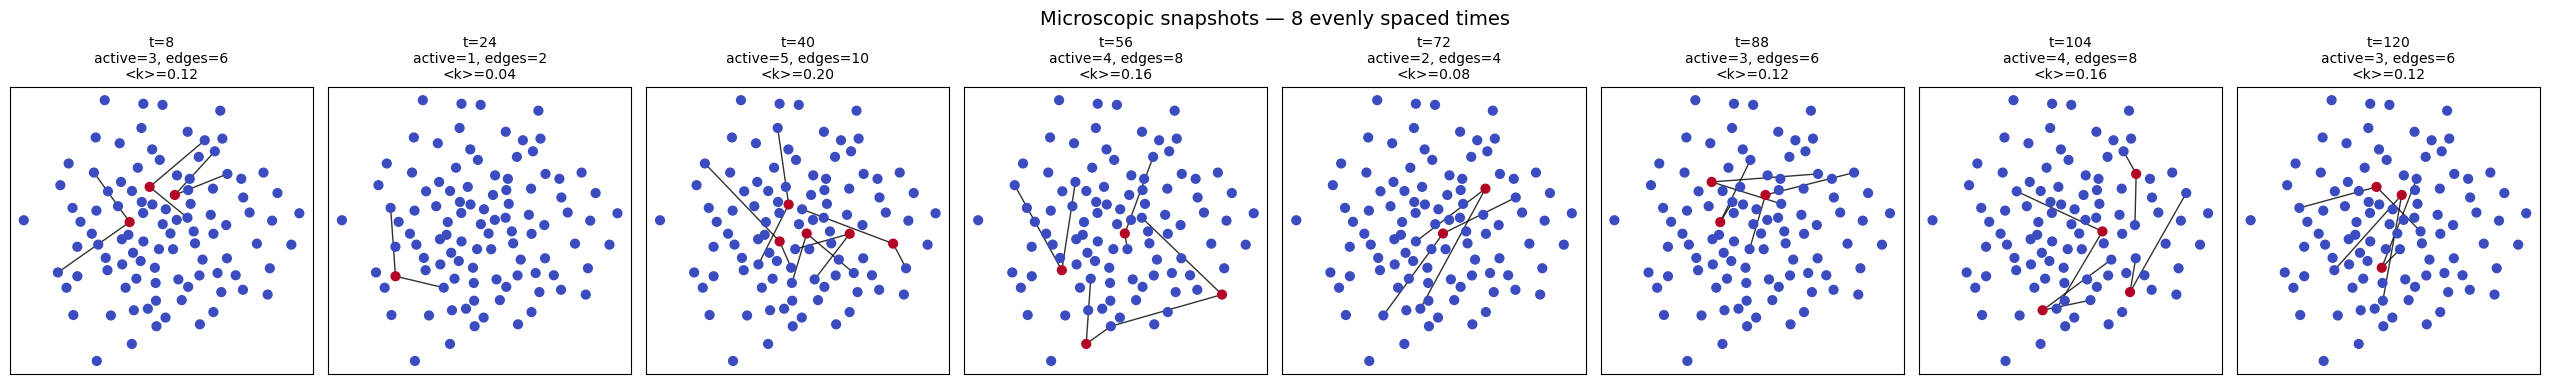


Random consecutive microscopic block
start index              = 4
indices                  = [4, 5, 6, 7, 8, 9, 10, 11]
reference block center   = 8.00
Saved figure to: stage7_scaling_outputs\microscopic_w001_block_004_011.png


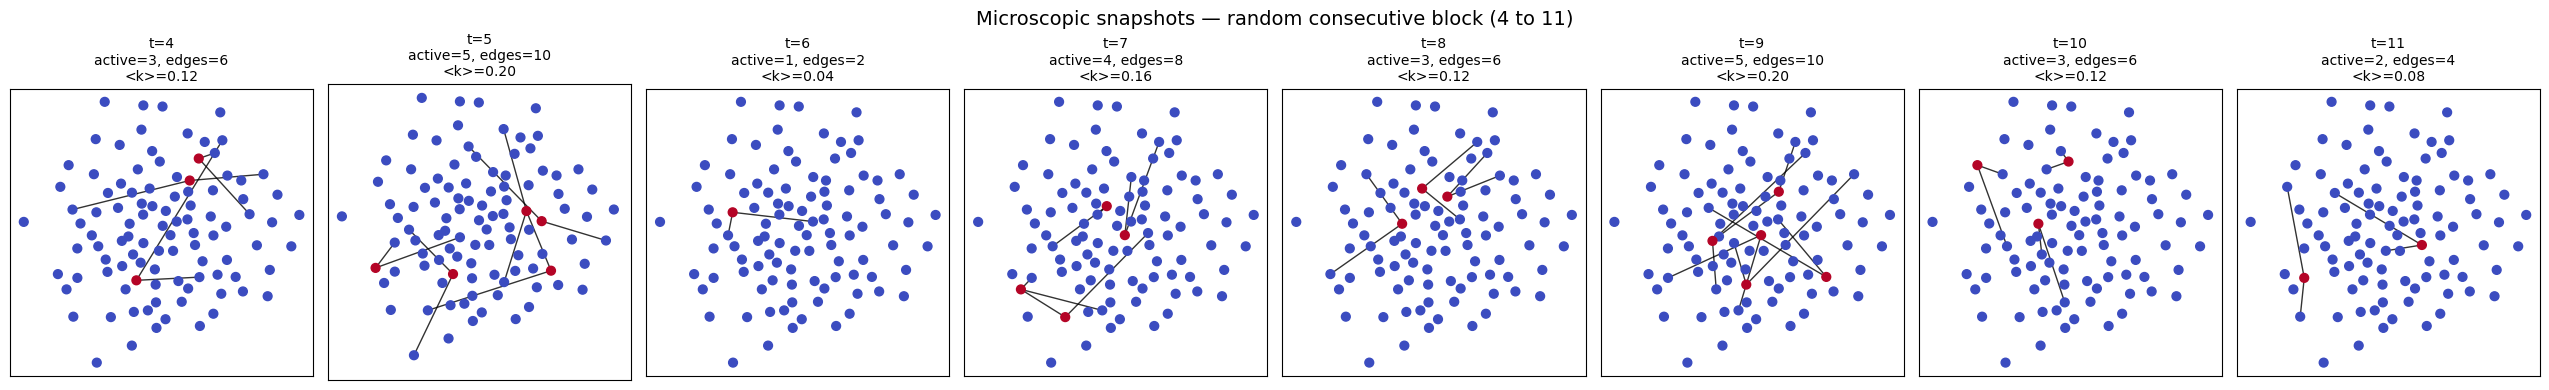

In [14]:
# ============================================================
# Cell 3.5 — Microscopic snapshot galleries
# ============================================================
#
# Two visualization protocols:
#
# (A) Eight evenly spaced microscopic snapshots:
#       8, 24, 40, 56, 72, 88, 104, 120
#
# (B) One random consecutive block of 8 microscopic snapshots:
#       t, t+1, ..., t+7
#
# IMPORTANT:
#   The random consecutive block defines a shared temporal anchor.
#   Later, for observation windows w = 2, 4, 8, ..., we will
#   choose continuous blocks centered around approximately the
#   same microscopic-time region.
#
# All figures are saved to OUTDIR.
# ============================================================


# ------------------------------------------------------------
# Common layout from the union graph of all microscopic snapshots
# ------------------------------------------------------------

all_union_edges = set()
for E in edge_sets:
    all_union_edges |= E

G_union = nx.Graph()
G_union.add_nodes_from(range(N))
G_union.add_edges_from(all_union_edges)

layout_seed = 123
pos = nx.spring_layout(G_union, seed=layout_seed)


# ------------------------------------------------------------
# (A) Eight evenly spaced microscopic snapshots
# ------------------------------------------------------------

MICRO_WINDOW_SIZE = 1
BLOCK_LEN = 8

even_snapshot_indices = [8, 24, 40, 56, 72, 88, 104, 120]

print("Evenly spaced microscopic snapshots")
print(even_snapshot_indices)

fig_even = draw_snapshot_gallery(
    snapshot_indices=even_snapshot_indices,
    gallery_title="Microscopic snapshots — 8 evenly spaced times",
    pos=pos,
    edge_sets=edge_sets,
    active_nodes_by_snapshot=active_nodes_by_snapshot,
    n_active_realized=n_active_realized,
    n_edges_realized=n_edges_realized,
    mean_degree_realized=mean_degree_realized,
    save_name=make_gallery_filename(
        prefix="microscopic",
        window_size=MICRO_WINDOW_SIZE,
        gallery_type="evenly_spaced"
    )
)


# ------------------------------------------------------------
# (B) One random consecutive block of 8 microscopic snapshots
# ------------------------------------------------------------

random_block_start = int(
    rng.integers(0, N_SNAPSHOTS - BLOCK_LEN + 1)
)

random_block_indices = list(
    range(random_block_start, random_block_start + BLOCK_LEN)
)

# Shared temporal anchor for later multiscale visualizations
# Example:
#   block 34..41 corresponds to interval [34, 42),
#   so center = 38.
REFERENCE_BLOCK_CENTER = random_block_start + BLOCK_LEN / 2

print()
print("Random consecutive microscopic block")
print(f"start index              = {random_block_start}")
print(f"indices                  = {random_block_indices}")
print(f"reference block center   = {REFERENCE_BLOCK_CENTER:.2f}")

fig_block = draw_snapshot_gallery(
    snapshot_indices=random_block_indices,
    gallery_title=(
        f"Microscopic snapshots — random consecutive block "
        f"({random_block_start} to {random_block_start + BLOCK_LEN - 1})"
    ),
    pos=pos,
    edge_sets=edge_sets,
    active_nodes_by_snapshot=active_nodes_by_snapshot,
    n_active_realized=n_active_realized,
    n_edges_realized=n_edges_realized,
    mean_degree_realized=mean_degree_realized,
    save_name=make_gallery_filename(
        prefix="microscopic",
        window_size=MICRO_WINDOW_SIZE,
        gallery_type="block",
        block_start=random_block_start,
        block_end=random_block_start + BLOCK_LEN - 1
    )
)

In [15]:
# ============================================================
# Cell 4 — Microscopic dynamical generators
# ============================================================
#
# Convert every microscopic topology
#
#     A_t
#
# into its graph Laplacian
#
#     L_t = D_t - A_t
#
# and the corresponding linear-consensus generator
#
#     K_t = -kappa * L_t.
#
# Hence, during microscopic snapshot t,
#
#     dx/dt = K_t x.
#
# These K_t matrices are the direct inputs for the later
# forward BCH / Magnus construction of F_eff.
#
# No trajectory integration is performed in this cell.
# ============================================================


# ------------------------------------------------------------
# Containers
# ------------------------------------------------------------

laplacian_snapshots = []
generator_snapshots = []


# ------------------------------------------------------------
# Build L_t and K_t
# ------------------------------------------------------------

for A in adjacency_snapshots:

    # Degree vector
    degree = np.asarray(A.sum(axis=1)).ravel()

    # Sparse degree matrix
    D = sparse.diags(
        degree,
        offsets=0,
        shape=(N, N),
        format="csr"
    )

    # Graph Laplacian
    L = (D - A).tocsr()

    # Consensus generator
    K = (-KAPPA * L).tocsr()

    # Remove explicit numerical zeros
    L.eliminate_zeros()
    K.eliminate_zeros()

    laplacian_snapshots.append(L)
    generator_snapshots.append(K)


# ------------------------------------------------------------
# Sanity checks
# ------------------------------------------------------------

max_row_sum_error = 0.0
max_symmetry_error = 0.0
max_positive_diagonal = 0.0
min_offdiag = np.inf

nnz_K = []

for K in generator_snapshots:

    # --------------------------------------------------------
    # Row-sum conservation:
    #
    #     K @ 1 = 0
    #
    # --------------------------------------------------------

    row_sums = np.asarray(K.sum(axis=1)).ravel()

    max_row_sum_error = max(
        max_row_sum_error,
        np.max(np.abs(row_sums))
    )

    # --------------------------------------------------------
    # Symmetry:
    #
    # microscopic networks are undirected, hence
    #
    #     K = K^T
    #
    # --------------------------------------------------------

    asym = K - K.T

    if asym.nnz > 0:
        max_symmetry_error = max(
            max_symmetry_error,
            np.max(np.abs(asym.data))
        )

    # --------------------------------------------------------
    # Sign structure
    #
    # Consensus generator:
    #
    #     K_ii <= 0
    #     K_ij >= 0,  i != j
    #
    # --------------------------------------------------------

    diag = K.diagonal()

    if len(diag) > 0:
        max_positive_diagonal = max(
            max_positive_diagonal,
            np.max(np.maximum(diag, 0.0))
        )

    K_off = K - sparse.diags(
        diag,
        offsets=0,
        shape=(N, N),
        format="csr"
    )

    K_off.eliminate_zeros()

    if K_off.nnz > 0:
        min_offdiag = min(
            min_offdiag,
            np.min(K_off.data)
        )

    nnz_K.append(K.nnz)


nnz_K = np.asarray(nnz_K)

if not np.isfinite(min_offdiag):
    min_offdiag = 0.0


# ------------------------------------------------------------
# Assertions
# ------------------------------------------------------------

assert max_row_sum_error < ROW_SUM_TOL, (
    f"Row-sum conservation failed: "
    f"{max_row_sum_error:.3e}"
)

assert max_symmetry_error < ROW_SUM_TOL, (
    f"Microscopic generator symmetry failed: "
    f"{max_symmetry_error:.3e}"
)

assert max_positive_diagonal < COEFF_TOL, (
    f"Positive diagonal entry detected: "
    f"{max_positive_diagonal:.3e}"
)

assert min_offdiag >= -COEFF_TOL, (
    f"Negative off-diagonal entry detected: "
    f"{min_offdiag:.3e}"
)


# ------------------------------------------------------------
# Generator-level statistics
# ------------------------------------------------------------

frobenius_norms_K = np.array([
    sparse.linalg.norm(K)
    for K in generator_snapshots
])

zero_generators = np.array([
    K.nnz == 0
    for K in generator_snapshots
])


print("Microscopic dynamical generators")
print("================================")

print()
print("Construction")
print("------------")
print(f"number of generators       = {len(generator_snapshots)}")
print(f"matrix size                = {N} x {N}")
print(f"kappa                      = {KAPPA}")

print()
print("Sanity checks")
print("-------------")
print(
    f"max |row sum|             = "
    f"{max_row_sum_error:.3e}"
)
print(
    f"max |K-K^T|               = "
    f"{max_symmetry_error:.3e}"
)
print(
    f"max positive diagonal     = "
    f"{max_positive_diagonal:.3e}"
)
print(
    f"min off-diagonal          = "
    f"{min_offdiag:.3e}"
)

print()
print("Sparsity")
print("--------")
print(
    f"mean nnz(K_t)             = "
    f"{nnz_K.mean():.2f}"
)
print(
    f"min / max nnz(K_t)       = "
    f"{nnz_K.min()} / {nnz_K.max()}"
)
print(
    f"mean matrix density       = "
    f"{nnz_K.mean() / (N * N):.6f}"
)
print(
    f"zero generators           = "
    f"{zero_generators.sum()} / {N_SNAPSHOTS}"
)

print()
print("Generator strength")
print("------------------")
print(
    f"mean ||K_t||_F            = "
    f"{frobenius_norms_K.mean():.4f}"
)
print(
    f"median ||K_t||_F          = "
    f"{np.median(frobenius_norms_K):.4f}"
)
print(
    f"min / max ||K_t||_F      = "
    f"{frobenius_norms_K.min():.4f} / "
    f"{frobenius_norms_K.max():.4f}"
)


# ------------------------------------------------------------
# Snapshot-level generator audit table
# ------------------------------------------------------------

generator_df = pd.DataFrame({
    "snapshot": np.arange(N_SNAPSHOTS),
    "n_edges": n_edges_realized,
    "nnz_K": nnz_K,
    "frobenius_K": frobenius_norms_K,
    "zero_generator": zero_generators
})

display(generator_df.head(15))

Microscopic dynamical generators

Construction
------------
number of generators       = 128
matrix size                = 100 x 100
kappa                      = 1.0

Sanity checks
-------------
max |row sum|             = 0.000e+00
max |K-K^T|               = 0.000e+00
max positive diagonal     = 0.000e+00
min off-diagonal          = 1.000e+00

Sparsity
--------
mean nnz(K_t)             = 17.66
min / max nnz(K_t)       = 0 / 53
mean matrix density       = 0.001766
zero generators           = 6 / 128

Generator strength
------------------
mean ||K_t||_F            = 4.8486
median ||K_t||_F          = 4.8990
min / max ||K_t||_F      = 0.0000 / 9.4868


,snapshot,n_edges,nnz_K,frobenius_K,zero_generator
0,0,4,14,4.472136,False
1,1,4,14,4.472136,False
2,2,6,20,5.830952,False
3,3,4,14,4.472136,False
4,4,6,21,5.477226,False
5,5,10,34,7.348469,False
6,6,2,7,3.162278,False
7,7,8,27,6.633250,False
8,8,6,21,5.477226,False
9,9,10,34,7.348469,False



Computing BCH scale w=2 (64 aligned windows)...

Computing BCH scale w=4 (32 aligned windows)...

Computing BCH scale w=8 (16 aligned windows)...

Computing BCH scale w=16 (8 aligned windows)...

Computing BCH scale w=32 (4 aligned windows)...

Computing BCH scale w=64 (2 aligned windows)...

Computing BCH scale w=128 (1 aligned windows)...

BCH algebraic audit
max symmetry error K_avg       = 0.000e+00
max antisymmetry error K_comm  = 0.000e+00
max symmetry error K_nested    = 0.000e+00
max row-sum error K_avg        = 2.220e-16
max row-sum error K_comm       = 1.176e-17
max row-sum error K_nested     = 1.952e-18

Scale summary


,window_size,n_windows,mean_norm_avg,mean_norm_comm,mean_norm_nested,median_ratio_comm,q25_ratio_comm,q75_ratio_comm,median_ratio_nested,q25_ratio_nested,q75_ratio_nested,median_nested_to_comm,mean_support_avg_pairs,mean_support_comm_pairs,mean_support_nested_pairs,mean_support_eff_pairs
0,2,64,3.634518,0.024952,0.000990,0.000000,0.000000,0.013075,0.000000,0.000000,0.000511,0.040670,10.21875,3.078125,5.953125,14.359375
1,4,32,2.715934,0.044576,0.001927,0.016795,0.013073,0.019088,0.000677,0.000527,0.000842,0.041114,20.40625,15.687500,31.406250,43.375000
2,8,16,2.087761,0.050309,0.002747,0.024509,0.019730,0.026778,0.001288,0.001004,0.001565,0.051923,40.50000,56.562500,127.937500,143.687500
3,16,8,1.678599,0.054922,0.004024,0.032369,0.030749,0.033619,0.002246,0.002007,0.002531,0.071593,80.87500,198.000000,528.875000,547.250000
4,32,4,1.407608,0.055415,0.005465,0.039110,0.037875,0.040538,0.003913,0.003728,0.004064,0.100094,161.25000,607.750000,1857.250000,1888.000000
5,64,2,1.238078,0.056606,0.007569,0.045653,0.044674,0.046633,0.006095,0.005825,0.006366,0.133246,318.50000,1669.000000,4100.000000,4148.000000
6,128,1,1.145537,0.058205,0.010732,0.050810,0.050810,0.050810,0.009369,0.009369,0.009369,0.184388,617.00000,3365.000000,4866.000000,4904.000000


,window_size,window_idx,start,end,norm_avg,norm_comm,norm_nested,ratio_comm,ratio_nested,support_avg_pairs,support_comm_pairs,support_nested_pairs,support_eff_pairs
0,2,0,0,2,3.316625,0.043301,0.001780,0.013056,0.000537,8,6,13,17
1,2,1,2,4,3.807887,0.050000,0.002041,0.013131,0.000536,10,5,9,16
2,2,2,4,6,4.795832,0.079057,0.002946,0.016485,0.000614,16,8,10,22
3,2,3,6,8,3.674235,0.000000,0.000000,0.000000,0.000000,10,0,0,10
4,2,4,8,10,4.743416,0.053033,0.002273,0.011180,0.000479,16,9,22,32
5,2,5,10,12,3.535534,0.000000,0.000000,0.000000,0.000000,10,0,0,10
6,2,6,12,14,4.636809,0.050000,0.002135,0.010783,0.000460,16,5,11,24
7,2,7,14,16,3.162278,0.000000,0.000000,0.000000,0.000000,8,0,0,8
8,2,8,16,18,4.242641,0.084779,0.003366,0.019983,0.000793,12,11,20,26
9,2,9,18,20,3.162278,0.000000,0.000000,0.000000,0.000000,8,0,0,8


Saved figure to: stage7_scaling_outputs\bch_sector_scaling.png


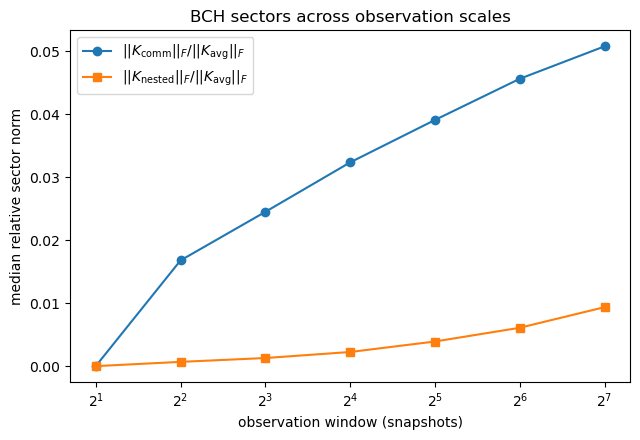


Saved window metrics to: stage7_scaling_outputs\bch_window_metrics.csv
Saved scale summary to:  stage7_scaling_outputs\bch_scale_summary.csv


In [16]:
# ============================================================
# Cell 5 — Forward BCH effective generators across scales
# ============================================================
#
# Goal
# ----
# Starting from the known microscopic generators
#
#     K_0, K_1, ..., K_{127},
#
# construct finite-window effective generators directly,
# without inverse inference.
#
# For one aligned observation window of w snapshots:
#
#     U = exp(tau K_{w-1}) ... exp(tau K_1) exp(tau K_0)
#
# We use the BCH expansion
#
#     Omega = Omega_1 + Omega_2 + Omega_3 + O(A^4),
#
# where A_r = tau K_r.
#
# The corresponding generator sectors are
#
#     K_avg    = Omega_1 / (w tau)
#     K_comm   = Omega_2 / (w tau)
#     K_nested = Omega_3 / (w tau)
#
# and
#
#     K_eff^(0) = K_avg
#     K_eff^(1) = K_avg + K_comm
#     K_eff^(2) = K_avg + K_comm + K_nested
#
# Interpretation
# --------------
# K_avg:
#     naive temporal aggregation
#
# K_comm:
#     first temporal-order / commutator correction, O(tau)
#
# K_nested:
#     nested-commutator correction, O(tau^2)
#
# Because every microscopic K_t is symmetric:
#
#     K_avg    -> symmetric
#     K_comm   -> antisymmetric
#     K_nested -> symmetric
#
# All sectors must also satisfy K @ 1 = 0.
#
# Windows used here are aligned and non-overlapping:
#
#     w=2  : [0,2), [2,4), ...
#     w=4  : [0,4), [4,8), ...
#     ...
#
# This gives an exact dyadic hierarchy.
# ============================================================


# ------------------------------------------------------------
# Analysis scales
# ------------------------------------------------------------

BCH_WINDOW_SIZES = np.array(
    [2, 4, 8, 16, 32, 64, 128],
    dtype=int
)

assert np.all(N_SNAPSHOTS % BCH_WINDOW_SIZES == 0)


# ------------------------------------------------------------
# Sparse-matrix helpers
# ------------------------------------------------------------

BCH_DROP_TOL = 1e-14


def clean_sparse(M, tol=BCH_DROP_TOL):
    """
    Convert to CSR and drop very small numerical entries.
    """
    M = M.tocsr(copy=True)

    if M.nnz > 0:
        M.data[np.abs(M.data) < tol] = 0.0
        M.eliminate_zeros()

    return M


def commutator(A, B):
    """
    Matrix commutator:

        [A, B] = A B - B A
    """
    return clean_sparse(A @ B - B @ A)


def sparse_fro_norm(M):
    return float(sparse.linalg.norm(M))


def relative_ratio(numerator, denominator):
    """
    Safe norm ratio.
    """
    if denominator <= COEFF_TOL:
        return np.nan

    return numerator / denominator


def max_abs_sparse(M):
    if M.nnz == 0:
        return 0.0
    return float(np.max(np.abs(M.data)))


def max_row_sum_abs(M):
    row_sum = np.asarray(M.sum(axis=1)).ravel()
    return float(np.max(np.abs(row_sum)))


def symmetry_error(M):
    """
    Absolute max-entry error for M = M^T.
    """
    return max_abs_sparse(clean_sparse(M - M.T))


def antisymmetry_error(M):
    """
    Absolute max-entry error for M = -M^T.
    """
    return max_abs_sparse(clean_sparse(M + M.T))


def offdiag_support(M, tol=COEFF_TOL):
    """
    Number of directed off-diagonal entries with |M_ij| > tol.
    """
    C = M.tocoo()

    mask = (
        (C.row != C.col)
        & (np.abs(C.data) > tol)
    )

    return int(np.sum(mask))


def unordered_pair_support(M, tol=COEFF_TOL):
    """
    Number of unordered node pairs {i,j} for which at least one
    off-diagonal entry is numerically nonzero.

    Useful later when interpreting matrices as effective networks.
    """
    C = M.tocoo()

    pairs = set()

    for i, j, value in zip(C.row, C.col, C.data):

        if i == j:
            continue

        if abs(value) <= tol:
            continue

        u, v = sorted((int(i), int(j)))
        pairs.add((u, v))

    return len(pairs)


# ------------------------------------------------------------
# BCH update through cubic matrix order
# ------------------------------------------------------------

def bch_append_order3(
    Omega1,
    Omega2,
    Omega3,
    A_new
):
    """
    Append a later-time factor on the LEFT:

        exp(A_new) exp(Omega_old)

    using BCH through O(A^3).

    BCH(X,Y) =
        X + Y
        + 1/2 [X,Y]
        + 1/12 [X,[X,Y]]
        + 1/12 [Y,[Y,X]]
        + O(A^4)

    with:
        X = A_new
        Y = Omega1 + Omega2 + Omega3

    Order-separated recursion:

        Omega1' =
            Omega1 + A_new

        Omega2' =
            Omega2
            + 1/2 [A_new, Omega1]

        Omega3' =
            Omega3
            + 1/2 [A_new, Omega2]
            + 1/12 [A_new, [A_new, Omega1]]
            + 1/12 [Omega1, [Omega1, A_new]]

    IMPORTANT:
    Omega1 and Omega2 on the RHS are the OLD values.
    """

    # First commutator with old Omega1
    C_new_1 = commutator(
        A_new,
        Omega1
    )

    # Order-3 pieces
    term_A_A_O1 = commutator(
        A_new,
        C_new_1
    )

    term_O1_O1_A = commutator(
        Omega1,
        commutator(Omega1, A_new)
    )

    term_A_O2 = commutator(
        A_new,
        Omega2
    )

    # Update high orders first so RHS uses old values
    Omega3_new = clean_sparse(
        Omega3
        + 0.5 * term_A_O2
        + (1.0 / 12.0) * term_A_A_O1
        + (1.0 / 12.0) * term_O1_O1_A
    )

    Omega2_new = clean_sparse(
        Omega2
        + 0.5 * C_new_1
    )

    Omega1_new = clean_sparse(
        Omega1
        + A_new
    )

    return (
        Omega1_new,
        Omega2_new,
        Omega3_new
    )


# ------------------------------------------------------------
# Construct one effective window
# ------------------------------------------------------------

def forward_bch_window(
    generator_snapshots,
    start,
    window_size,
    tau
):
    """
    Forward BCH construction for one aligned temporal window.

    Window:
        [start, start + window_size)

    Returns all BCH sectors and cumulative truncations.
    """

    Z = sparse.csr_matrix(
        (N, N),
        dtype=float
    )

    Omega1 = Z.copy()
    Omega2 = Z.copy()
    Omega3 = Z.copy()

    end = start + window_size

    # Chronological order:
    #
    # state evolution is
    #
    # exp(A_last) ... exp(A_first)
    #
    # so each newly encountered A is appended on the LEFT.
    for snapshot_idx in range(start, end):

        A_new = clean_sparse(
            tau * generator_snapshots[snapshot_idx]
        )

        (
            Omega1,
            Omega2,
            Omega3
        ) = bch_append_order3(
            Omega1,
            Omega2,
            Omega3,
            A_new
        )

    window_time = window_size * tau

    # Individual generator sectors
    K_avg = clean_sparse(
        Omega1 / window_time
    )

    K_comm = clean_sparse(
        Omega2 / window_time
    )

    K_nested = clean_sparse(
        Omega3 / window_time
    )

    # Cumulative truncations
    K_eff_0 = K_avg

    K_eff_1 = clean_sparse(
        K_avg + K_comm
    )

    K_eff_2 = clean_sparse(
        K_avg + K_comm + K_nested
    )

    return {
        "start": start,
        "end": end,
        "window_size": window_size,
        "window_time": window_time,

        "Omega1": Omega1,
        "Omega2": Omega2,
        "Omega3": Omega3,

        "K_avg": K_avg,
        "K_comm": K_comm,
        "K_nested": K_nested,

        "K_eff_0": K_eff_0,
        "K_eff_1": K_eff_1,
        "K_eff_2": K_eff_2,
    }


# ------------------------------------------------------------
# Run the complete aligned multiscale hierarchy
# ------------------------------------------------------------

effective_by_scale = {}

window_metric_rows = []

for w in BCH_WINDOW_SIZES:

    n_windows = N_SNAPSHOTS // w

    scale_results = []

    print()
    print(
        f"Computing BCH scale w={w} "
        f"({n_windows} aligned windows)..."
    )

    for window_idx in range(n_windows):

        start = window_idx * w

        result = forward_bch_window(
            generator_snapshots=generator_snapshots,
            start=start,
            window_size=w,
            tau=TAU_SNAPSHOT
        )

        # ----------------------------------------------------
        # Norms
        # ----------------------------------------------------

        norm_avg = sparse_fro_norm(
            result["K_avg"]
        )

        norm_comm = sparse_fro_norm(
            result["K_comm"]
        )

        norm_nested = sparse_fro_norm(
            result["K_nested"]
        )

        norm_eff_2 = sparse_fro_norm(
            result["K_eff_2"]
        )

        ratio_comm = relative_ratio(
            norm_comm,
            norm_avg
        )

        ratio_nested = relative_ratio(
            norm_nested,
            norm_avg
        )

        # Also useful:
        # nested relative to first commutator
        ratio_nested_to_comm = relative_ratio(
            norm_nested,
            norm_comm
        )

        # ----------------------------------------------------
        # Algebraic sanity checks
        # ----------------------------------------------------

        avg_sym_err = symmetry_error(
            result["K_avg"]
        )

        comm_antisym_err = antisymmetry_error(
            result["K_comm"]
        )

        nested_sym_err = symmetry_error(
            result["K_nested"]
        )

        row_avg = max_row_sum_abs(
            result["K_avg"]
        )

        row_comm = max_row_sum_abs(
            result["K_comm"]
        )

        row_nested = max_row_sum_abs(
            result["K_nested"]
        )

        # ----------------------------------------------------
        # Structural support
        # ----------------------------------------------------

        support_avg_directed = offdiag_support(
            result["K_avg"]
        )

        support_comm_directed = offdiag_support(
            result["K_comm"]
        )

        support_nested_directed = offdiag_support(
            result["K_nested"]
        )

        support_eff_directed = offdiag_support(
            result["K_eff_2"]
        )

        support_avg_pairs = unordered_pair_support(
            result["K_avg"]
        )

        support_comm_pairs = unordered_pair_support(
            result["K_comm"]
        )

        support_nested_pairs = unordered_pair_support(
            result["K_nested"]
        )

        support_eff_pairs = unordered_pair_support(
            result["K_eff_2"]
        )

        # ----------------------------------------------------
        # Store metrics inside the result itself
        # ----------------------------------------------------

        result.update({
            "window_idx": window_idx,

            "norm_avg": norm_avg,
            "norm_comm": norm_comm,
            "norm_nested": norm_nested,
            "norm_eff_2": norm_eff_2,

            "ratio_comm": ratio_comm,
            "ratio_nested": ratio_nested,
            "ratio_nested_to_comm": ratio_nested_to_comm,

            "support_avg_pairs": support_avg_pairs,
            "support_comm_pairs": support_comm_pairs,
            "support_nested_pairs": support_nested_pairs,
            "support_eff_pairs": support_eff_pairs,
        })

        scale_results.append(result)

        # ----------------------------------------------------
        # Flat audit table
        # ----------------------------------------------------

        window_metric_rows.append({
            "window_size": w,
            "window_idx": window_idx,
            "start": result["start"],
            "end": result["end"],
            "window_time": result["window_time"],

            "norm_avg": norm_avg,
            "norm_comm": norm_comm,
            "norm_nested": norm_nested,
            "norm_eff_2": norm_eff_2,

            "ratio_comm": ratio_comm,
            "ratio_nested": ratio_nested,
            "ratio_nested_to_comm": ratio_nested_to_comm,

            "avg_symmetry_error": avg_sym_err,
            "comm_antisymmetry_error": comm_antisym_err,
            "nested_symmetry_error": nested_sym_err,

            "row_sum_avg": row_avg,
            "row_sum_comm": row_comm,
            "row_sum_nested": row_nested,

            "support_avg_directed": support_avg_directed,
            "support_comm_directed": support_comm_directed,
            "support_nested_directed": support_nested_directed,
            "support_eff_directed": support_eff_directed,

            "support_avg_pairs": support_avg_pairs,
            "support_comm_pairs": support_comm_pairs,
            "support_nested_pairs": support_nested_pairs,
            "support_eff_pairs": support_eff_pairs,
        })

    effective_by_scale[w] = scale_results


# ------------------------------------------------------------
# Window-level DataFrame
# ------------------------------------------------------------

bch_window_df = pd.DataFrame(
    window_metric_rows
)


# ------------------------------------------------------------
# Global algebraic checks
# ------------------------------------------------------------

print()
print("BCH algebraic audit")
print("===================")

print(
    "max symmetry error K_avg       = "
    f"{bch_window_df['avg_symmetry_error'].max():.3e}"
)

print(
    "max antisymmetry error K_comm  = "
    f"{bch_window_df['comm_antisymmetry_error'].max():.3e}"
)

print(
    "max symmetry error K_nested    = "
    f"{bch_window_df['nested_symmetry_error'].max():.3e}"
)

print(
    "max row-sum error K_avg        = "
    f"{bch_window_df['row_sum_avg'].max():.3e}"
)

print(
    "max row-sum error K_comm       = "
    f"{bch_window_df['row_sum_comm'].max():.3e}"
)

print(
    "max row-sum error K_nested     = "
    f"{bch_window_df['row_sum_nested'].max():.3e}"
)


# ------------------------------------------------------------
# Assertions
# ------------------------------------------------------------

assert (
    bch_window_df["avg_symmetry_error"].max()
    < 1e-10
)

assert (
    bch_window_df["comm_antisymmetry_error"].max()
    < 1e-10
)

assert (
    bch_window_df["nested_symmetry_error"].max()
    < 1e-10
)

assert (
    bch_window_df[
        [
            "row_sum_avg",
            "row_sum_comm",
            "row_sum_nested"
        ]
    ].to_numpy().max()
    < 1e-10
)


# ------------------------------------------------------------
# Scale-level summary
# ------------------------------------------------------------

def q25(x):
    return x.quantile(0.25)


def q75(x):
    return x.quantile(0.75)


bch_scale_df = (
    bch_window_df
    .groupby("window_size")
    .agg(
        n_windows=("window_idx", "count"),

        mean_norm_avg=("norm_avg", "mean"),
        mean_norm_comm=("norm_comm", "mean"),
        mean_norm_nested=("norm_nested", "mean"),

        median_ratio_comm=("ratio_comm", "median"),
        q25_ratio_comm=("ratio_comm", q25),
        q75_ratio_comm=("ratio_comm", q75),

        median_ratio_nested=("ratio_nested", "median"),
        q25_ratio_nested=("ratio_nested", q25),
        q75_ratio_nested=("ratio_nested", q75),

        median_nested_to_comm=(
            "ratio_nested_to_comm",
            "median"
        ),

        mean_support_avg_pairs=(
            "support_avg_pairs",
            "mean"
        ),
        mean_support_comm_pairs=(
            "support_comm_pairs",
            "mean"
        ),
        mean_support_nested_pairs=(
            "support_nested_pairs",
            "mean"
        ),
        mean_support_eff_pairs=(
            "support_eff_pairs",
            "mean"
        ),
    )
    .reset_index()
)


print()
print("Scale summary")
print("=============")

display(bch_scale_df)


# ------------------------------------------------------------
# More detailed first rows
# ------------------------------------------------------------

display(
    bch_window_df[
        [
            "window_size",
            "window_idx",
            "start",
            "end",
            "norm_avg",
            "norm_comm",
            "norm_nested",
            "ratio_comm",
            "ratio_nested",
            "support_avg_pairs",
            "support_comm_pairs",
            "support_nested_pairs",
            "support_eff_pairs",
        ]
    ].head(20)
)


# ------------------------------------------------------------
# Quick scale diagnostic
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(6.5, 4.5)
)

ax.plot(
    bch_scale_df["window_size"],
    bch_scale_df["median_ratio_comm"],
    marker="o",
    label=r"$||K_{\rm comm}||_F / ||K_{\rm avg}||_F$"
)

ax.plot(
    bch_scale_df["window_size"],
    bch_scale_df["median_ratio_nested"],
    marker="s",
    label=r"$||K_{\rm nested}||_F / ||K_{\rm avg}||_F$"
)

ax.set_xscale("log", base=2)

ax.set_xlabel("observation window (snapshots)")
ax.set_ylabel("median relative sector norm")
ax.set_title("BCH sectors across observation scales")

ax.legend()

plt.tight_layout()

scale_fig_path = (
    OUTDIR / "bch_sector_scaling.png"
)

fig.savefig(
    scale_fig_path,
    dpi=250,
    bbox_inches="tight"
)

print(f"Saved figure to: {scale_fig_path}")

plt.show()


# ------------------------------------------------------------
# Save numerical summaries
# ------------------------------------------------------------

window_csv_path = (
    OUTDIR / "bch_window_metrics.csv"
)

scale_csv_path = (
    OUTDIR / "bch_scale_summary.csv"
)

bch_window_df.to_csv(
    window_csv_path,
    index=False
)

bch_scale_df.to_csv(
    scale_csv_path,
    index=False
)

print()
print(f"Saved window metrics to: {window_csv_path}")
print(f"Saved scale summary to:  {scale_csv_path}")

Precomputing exact microscopic propagators...
Done: 128 propagators of size 100 x 100.

Exact BCH calibration
w= 2: 64 windows
w= 4: 32 windows
w= 8: 16 windows
w=16: 8 windows
w=32: 4 windows
w=64: 2 windows
w=128: 1 windows

Exact calibration summary


,window_size,n_windows,median_err_K0,median_err_K1,median_err_K2,max_err_K0,max_err_K1,max_err_K2,q95_err_K2,median_err_U0,median_err_U1,median_err_U2,max_err_U2,max_log_imag_ratio,max_exact_row_sum_error
0,2,64,1.049023e-14,1.049023e-14,1.049023e-14,0.019999,0.000793,0.000021,0.000018,0.000000,0.000000,0.000000e+00,8.056271e-07,0.0,4.067509e-14
1,4,32,1.681221e-02,6.773579e-04,1.495628e-05,0.027145,0.001466,0.000090,0.000039,0.000855,0.000034,7.695873e-07,3.907008e-06,0.0,2.389826e-14
2,8,16,2.455593e-02,1.290787e-03,5.921889e-05,0.029634,0.001814,0.000098,0.000094,0.001818,0.000095,4.101686e-06,8.619823e-06,0.0,1.937816e-14
3,16,8,3.244724e-02,2.250477e-03,1.372923e-04,0.040231,0.003891,0.000266,0.000243,0.003745,0.000241,1.486751e-05,3.199842e-05,0.0,1.194119e-14
4,32,4,3.940555e-02,3.938424e-03,3.602533e-04,0.041699,0.004360,0.000395,0.000392,0.007595,0.000671,5.919436e-05,7.240976e-05,0.0,7.487787e-15
5,64,2,4.627548e-02,6.154772e-03,7.138938e-04,0.048332,0.006707,0.000800,0.000791,0.014844,0.001854,2.135154e-04,2.452636e-04,0.0,3.614459e-15
6,128,1,5.212307e-02,9.564207e-03,1.584498e-03,0.052123,0.009564,0.001584,0.001584,0.029944,0.005201,8.083880e-04,8.083880e-04,0.0,5.568191e-16



Global diagnostics
------------------
max principal-log imaginary ratio = 0.000e+00
max exact row-sum error           = 4.068e-14

Highest-order BCH truncation
----------------------------
median generator error            = 1.360e-05
95% generator error               = 2.582e-04
max generator error               = 1.584e-03
median propagator error           = 5.318e-07
max propagator error              = 8.084e-04
Saved figure to: stage7_scaling_outputs\bch_exact_calibration_generator_error.png


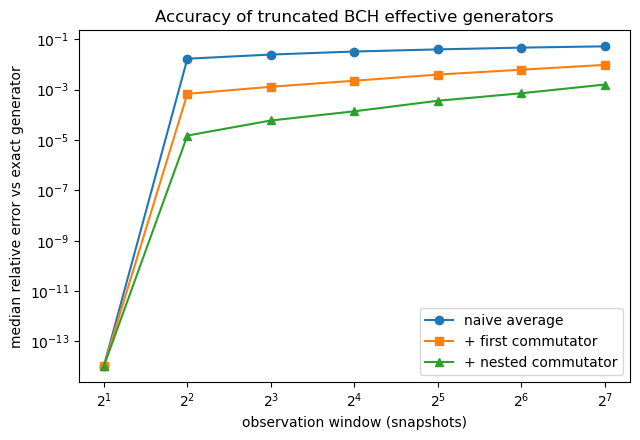

Saved figure to: stage7_scaling_outputs\bch_exact_calibration_propagator_error.png


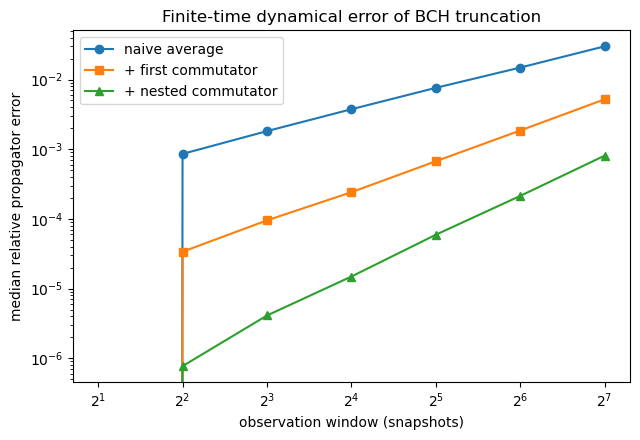


Saved window calibration to: stage7_scaling_outputs\bch_exact_window_calibration.csv
Saved scale calibration to:  stage7_scaling_outputs\bch_exact_scale_calibration.csv


In [17]:
# ============================================================
# Cell 5.5 — Exact calibration of the BCH truncation
# ============================================================
#
# Compare the truncated forward BCH generators from Cell 5 with
# the exact finite-window generator
#
#     K_exact
#       = log(
#           exp(tau K_last) ... exp(tau K_first)
#         ) / (w tau).
#
# We test ALL aligned non-overlapping windows at
#
#     w = 2, 4, 8, 16, 32.
#
# Truncations:
#
#     K_eff_0 = K_avg
#
#     K_eff_1 = K_avg + K_comm
#
#     K_eff_2 = K_avg + K_comm + K_nested
#
# Diagnostics:
#
#   1. generator-space relative Frobenius error;
#   2. finite-time propagator error;
#   3. imaginary component generated by principal logm;
#   4. error statistics versus observation scale.
#
# ============================================================


# ------------------------------------------------------------
# Precompute exact microscopic propagators
# ------------------------------------------------------------
#
# P_t = exp(tau K_t)
#
# This is the only place where we exponentiate every microscopic
# generator. For the current N=100 pilot this is inexpensive.
# ------------------------------------------------------------

print("Precomputing exact microscopic propagators...")

snapshot_propagators = []

for K in generator_snapshots:

    K_dense = K.toarray()

    P = expm(
        TAU_SNAPSHOT * K_dense
    )

    snapshot_propagators.append(P)

print(
    f"Done: {len(snapshot_propagators)} "
    f"propagators of size {N} x {N}."
)


# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------

def dense_fro_norm(M):
    return float(
        np.linalg.norm(M, ord="fro")
    )


def relative_fro_error(
    approx,
    reference,
    floor=1e-14
):
    denom = dense_fro_norm(reference)

    if denom < floor:
        return np.nan

    return (
        dense_fro_norm(approx - reference)
        / denom
    )


def exact_window_propagator(
    snapshot_propagators,
    start,
    window_size
):
    """
    Exact chronological propagator:

        U = P_last ... P_second P_first

    for the window [start, start + window_size).
    """

    U = np.eye(N)

    for idx in range(
        start,
        start + window_size
    ):
        # Later propagators multiply on the LEFT.
        U = snapshot_propagators[idx] @ U

    return U


def exact_effective_generator(
    snapshot_propagators,
    start,
    window_size,
    tau
):
    """
    Exact principal-log effective generator.
    """

    U = exact_window_propagator(
        snapshot_propagators,
        start,
        window_size
    )

    Omega_exact = logm(U)

    # Quantify any complex numerical / branch contribution
    imag_norm = dense_fro_norm(
        np.imag(Omega_exact)
    )

    real_norm = dense_fro_norm(
        np.real(Omega_exact)
    )

    imag_ratio = (
        imag_norm / real_norm
        if real_norm > 1e-14
        else 0.0
    )

    K_exact = (
        Omega_exact
        / (window_size * tau)
    )

    return U, K_exact, imag_ratio


# ------------------------------------------------------------
# Exact comparison over all aligned windows
# ------------------------------------------------------------

exact_rows = []

print()
print("Exact BCH calibration")
print("=====================")

for w in BCH_WINDOW_SIZES:

    scale_results = effective_by_scale[w]

    print(
        f"w={w:2d}: "
        f"{len(scale_results)} windows"
    )

    for result in scale_results:

        start = result["start"]

        # ----------------------------------------------------
        # Exact propagator and exact logarithmic generator
        # ----------------------------------------------------

        (
            U_exact,
            K_exact_complex,
            log_imag_ratio
        ) = exact_effective_generator(
            snapshot_propagators,
            start=start,
            window_size=w,
            tau=TAU_SNAPSHOT
        )

        # The exact result should be real to numerical precision
        # in the current regime.
        K_exact = np.real(
            K_exact_complex
        )

        # ----------------------------------------------------
        # BCH approximations from Cell 5
        # ----------------------------------------------------

        K0 = result["K_eff_0"].toarray()
        K1 = result["K_eff_1"].toarray()
        K2 = result["K_eff_2"].toarray()

        # ----------------------------------------------------
        # Generator-space errors
        # ----------------------------------------------------

        err_K0 = relative_fro_error(
            K0,
            K_exact
        )

        err_K1 = relative_fro_error(
            K1,
            K_exact
        )

        err_K2 = relative_fro_error(
            K2,
            K_exact
        )

        # ----------------------------------------------------
        # Propagator-space errors
        # ----------------------------------------------------
        #
        # Re-exponentiate each truncated generator over the
        # full observation time.
        # ----------------------------------------------------

        window_time = (
            w * TAU_SNAPSHOT
        )

        U0 = expm(
            window_time * K0
        )

        U1 = expm(
            window_time * K1
        )

        U2 = expm(
            window_time * K2
        )

        err_U0 = relative_fro_error(
            U0,
            U_exact
        )

        err_U1 = relative_fro_error(
            U1,
            U_exact
        )

        err_U2 = relative_fro_error(
            U2,
            U_exact
        )

        # ----------------------------------------------------
        # Exact-generator structural checks
        # ----------------------------------------------------

        exact_row_sum_error = np.max(
            np.abs(
                K_exact.sum(axis=1)
            )
        )

        exact_norm = dense_fro_norm(
            K_exact
        )

        # ----------------------------------------------------
        # Store exact object for later optional inspection
        # ----------------------------------------------------

        result["K_exact"] = K_exact
        result["U_exact"] = U_exact

        result["err_K0_exact"] = err_K0
        result["err_K1_exact"] = err_K1
        result["err_K2_exact"] = err_K2

        result["err_U0_exact"] = err_U0
        result["err_U1_exact"] = err_U1
        result["err_U2_exact"] = err_U2

        # ----------------------------------------------------
        # Flat audit row
        # ----------------------------------------------------

        exact_rows.append({
            "window_size": w,
            "window_idx": result["window_idx"],
            "start": start,
            "end": result["end"],

            "norm_K_exact": exact_norm,

            "err_K0": err_K0,
            "err_K1": err_K1,
            "err_K2": err_K2,

            "err_U0": err_U0,
            "err_U1": err_U1,
            "err_U2": err_U2,

            "log_imag_ratio": log_imag_ratio,

            "exact_row_sum_error":
                exact_row_sum_error,
        })


exact_bch_df = pd.DataFrame(
    exact_rows
)


# ------------------------------------------------------------
# Scale-level summary
# ------------------------------------------------------------

def q95(x):
    return x.quantile(0.95)


exact_bch_scale_df = (
    exact_bch_df
    .groupby("window_size")
    .agg(
        n_windows=(
            "window_idx",
            "count"
        ),

        # Generator errors
        median_err_K0=(
            "err_K0",
            "median"
        ),
        median_err_K1=(
            "err_K1",
            "median"
        ),
        median_err_K2=(
            "err_K2",
            "median"
        ),

        max_err_K0=(
            "err_K0",
            "max"
        ),
        max_err_K1=(
            "err_K1",
            "max"
        ),
        max_err_K2=(
            "err_K2",
            "max"
        ),

        q95_err_K2=(
            "err_K2",
            q95
        ),

        # Propagator errors
        median_err_U0=(
            "err_U0",
            "median"
        ),
        median_err_U1=(
            "err_U1",
            "median"
        ),
        median_err_U2=(
            "err_U2",
            "median"
        ),

        max_err_U2=(
            "err_U2",
            "max"
        ),

        # logm diagnostics
        max_log_imag_ratio=(
            "log_imag_ratio",
            "max"
        ),

        max_exact_row_sum_error=(
            "exact_row_sum_error",
            "max"
        ),
    )
    .reset_index()
)


print()
print("Exact calibration summary")
print("=========================")

display(exact_bch_scale_df)


# ------------------------------------------------------------
# Global report
# ------------------------------------------------------------

print()
print("Global diagnostics")
print("------------------")

print(
    "max principal-log imaginary ratio = "
    f"{exact_bch_df['log_imag_ratio'].max():.3e}"
)

print(
    "max exact row-sum error           = "
    f"{exact_bch_df['exact_row_sum_error'].max():.3e}"
)

print()
print("Highest-order BCH truncation")
print("----------------------------")

print(
    "median generator error            = "
    f"{exact_bch_df['err_K2'].median():.3e}"
)

print(
    "95% generator error               = "
    f"{exact_bch_df['err_K2'].quantile(0.95):.3e}"
)

print(
    "max generator error               = "
    f"{exact_bch_df['err_K2'].max():.3e}"
)

print(
    "median propagator error           = "
    f"{exact_bch_df['err_U2'].median():.3e}"
)

print(
    "max propagator error              = "
    f"{exact_bch_df['err_U2'].max():.3e}"
)


# ------------------------------------------------------------
# Plot 1 — generator error versus scale
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(6.5, 4.5)
)

ax.plot(
    exact_bch_scale_df["window_size"],
    exact_bch_scale_df["median_err_K0"],
    marker="o",
    label="naive average"
)

ax.plot(
    exact_bch_scale_df["window_size"],
    exact_bch_scale_df["median_err_K1"],
    marker="s",
    label="+ first commutator"
)

ax.plot(
    exact_bch_scale_df["window_size"],
    exact_bch_scale_df["median_err_K2"],
    marker="^",
    label="+ nested commutator"
)

ax.set_xscale(
    "log",
    base=2
)

ax.set_yscale("log")

ax.set_xlabel(
    "observation window (snapshots)"
)

ax.set_ylabel(
    "median relative error vs exact generator"
)

ax.set_title(
    "Accuracy of truncated BCH effective generators"
)

ax.legend()

plt.tight_layout()

path_generator = (
    OUTDIR /
    "bch_exact_calibration_generator_error.png"
)

fig.savefig(
    path_generator,
    dpi=250,
    bbox_inches="tight"
)

print(
    f"Saved figure to: {path_generator}"
)

plt.show()


# ------------------------------------------------------------
# Plot 2 — propagator error versus scale
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(6.5, 4.5)
)

ax.plot(
    exact_bch_scale_df["window_size"],
    exact_bch_scale_df["median_err_U0"],
    marker="o",
    label="naive average"
)

ax.plot(
    exact_bch_scale_df["window_size"],
    exact_bch_scale_df["median_err_U1"],
    marker="s",
    label="+ first commutator"
)

ax.plot(
    exact_bch_scale_df["window_size"],
    exact_bch_scale_df["median_err_U2"],
    marker="^",
    label="+ nested commutator"
)

ax.set_xscale(
    "log",
    base=2
)

ax.set_yscale("log")

ax.set_xlabel(
    "observation window (snapshots)"
)

ax.set_ylabel(
    "median relative propagator error"
)

ax.set_title(
    "Finite-time dynamical error of BCH truncation"
)

ax.legend()

plt.tight_layout()

path_propagator = (
    OUTDIR /
    "bch_exact_calibration_propagator_error.png"
)

fig.savefig(
    path_propagator,
    dpi=250,
    bbox_inches="tight"
)

print(
    f"Saved figure to: {path_propagator}"
)

plt.show()


# ------------------------------------------------------------
# Save numerical results
# ------------------------------------------------------------

exact_window_path = (
    OUTDIR /
    "bch_exact_window_calibration.csv"
)

exact_scale_path = (
    OUTDIR /
    "bch_exact_scale_calibration.csv"
)

exact_bch_df.to_csv(
    exact_window_path,
    index=False
)

exact_bch_scale_df.to_csv(
    exact_scale_path,
    index=False
)

print()
print(
    f"Saved window calibration to: "
    f"{exact_window_path}"
)

print(
    f"Saved scale calibration to:  "
    f"{exact_scale_path}"
)

Running dense microscopic dynamics...
-------------------------------------
record intervals / snapshot = 50
record dt                   = 0.001000
expected trajectory points  = 6401

Dense trajectory

Sampling
--------
trajectory points          = 6401
state dimension            = 100
record dt                  = 0.001000
points per snapshot        = 50
total time                 = 6.400000

Initial state
-------------
mean                       = -2.803313e-17
variance                   = 1.000000
RMS                        = 1.000000

Final state
-----------
mean                       = 7.271961e-17
variance                   = 0.320675
RMS                        = 0.566281

Sanity checks
-------------
max mean-conservation err  = 2.265e-16
max variance increase      = 0.000e+00
variance increases >1e-12 = 0
all values finite          = True

Trajectory excitation
---------------------
mean ||dx/dt||             = 3.054466
median ||dx/dt||           = 2.813642
final / initial varian

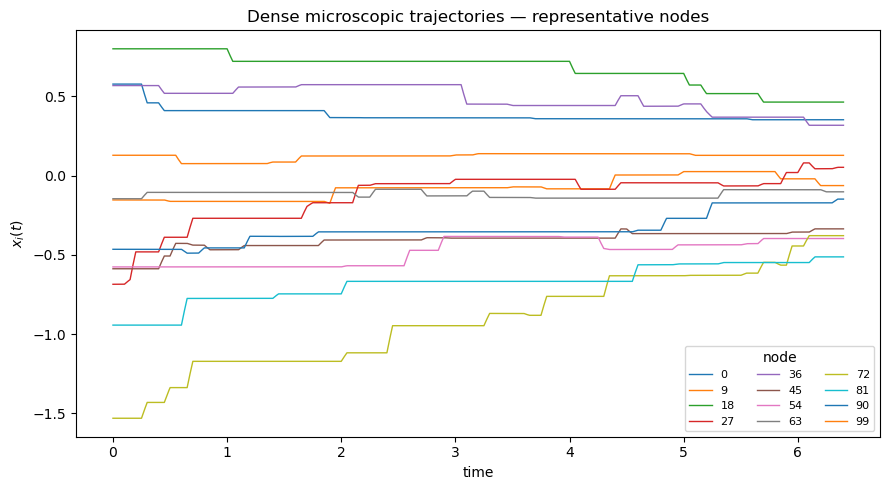

Saved variance figure to: stage7_scaling_outputs\dense_trajectory_variance.png


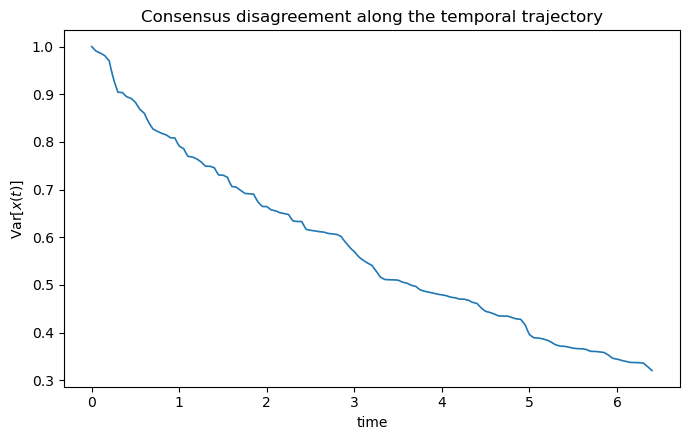

In [18]:
# ============================================================
# Cell 6 — Dense trajectory on the microscopic temporal network
# ============================================================
#
# Dynamics
# --------
#
# During microscopic snapshot k:
#
#     dx/dt = K_k x
#
# where K_k = -kappa L_k is fixed for TAU_SNAPSHOT.
#
# Although F_eff is computed forward from the known generators,
# we still record a dense microscopic trajectory for later:
#
#   - TIF reconstruction;
#   - trajectory-level validation;
#   - finite-data experiments;
#   - visualization;
#   - comparison between microscopic and effective dynamics.
#
#
# Numerical strategy
# ------------------
#
# Because K_k is constant inside each snapshot, use
#
#     scipy.sparse.linalg.expm_multiply
#
# to evaluate
#
#     x(t+s) = exp(s K_k) x(t)
#
# directly at many points inside the snapshot.
#
# This avoids ordinary ODE integration error.
# ============================================================


# ------------------------------------------------------------
# Dense-recording parameters
# ------------------------------------------------------------

DYNAMICS_SEED = 20260829
rng_dyn = np.random.default_rng(DYNAMICS_SEED)

# Number of equal recording intervals inside each microscopic
# snapshot.
#
# tau = 0.05 and 50 intervals gives
#
#     dt_record = 0.001
#
RECORD_INTERVALS_PER_SNAPSHOT = 50

DT_RECORD = (
    TAU_SNAPSHOT
    / RECORD_INTERVALS_PER_SNAPSHOT
)

N_TRAJECTORY_POINTS = (
    N_SNAPSHOTS
    * RECORD_INTERVALS_PER_SNAPSHOT
    + 1
)


# ------------------------------------------------------------
# Initial condition
# ------------------------------------------------------------
#
# Use a heterogeneous zero-mean state with unit RMS amplitude.
#
# Centering is convenient because linear consensus conserves
# the global mean exactly.
# ------------------------------------------------------------

x0 = rng_dyn.normal(
    loc=0.0,
    scale=1.0,
    size=N
)

x0 = x0 - x0.mean()

# Normalize RMS to 1
x0 = x0 / np.sqrt(
    np.mean(x0**2)
)


# ------------------------------------------------------------
# Containers
# ------------------------------------------------------------

trajectory_times = []
trajectory_states = []
trajectory_derivatives = []
trajectory_snapshot_idx = []

# Store the exact states at every topology-switching boundary:
#
#     t = 0, tau, 2 tau, ..., 128 tau
#
boundary_times = np.arange(
    N_SNAPSHOTS + 1,
    dtype=float
) * TAU_SNAPSHOT

boundary_states = np.empty(
    (N_SNAPSHOTS + 1, N),
    dtype=float
)

boundary_states[0] = x0


# ------------------------------------------------------------
# Piecewise-exact temporal evolution
# ------------------------------------------------------------

x_current = x0.copy()

print("Running dense microscopic dynamics...")
print("-------------------------------------")
print(
    f"record intervals / snapshot = "
    f"{RECORD_INTERVALS_PER_SNAPSHOT}"
)
print(
    f"record dt                   = "
    f"{DT_RECORD:.6f}"
)
print(
    f"expected trajectory points  = "
    f"{N_TRAJECTORY_POINTS}"
)


for snapshot_idx, K in enumerate(generator_snapshots):

    # --------------------------------------------------------
    # Evaluate exp(s K) x_current at:
    #
    #     s = 0, dt, 2dt, ..., tau
    #
    # Shape:
    #
    #     (RECORD_INTERVALS_PER_SNAPSHOT + 1, N)
    # --------------------------------------------------------

    local_X = sparse.linalg.expm_multiply(
        K,
        x_current,
        start=0.0,
        stop=TAU_SNAPSHOT,
        num=RECORD_INTERVALS_PER_SNAPSHOT + 1,
        endpoint=True
    )

    local_time = (
        snapshot_idx * TAU_SNAPSHOT
        + np.linspace(
            0.0,
            TAU_SNAPSHOT,
            RECORD_INTERVALS_PER_SNAPSHOT + 1
        )
    )

    # --------------------------------------------------------
    # Exact instantaneous derivatives:
    #
    #     dx/dt = K x
    #
    # --------------------------------------------------------

    local_dX = (
        K @ local_X.T
    ).T

    # --------------------------------------------------------
    # Do NOT duplicate the right boundary.
    #
    # For snapshot k, store:
    #
    #     [k tau, (k+1) tau)
    #
    # The final endpoint of the entire experiment is appended
    # separately after the loop.
    # --------------------------------------------------------

    trajectory_times.append(
        local_time[:-1]
    )

    trajectory_states.append(
        local_X[:-1]
    )

    trajectory_derivatives.append(
        local_dX[:-1]
    )

    trajectory_snapshot_idx.append(
        np.full(
            RECORD_INTERVALS_PER_SNAPSHOT,
            snapshot_idx,
            dtype=int
        )
    )

    # --------------------------------------------------------
    # Exact state at the next topology-switching boundary
    # --------------------------------------------------------

    x_current = local_X[-1].copy()

    boundary_states[
        snapshot_idx + 1
    ] = x_current


# ------------------------------------------------------------
# Append final trajectory point
# ------------------------------------------------------------

trajectory_times.append(
    np.array([TOTAL_TIME])
)

trajectory_states.append(
    x_current[None, :]
)

# At the final time the future topology is undefined.
# For bookkeeping, use the final microscopic generator.
final_derivative = (
    generator_snapshots[-1] @ x_current
)

trajectory_derivatives.append(
    final_derivative[None, :]
)

trajectory_snapshot_idx.append(
    np.array(
        [N_SNAPSHOTS - 1],
        dtype=int
    )
)


# ------------------------------------------------------------
# Assemble dense arrays
# ------------------------------------------------------------

trajectory_t = np.concatenate(
    trajectory_times
)

trajectory_X = np.vstack(
    trajectory_states
)

trajectory_dXdt = np.vstack(
    trajectory_derivatives
)

trajectory_snapshot = np.concatenate(
    trajectory_snapshot_idx
)


# ------------------------------------------------------------
# Basic shape checks
# ------------------------------------------------------------

assert trajectory_X.shape == (
    N_TRAJECTORY_POINTS,
    N
)

assert trajectory_dXdt.shape == (
    N_TRAJECTORY_POINTS,
    N
)

assert trajectory_t.shape == (
    N_TRAJECTORY_POINTS,
)

assert trajectory_snapshot.shape == (
    N_TRAJECTORY_POINTS,
)

assert boundary_states.shape == (
    N_SNAPSHOTS + 1,
    N
)


# ------------------------------------------------------------
# Dynamical diagnostics
# ------------------------------------------------------------

trajectory_mean = trajectory_X.mean(
    axis=1
)

trajectory_variance = trajectory_X.var(
    axis=1
)

trajectory_rms = np.sqrt(
    np.mean(
        trajectory_X**2,
        axis=1
    )
)

trajectory_speed = np.linalg.norm(
    trajectory_dXdt,
    axis=1
)

mean_conservation_error = np.max(
    np.abs(
        trajectory_mean
        - trajectory_mean[0]
    )
)

# Consensus with symmetric Laplacians should not increase
# quadratic disagreement except for numerical roundoff.
variance_increments = np.diff(
    trajectory_variance
)

max_variance_increase = np.max(
    variance_increments
)

n_variance_increases = np.sum(
    variance_increments > 1e-12
)

all_finite = (
    np.all(np.isfinite(trajectory_X))
    and
    np.all(np.isfinite(trajectory_dXdt))
)


# ------------------------------------------------------------
# Snapshot-level trajectory diagnostics
# ------------------------------------------------------------

boundary_variance = boundary_states.var(
    axis=1
)

boundary_rms = np.sqrt(
    np.mean(
        boundary_states**2,
        axis=1
    )
)

snapshot_dynamics_df = pd.DataFrame({
    "boundary_idx": np.arange(
        N_SNAPSHOTS + 1
    ),
    "time": boundary_times,
    "variance": boundary_variance,
    "rms": boundary_rms,
})


# ------------------------------------------------------------
# Report
# ------------------------------------------------------------

print()
print("Dense trajectory")
print("================")

print()
print("Sampling")
print("--------")
print(
    f"trajectory points          = "
    f"{len(trajectory_t)}"
)
print(
    f"state dimension            = "
    f"{N}"
)
print(
    f"record dt                  = "
    f"{DT_RECORD:.6f}"
)
print(
    f"points per snapshot        = "
    f"{RECORD_INTERVALS_PER_SNAPSHOT}"
)
print(
    f"total time                 = "
    f"{trajectory_t[-1]:.6f}"
)

print()
print("Initial state")
print("-------------")
print(
    f"mean                       = "
    f"{trajectory_mean[0]:.6e}"
)
print(
    f"variance                   = "
    f"{trajectory_variance[0]:.6f}"
)
print(
    f"RMS                        = "
    f"{trajectory_rms[0]:.6f}"
)

print()
print("Final state")
print("-----------")
print(
    f"mean                       = "
    f"{trajectory_mean[-1]:.6e}"
)
print(
    f"variance                   = "
    f"{trajectory_variance[-1]:.6f}"
)
print(
    f"RMS                        = "
    f"{trajectory_rms[-1]:.6f}"
)

print()
print("Sanity checks")
print("-------------")
print(
    f"max mean-conservation err  = "
    f"{mean_conservation_error:.3e}"
)
print(
    f"max variance increase      = "
    f"{max_variance_increase:.3e}"
)
print(
    f"variance increases >1e-12 = "
    f"{n_variance_increases}"
)
print(
    f"all values finite          = "
    f"{all_finite}"
)

print()
print("Trajectory excitation")
print("---------------------")
print(
    f"mean ||dx/dt||             = "
    f"{trajectory_speed.mean():.6f}"
)
print(
    f"median ||dx/dt||           = "
    f"{np.median(trajectory_speed):.6f}"
)
print(
    f"final / initial variance   = "
    f"{trajectory_variance[-1] / trajectory_variance[0]:.6f}"
)


# ------------------------------------------------------------
# Assertions
# ------------------------------------------------------------

assert all_finite

assert mean_conservation_error < 1e-10

assert n_variance_increases == 0


# ------------------------------------------------------------
# Save the complete dense trajectory
# ------------------------------------------------------------
#
# NPZ is the primary lossless trajectory file.
#
# It stores:
#   t
#   X
#   dXdt
#   microscopic snapshot index
#   topology-boundary states
#   initial condition
#   recording metadata
# ------------------------------------------------------------

trajectory_path = (
    OUTDIR /
    "dense_microscopic_trajectory.npz"
)

np.savez_compressed(
    trajectory_path,

    t=trajectory_t,
    X=trajectory_X,
    dXdt=trajectory_dXdt,
    snapshot_idx=trajectory_snapshot,

    boundary_t=boundary_times,
    boundary_X=boundary_states,

    x0=x0,

    dt_record=np.array(DT_RECORD),
    tau_snapshot=np.array(TAU_SNAPSHOT),
    n_snapshots=np.array(N_SNAPSHOTS),
    intervals_per_snapshot=np.array(
        RECORD_INTERVALS_PER_SNAPSHOT
    ),
)

print()
print(
    f"Saved dense trajectory to: "
    f"{trajectory_path}"
)


# ------------------------------------------------------------
# Save boundary-level diagnostics
# ------------------------------------------------------------

boundary_csv_path = (
    OUTDIR /
    "trajectory_boundary_diagnostics.csv"
)

snapshot_dynamics_df.to_csv(
    boundary_csv_path,
    index=False
)

print(
    f"Saved boundary diagnostics to: "
    f"{boundary_csv_path}"
)


# ------------------------------------------------------------
# Plot 1 — representative node trajectories
# ------------------------------------------------------------

# Fixed, reproducible subset spanning the node labels.
plot_nodes = np.linspace(
    0,
    N - 1,
    12,
    dtype=int
)

fig, ax = plt.subplots(
    figsize=(9, 5)
)

for node in plot_nodes:

    ax.plot(
        trajectory_t,
        trajectory_X[:, node],
        linewidth=1.0,
        label=f"{node}"
    )

ax.set_xlabel("time")
ax.set_ylabel(r"$x_i(t)$")
ax.set_title(
    "Dense microscopic trajectories — representative nodes"
)

ax.legend(
    title="node",
    ncol=3,
    fontsize=8
)

plt.tight_layout()

trajectory_fig_path = (
    OUTDIR /
    "dense_trajectory_representative_nodes.png"
)

fig.savefig(
    trajectory_fig_path,
    dpi=250,
    bbox_inches="tight"
)

print(
    f"Saved trajectory figure to: "
    f"{trajectory_fig_path}"
)

plt.show()


# ------------------------------------------------------------
# Plot 2 — disagreement / variance decay
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(7, 4.5)
)

ax.plot(
    trajectory_t,
    trajectory_variance,
    linewidth=1.2
)

ax.set_xlabel("time")
ax.set_ylabel(
    r"$\mathrm{Var}[x(t)]$"
)

ax.set_title(
    "Consensus disagreement along the temporal trajectory"
)

plt.tight_layout()

variance_fig_path = (
    OUTDIR /
    "dense_trajectory_variance.png"
)

fig.savefig(
    variance_fig_path,
    dpi=250,
    bbox_inches="tight"
)

print(
    f"Saved variance figure to: "
    f"{variance_fig_path}"
)

plt.show()

Full effective network — m=128

Total possible node pairs
-------------------------
C(N,2)                    = 4950

Generator-sector norms
----------------------
||K_avg||_F               = 1.145537
||K_comm||_F              = 0.058205
||K_nested||_F            = 0.010732
||K_BCH||_F               = 1.149191
||K_exact||_F             = 1.149210

Relative sector strengths
-------------------------
comm / avg                = 0.050810
nested / avg              = 0.009369
nested / comm             = 0.184388

BCH accuracy
------------
relative error vs exact   = 1.584498e-03

Pair-support / strength statistics
----------------------------------


,sector,count,mean,median,q75,q90,q95,max,l2,fraction_of_all_pairs
0,naive,617,0.008306,0.007812,0.007812,0.007812,0.015625,0.023438,0.211948,0.124646
1,commutator,3365,0.000460,0.000195,0.000391,0.000977,0.001562,0.006250,0.041157,0.679798
2,nested,4866,0.000058,0.000034,0.000070,0.000123,0.000174,0.001882,0.007159,0.983030
3,BCH_total,4904,0.001257,0.000199,0.000395,0.007827,0.007990,0.024468,0.218742,0.990707
4,exact_total,4950,0.001248,0.000201,0.000400,0.007825,0.007984,0.024473,0.218836,1.000000
5,comm_generated_only,2781,0.000300,0.000195,0.000391,0.000586,0.000586,0.001367,0.018065,0.561818
6,nested_generated_only,1506,0.000029,0.000020,0.000039,0.000065,0.000091,0.000243,0.001631,0.304242



Exclusive generated supports
----------------------------
direct naive pairs         = 617
new from commutator        = 2781
new only at nested sector  = 1506
exact effective pairs      = 4950
Saved figure to: stage7_scaling_outputs\effective_w128_sector_strength_distributions.png


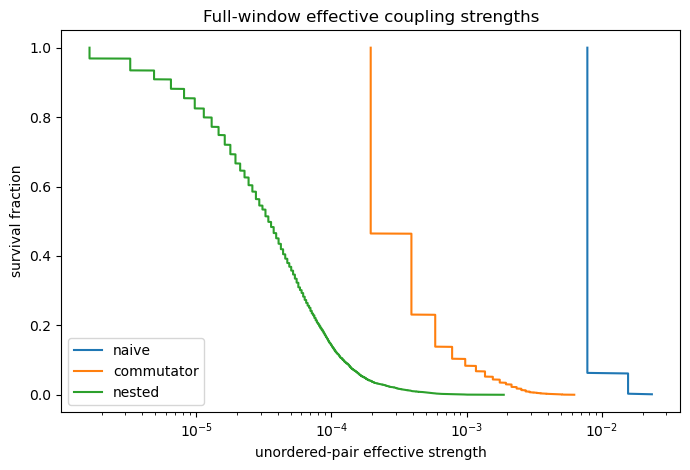

Saved sector statistics to: stage7_scaling_outputs\effective_w128_sector_statistics.csv


In [19]:
# ============================================================
# Cell 7 — Full-scale effective network (m = 128)
# ============================================================
#
# Analyze the effective generator over the ENTIRE temporal
# sequence:
#
#     [0, 128)
#
# We distinguish:
#
#   K_avg
#       naive temporal aggregation
#
#   K_comm
#       first-commutator correction
#
#   K_nested
#       nested-commutator correction
#
#   K_BCH
#       K_avg + K_comm + K_nested
#
#   K_exact
#       exact log-propagator effective generator
#
# IMPORTANT:
# For the current LINEAR consensus dynamics, all of these
# remain pairwise linear couplings.
#
# K_nested is a nested temporal-composition sector,
# NOT a genuine three-body interaction sector.
# ============================================================


# ------------------------------------------------------------
# Extract the global window
# ------------------------------------------------------------

GLOBAL_W = 128

global_result = effective_by_scale[GLOBAL_W][0]

K_avg_global = global_result["K_avg"].toarray()
K_comm_global = global_result["K_comm"].toarray()
K_nested_global = global_result["K_nested"].toarray()

K_bch_global = global_result["K_eff_2"].toarray()

K_exact_global = np.asarray(
    global_result["K_exact"],
    dtype=float
)


# ------------------------------------------------------------
# Basic setup
# ------------------------------------------------------------

N_PAIRS_TOTAL = N * (N - 1) // 2


def upper_triangle_values(M):
    """
    Values M_ij for i < j.
    """
    iu = np.triu_indices(
        M.shape[0],
        k=1
    )
    return M[iu]


def unordered_pair_strength(M):
    """
    For a possibly directed matrix M, assign one strength
    to unordered pair {i,j} using

        sqrt((M_ij^2 + M_ji^2)/2).

    This preserves both directions without cancellation.
    """

    iu = np.triu_indices(
        M.shape[0],
        k=1
    )

    i = iu[0]
    j = iu[1]

    return np.sqrt(
        0.5 * (
            M[i, j]**2
            + M[j, i]**2
        )
    )


def pair_support_from_strength(
    strength,
    tol
):
    return strength > tol


# ------------------------------------------------------------
# Pair-strength arrays
# ------------------------------------------------------------

strength_avg = unordered_pair_strength(
    K_avg_global
)

strength_comm = unordered_pair_strength(
    K_comm_global
)

strength_nested = unordered_pair_strength(
    K_nested_global
)

strength_bch = unordered_pair_strength(
    K_bch_global
)

strength_exact = unordered_pair_strength(
    K_exact_global
)


# ------------------------------------------------------------
# Algebraic support
# ------------------------------------------------------------

ALG_TOL = COEFF_TOL

mask_avg = strength_avg > ALG_TOL
mask_comm = strength_comm > ALG_TOL
mask_nested = strength_nested > ALG_TOL
mask_bch = strength_bch > ALG_TOL
mask_exact = strength_exact > ALG_TOL


# ------------------------------------------------------------
# Sector-specific generated supports
# ------------------------------------------------------------
#
# "comm-generated":
#     absent from naive support, but present in K_comm
#
# "nested-generated":
#     absent from both naive and comm support,
#     but present in K_nested
#
# This gives an exclusive structural decomposition.
# ------------------------------------------------------------

mask_comm_generated = (
    (~mask_avg)
    & mask_comm
)

mask_nested_generated = (
    (~mask_avg)
    & (~mask_comm)
    & mask_nested
)


# ------------------------------------------------------------
# Norms
# ------------------------------------------------------------

norm_avg = np.linalg.norm(
    K_avg_global,
    ord="fro"
)

norm_comm = np.linalg.norm(
    K_comm_global,
    ord="fro"
)

norm_nested = np.linalg.norm(
    K_nested_global,
    ord="fro"
)

norm_bch = np.linalg.norm(
    K_bch_global,
    ord="fro"
)

norm_exact = np.linalg.norm(
    K_exact_global,
    ord="fro"
)

bch_error = (
    np.linalg.norm(
        K_bch_global
        - K_exact_global,
        ord="fro"
    )
    / norm_exact
)


# ------------------------------------------------------------
# Weight statistics helper
# ------------------------------------------------------------

def strength_stats(
    strength,
    mask
):
    values = strength[mask]

    if len(values) == 0:
        return {
            "count": 0,
            "mean": 0.0,
            "median": 0.0,
            "q75": 0.0,
            "q90": 0.0,
            "q95": 0.0,
            "max": 0.0,
            "l2": 0.0,
        }

    return {
        "count": len(values),
        "mean": np.mean(values),
        "median": np.median(values),
        "q75": np.quantile(values, 0.75),
        "q90": np.quantile(values, 0.90),
        "q95": np.quantile(values, 0.95),
        "max": np.max(values),
        "l2": np.linalg.norm(values),
    }


stats_avg = strength_stats(
    strength_avg,
    mask_avg
)

stats_comm = strength_stats(
    strength_comm,
    mask_comm
)

stats_nested = strength_stats(
    strength_nested,
    mask_nested
)

stats_bch = strength_stats(
    strength_bch,
    mask_bch
)

stats_exact = strength_stats(
    strength_exact,
    mask_exact
)

stats_comm_generated = strength_stats(
    strength_comm,
    mask_comm_generated
)

stats_nested_generated = strength_stats(
    strength_nested,
    mask_nested_generated
)


# ------------------------------------------------------------
# Summary DataFrame
# ------------------------------------------------------------

sector_rows = []

for name, stats in [
    ("naive", stats_avg),
    ("commutator", stats_comm),
    ("nested", stats_nested),
    ("BCH_total", stats_bch),
    ("exact_total", stats_exact),
    ("comm_generated_only", stats_comm_generated),
    ("nested_generated_only", stats_nested_generated),
]:

    sector_rows.append({
        "sector": name,
        **stats,
        "fraction_of_all_pairs":
            stats["count"] / N_PAIRS_TOTAL
    })


global_sector_df = pd.DataFrame(
    sector_rows
)


# ------------------------------------------------------------
# Report
# ------------------------------------------------------------

print("Full effective network — m=128")
print("==============================")

print()
print("Total possible node pairs")
print("-------------------------")
print(
    f"C(N,2)                    = "
    f"{N_PAIRS_TOTAL}"
)

print()
print("Generator-sector norms")
print("----------------------")
print(
    f"||K_avg||_F               = "
    f"{norm_avg:.6f}"
)
print(
    f"||K_comm||_F              = "
    f"{norm_comm:.6f}"
)
print(
    f"||K_nested||_F            = "
    f"{norm_nested:.6f}"
)
print(
    f"||K_BCH||_F               = "
    f"{norm_bch:.6f}"
)
print(
    f"||K_exact||_F             = "
    f"{norm_exact:.6f}"
)

print()
print("Relative sector strengths")
print("-------------------------")
print(
    f"comm / avg                = "
    f"{norm_comm / norm_avg:.6f}"
)
print(
    f"nested / avg              = "
    f"{norm_nested / norm_avg:.6f}"
)
print(
    f"nested / comm             = "
    f"{norm_nested / norm_comm:.6f}"
)

print()
print("BCH accuracy")
print("------------")
print(
    f"relative error vs exact   = "
    f"{bch_error:.6e}"
)

print()
print("Pair-support / strength statistics")
print("----------------------------------")

display(global_sector_df)


# ------------------------------------------------------------
# Explicit structural counts
# ------------------------------------------------------------

print()
print("Exclusive generated supports")
print("----------------------------")

print(
    f"direct naive pairs         = "
    f"{mask_avg.sum()}"
)

print(
    f"new from commutator        = "
    f"{mask_comm_generated.sum()}"
)

print(
    f"new only at nested sector  = "
    f"{mask_nested_generated.sum()}"
)

print(
    f"exact effective pairs      = "
    f"{mask_exact.sum()}"
)


# ------------------------------------------------------------
# Weight-distribution plot
# ------------------------------------------------------------
#
# Only nonzero algebraic supports are shown.
# Log scale is useful because generated interactions span
# several orders of magnitude.
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(7, 4.8)
)

for values, mask, label in [
    (
        strength_avg,
        mask_avg,
        "naive"
    ),
    (
        strength_comm,
        mask_comm,
        "commutator"
    ),
    (
        strength_nested,
        mask_nested,
        "nested"
    ),
]:

    positive = values[mask]

    if len(positive) > 0:

        sorted_values = np.sort(
            positive
        )

        survival = (
            1.0
            - np.arange(len(sorted_values))
            / len(sorted_values)
        )

        ax.plot(
            sorted_values,
            survival,
            label=label
        )


ax.set_xscale("log")

ax.set_xlabel(
    "unordered-pair effective strength"
)

ax.set_ylabel(
    "survival fraction"
)

ax.set_title(
    "Full-window effective coupling strengths"
)

ax.legend()

plt.tight_layout()

strength_fig_path = (
    OUTDIR /
    "effective_w128_sector_strength_distributions.png"
)

fig.savefig(
    strength_fig_path,
    dpi=250,
    bbox_inches="tight"
)

print(
    f"Saved figure to: "
    f"{strength_fig_path}"
)

plt.show()


# ------------------------------------------------------------
# Save table
# ------------------------------------------------------------

sector_csv_path = (
    OUTDIR /
    "effective_w128_sector_statistics.csv"
)

global_sector_df.to_csv(
    sector_csv_path,
    index=False
)

print(
    f"Saved sector statistics to: "
    f"{sector_csv_path}"
)

In [23]:
# ============================================================
# Cell 7.5a — Effective-network visualization + source statistics
# ============================================================
#
# For any effective observation window:
#
#   Figure 1 : total effective network
#   Figure 2 : naive aggregation sector
#   Figure 3 : single-commutator sector
#   Figure 4 : double-commutator sector
#
# Default:
#   total_mode = "black"
#
# Optional:
#   total_mode = "overlay"
#
# Each call also generates a source-statistics DataFrame:
#
#   naive
#   commutator
#   nested
#   BCH_total
#   exact_total              (if available)
#   comm_generated_only
#   nested_generated_only
#
# All resolved couplings above PLOT_EDGE_TOL are retained.
# Weight is encoded mainly through opacity.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import networkx as nx

from scipy import sparse
from IPython.display import display


# ------------------------------------------------------------
# Appearance
# ------------------------------------------------------------

SECTOR_COLORS = {
    "naive": "#1f77b4",
    "comm": "#ff7f0e",
    "nested": "#2ca02c",
}

TOTAL_COLOR = "#111111"

EDGE_WIDTH_MIN = 0.08
EDGE_WIDTH_MAX = 0.50

EDGE_ALPHA_MIN = 0.010
EDGE_ALPHA_MAX = 0.40

ALPHA_GAMMA = 1.5

NODE_SIZE_EFFECTIVE = 30

PLOT_EDGE_TOL = 1e-12

EFFECTIVE_FIGSIZE = (10.5, 10.5)
EFFECTIVE_DPI = 300


# ------------------------------------------------------------
# Matrix conversion
# ------------------------------------------------------------

def as_dense(M):

    if sparse.issparse(M):
        return M.toarray()

    return np.asarray(
        M,
        dtype=float
    )


# ------------------------------------------------------------
# Full unordered-pair strength vector
# ------------------------------------------------------------

def pair_strength_vector(M):
    """
    For each unordered pair {i,j},

        s_ij = sqrt((M_ij^2 + M_ji^2) / 2)

    Returns strengths for ALL C(N,2) pairs.
    """

    M = as_dense(M)

    n_nodes = M.shape[0]

    iu = np.triu_indices(
        n_nodes,
        k=1
    )

    ii = iu[0]
    jj = iu[1]

    strength = np.sqrt(
        0.5 * (
            M[ii, jj]**2
            + M[jj, ii]**2
        )
    )

    return ii, jj, strength


# ------------------------------------------------------------
# Extract plotted edges
# ------------------------------------------------------------

def extract_effective_pairs(
    M,
    tol=PLOT_EDGE_TOL
):

    ii, jj, strength = (
        pair_strength_vector(M)
    )

    mask = strength > tol

    edges = list(
        zip(
            ii[mask].astype(int),
            jj[mask].astype(int)
        )
    )

    return (
        edges,
        strength[mask]
    )


# ------------------------------------------------------------
# Source-statistics DataFrame
# ------------------------------------------------------------

def effective_source_dataframe(
    result,
    tol=PLOT_EDGE_TOL
):
    """
    Reproduce the earlier edge/source statistics for one
    effective window.
    """

    K_avg = as_dense(
        result["K_avg"]
    )

    K_comm = as_dense(
        result["K_comm"]
    )

    K_nested = as_dense(
        result["K_nested"]
    )

    K_bch = (
        K_avg
        + K_comm
        + K_nested
    )

    _, _, s_avg = pair_strength_vector(
        K_avg
    )

    _, _, s_comm = pair_strength_vector(
        K_comm
    )

    _, _, s_nested = pair_strength_vector(
        K_nested
    )

    _, _, s_bch = pair_strength_vector(
        K_bch
    )

    mask_avg = s_avg > tol
    mask_comm = s_comm > tol
    mask_nested = s_nested > tol
    mask_bch = s_bch > tol

    # Exclusive newly generated supports
    mask_comm_generated = (
        (~mask_avg)
        & mask_comm
    )

    mask_nested_generated = (
        (~mask_avg)
        & (~mask_comm)
        & mask_nested
    )

    n_pairs_total = len(
        s_avg
    )


    def stats_row(
        sector,
        strength,
        mask
    ):

        values = strength[
            mask
        ]

        if len(values) == 0:

            return {
                "sector": sector,
                "count": 0,
                "mean": 0.0,
                "median": 0.0,
                "q75": 0.0,
                "q90": 0.0,
                "q95": 0.0,
                "max": 0.0,
                "l2": 0.0,
                "fraction_of_all_pairs": 0.0,
            }

        return {
            "sector": sector,

            "count":
                int(len(values)),

            "mean":
                float(np.mean(values)),

            "median":
                float(np.median(values)),

            "q75":
                float(
                    np.quantile(
                        values,
                        0.75
                    )
                ),

            "q90":
                float(
                    np.quantile(
                        values,
                        0.90
                    )
                ),

            "q95":
                float(
                    np.quantile(
                        values,
                        0.95
                    )
                ),

            "max":
                float(
                    np.max(values)
                ),

            "l2":
                float(
                    np.linalg.norm(
                        values
                    )
                ),

            "fraction_of_all_pairs":
                float(
                    len(values)
                    / n_pairs_total
                ),
        }


    rows = [
        stats_row(
            "naive",
            s_avg,
            mask_avg
        ),

        stats_row(
            "commutator",
            s_comm,
            mask_comm
        ),

        stats_row(
            "nested",
            s_nested,
            mask_nested
        ),

        stats_row(
            "BCH_total",
            s_bch,
            mask_bch
        ),
    ]


    # Exact total, if Cell 5.5 has already been run
    if "K_exact" in result:

        K_exact = as_dense(
            result["K_exact"]
        )

        _, _, s_exact = (
            pair_strength_vector(
                K_exact
            )
        )

        mask_exact = (
            s_exact > tol
        )

        rows.append(
            stats_row(
                "exact_total",
                s_exact,
                mask_exact
            )
        )


    rows.extend([
        stats_row(
            "comm_generated_only",
            s_comm,
            mask_comm_generated
        ),

        stats_row(
            "nested_generated_only",
            s_nested,
            mask_nested_generated
        ),
    ])


    return pd.DataFrame(
        rows
    )


# ------------------------------------------------------------
# Common weight -> opacity / width mapping
# ------------------------------------------------------------

def build_weight_scaler(
    strength_arrays
):

    nonempty = [
        np.asarray(
            x,
            dtype=float
        )
        for x in strength_arrays
        if len(x) > 0
    ]

    if len(nonempty) == 0:
        raise ValueError(
            "No nonzero effective couplings found."
        )

    all_strength = np.concatenate(
        nonempty
    )

    positive = all_strength[
        all_strength > 0
    ]

    s_min = positive.min()
    s_max = positive.max()

    log_min = np.log10(
        s_min
    )

    log_max = np.log10(
        s_max
    )


    def scaler(strength):

        strength = np.asarray(
            strength,
            dtype=float
        )

        if len(strength) == 0:

            return (
                np.array([]),
                np.array([])
            )

        log_s = np.log10(
            np.maximum(
                strength,
                s_min
            )
        )

        if np.isclose(
            log_min,
            log_max
        ):

            z = np.ones_like(
                strength
            )

        else:

            z = (
                (log_s - log_min)
                /
                (log_max - log_min)
            )

        z = np.clip(
            z,
            0.0,
            1.0
        )

        # Opacity carries most weight information
        z_alpha = (
            z ** ALPHA_GAMMA
        )

        alphas = (
            EDGE_ALPHA_MIN
            +
            (
                EDGE_ALPHA_MAX
                - EDGE_ALPHA_MIN
            )
            * z_alpha
        )

        # Width varies mildly
        widths = (
            EDGE_WIDTH_MIN
            +
            (
                EDGE_WIDTH_MAX
                - EDGE_WIDTH_MIN
            )
            * z
        )

        return (
            widths,
            alphas
        )

    return scaler


# ------------------------------------------------------------
# Fast batched edge rendering
# ------------------------------------------------------------

def draw_sector_batch(
    ax,
    G_nodes,
    edges,
    strengths,
    pos,
    color,
    scaler
):

    if len(edges) == 0:
        return

    widths, alphas = (
        scaler(
            strengths
        )
    )

    rgb = mcolors.to_rgb(
        color
    )

    rgba = np.column_stack([
        np.full(
            len(edges),
            rgb[0]
        ),

        np.full(
            len(edges),
            rgb[1]
        ),

        np.full(
            len(edges),
            rgb[2]
        ),

        alphas
    ])

    nx.draw_networkx_edges(
        G_nodes,
        pos,
        ax=ax,
        edgelist=edges,
        width=widths,
        edge_color=rgba,
        arrows=False
    )


# ------------------------------------------------------------
# Nodes
# ------------------------------------------------------------

def draw_effective_nodes(
    ax,
    G_nodes,
    pos
):

    nx.draw_networkx_nodes(
        G_nodes,
        pos,
        ax=ax,
        node_size=NODE_SIZE_EFFECTIVE,
        node_color="#dedede",
        edgecolors="#555555",
        linewidths=0.35
    )


# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------

def format_effective_axis(
    ax,
    title
):

    ax.set_title(
        title,
        fontsize=15,
        pad=12
    )

    ax.set_xticks([])
    ax.set_yticks([])

    ax.set_aspect(
        "equal"
    )

    for spine in (
        ax.spines.values()
    ):
        spine.set_visible(
            False
        )


# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

def save_effective_panel(
    fig,
    window_size,
    window_idx,
    component
):

    save_name = (
        f"effective_w{window_size:03d}_"
        f"idx{window_idx:03d}_"
        f"{component}.png"
    )

    save_path = (
        OUTDIR /
        save_name
    )

    fig.savefig(
        save_path,
        dpi=EFFECTIVE_DPI,
        bbox_inches="tight"
    )

    print(
        f"      saved: "
        f"{save_path}"
    )

    return save_path


# ------------------------------------------------------------
# Draw one complete figure
# ------------------------------------------------------------

def make_effective_panel(
    G_nodes,
    layers,
    pos,
    scaler,
    title
):

    fig, ax = plt.subplots(
        figsize=EFFECTIVE_FIGSIZE
    )

    for (
        edges,
        strengths,
        color
    ) in layers:

        draw_sector_batch(
            ax=ax,
            G_nodes=G_nodes,
            edges=edges,
            strengths=strengths,
            pos=pos,
            color=color,
            scaler=scaler
        )

    draw_effective_nodes(
        ax,
        G_nodes,
        pos
    )

    format_effective_axis(
        ax,
        title
    )

    plt.tight_layout()

    return fig


# ============================================================
# Main reusable function
# ============================================================

def plot_effective_decomposition(
    result,
    window_size,
    pos,
    window_idx=None,
    total_mode="black",
    show=True
):
    """
    Produce:

        1 total effective network
        3 source-decomposition networks
        1 source-statistics DataFrame

    total_mode
    ----------
    "black":
        preferred current default

    "overlay":
        nested green
        + comm orange
        + naive blue
    """

    if total_mode not in {
        "black",
        "overlay"
    }:

        raise ValueError(
            "total_mode must be "
            "'black' or 'overlay'."
        )


    if window_idx is None:

        window_idx = int(
            result["window_idx"]
        )


    # --------------------------------------------------------
    # Matrices
    # --------------------------------------------------------

    K_avg = as_dense(
        result["K_avg"]
    )

    K_comm = as_dense(
        result["K_comm"]
    )

    K_nested = as_dense(
        result["K_nested"]
    )

    K_total = (
        K_avg
        + K_comm
        + K_nested
    )


    n_nodes = (
        K_avg.shape[0]
    )

    G_nodes = nx.Graph()

    G_nodes.add_nodes_from(
        range(n_nodes)
    )


    # --------------------------------------------------------
    # Edge data
    # --------------------------------------------------------

    edges_avg, strength_avg = (
        extract_effective_pairs(
            K_avg
        )
    )

    edges_comm, strength_comm = (
        extract_effective_pairs(
            K_comm
        )
    )

    edges_nested, strength_nested = (
        extract_effective_pairs(
            K_nested
        )
    )

    edges_total, strength_total = (
        extract_effective_pairs(
            K_total
        )
    )


    # --------------------------------------------------------
    # Common absolute visual scale
    # --------------------------------------------------------

    scaler = build_weight_scaler([
        strength_avg,
        strength_comm,
        strength_nested,
        strength_total,
    ])


    # --------------------------------------------------------
    # Source statistics
    # --------------------------------------------------------

    source_df = (
        effective_source_dataframe(
            result
        )
    )


    # --------------------------------------------------------
    # Metadata
    # --------------------------------------------------------

    start = int(
        result["start"]
    )

    end = int(
        result["end"]
    )

    physical_start = (
        start
        * TAU_SNAPSHOT
    )

    physical_end = (
        end
        * TAU_SNAPSHOT
    )

    subtitle = (
        f"m = {window_size}, "
        f"window = {window_idx}, "
        f"snapshots [{start}, {end})"
    )


    print()
    print(
        f"Effective decomposition: "
        f"m={window_size}, "
        f"idx={window_idx}"
    )

    print(
        f"  snapshots : "
        f"[{start}, {end})"
    )

    print(
        f"  time      : "
        f"[{physical_start:.3f}, "
        f"{physical_end:.3f})"
    )


    # --------------------------------------------------------
    # Display the source statistics
    # --------------------------------------------------------

    print()
    print(
        "Edge-source statistics"
    )
    print(
        "======================"
    )

    display(
        source_df
    )


    # Save statistics automatically
    source_csv = (
        OUTDIR /
        (
            f"effective_w{window_size:03d}_"
            f"idx{window_idx:03d}_"
            f"source_statistics.csv"
        )
    )

    source_df.to_csv(
        source_csv,
        index=False
    )

    print(
        f"Saved source statistics: "
        f"{source_csv}"
    )


    saved_paths = {}


    # ========================================================
    # 1. TOTAL
    # ========================================================

    print()
    print(
        f"  [1/4] total "
        f"({total_mode})..."
    )

    if total_mode == "black":

        total_layers = [
            (
                edges_total,
                strength_total,
                TOTAL_COLOR
            )
        ]

    else:

        # Weakest / densest first
        total_layers = [
            (
                edges_nested,
                strength_nested,
                SECTOR_COLORS[
                    "nested"
                ]
            ),

            (
                edges_comm,
                strength_comm,
                SECTOR_COLORS[
                    "comm"
                ]
            ),

            (
                edges_avg,
                strength_avg,
                SECTOR_COLORS[
                    "naive"
                ]
            ),
        ]


    fig = make_effective_panel(
        G_nodes=G_nodes,
        layers=total_layers,
        pos=pos,
        scaler=scaler,
        title=(
            "Total effective network\n"
            + subtitle
        )
    )

    saved_paths["total"] = (
        save_effective_panel(
            fig,
            window_size,
            window_idx,
            f"total_{total_mode}"
        )
    )

    if show:
        plt.show()
    else:
        plt.close(fig)


    # ========================================================
    # 2. NAIVE
    # ========================================================

    print(
        "  [2/4] naive..."
    )

    fig = make_effective_panel(
        G_nodes=G_nodes,

        layers=[
            (
                edges_avg,
                strength_avg,
                SECTOR_COLORS[
                    "naive"
                ]
            )
        ],

        pos=pos,
        scaler=scaler,

        title=(
            "Naive aggregation sector\n"
            + subtitle
        )
    )

    saved_paths["naive"] = (
        save_effective_panel(
            fig,
            window_size,
            window_idx,
            "naive"
        )
    )

    if show:
        plt.show()
    else:
        plt.close(fig)


    # ========================================================
    # 3. SINGLE COMMUTATOR
    # ========================================================

    print(
        "  [3/4] single commutator..."
    )

    fig = make_effective_panel(
        G_nodes=G_nodes,

        layers=[
            (
                edges_comm,
                strength_comm,
                SECTOR_COLORS[
                    "comm"
                ]
            )
        ],

        pos=pos,
        scaler=scaler,

        title=(
            "Single-commutator sector\n"
            + subtitle
        )
    )

    saved_paths[
        "single_commutator"
    ] = save_effective_panel(
        fig,
        window_size,
        window_idx,
        "single_commutator"
    )

    if show:
        plt.show()
    else:
        plt.close(fig)


    # ========================================================
    # 4. DOUBLE COMMUTATOR
    # ========================================================

    print(
        "  [4/4] double commutator..."
    )

    fig = make_effective_panel(
        G_nodes=G_nodes,

        layers=[
            (
                edges_nested,
                strength_nested,
                SECTOR_COLORS[
                    "nested"
                ]
            )
        ],

        pos=pos,
        scaler=scaler,

        title=(
            "Double-commutator sector\n"
            + subtitle
        )
    )

    saved_paths[
        "double_commutator"
    ] = save_effective_panel(
        fig,
        window_size,
        window_idx,
        "double_commutator"
    )

    if show:
        plt.show()
    else:
        plt.close(fig)


    # --------------------------------------------------------
    # Return everything useful
    # --------------------------------------------------------

    summary = {
        "window_size":
            window_size,

        "window_idx":
            window_idx,

        "start":
            start,

        "end":
            end,

        "n_naive":
            len(edges_avg),

        "n_comm":
            len(edges_comm),

        "n_nested":
            len(edges_nested),

        "n_total":
            len(edges_total),

        "source_df":
            source_df,

        "saved_paths":
            saved_paths,

        "source_csv":
            source_csv,
    }

    print(
        "  done."
    )

    return summary


Effective decomposition: m=128, idx=0
  snapshots : [0, 128)
  time      : [0.000, 6.400)

Edge-source statistics


,sector,count,mean,median,q75,q90,q95,max,l2,fraction_of_all_pairs
0,naive,617,0.008306,0.007812,0.007812,0.007812,0.015625,0.023438,0.211948,0.124646
1,commutator,3365,0.000460,0.000195,0.000391,0.000977,0.001562,0.006250,0.041157,0.679798
2,nested,4866,0.000058,0.000034,0.000070,0.000123,0.000174,0.001882,0.007159,0.983030
3,BCH_total,4904,0.001257,0.000199,0.000395,0.007827,0.007990,0.024468,0.218742,0.990707
4,exact_total,4950,0.001248,0.000201,0.000400,0.007825,0.007984,0.024473,0.218836,1.000000
5,comm_generated_only,2781,0.000300,0.000195,0.000391,0.000586,0.000586,0.001367,0.018065,0.561818
6,nested_generated_only,1506,0.000029,0.000020,0.000039,0.000065,0.000091,0.000243,0.001631,0.304242


Saved source statistics: stage7_scaling_outputs\effective_w128_idx000_source_statistics.csv

  [1/4] total (black)...
      saved: stage7_scaling_outputs\effective_w128_idx000_total_black.png


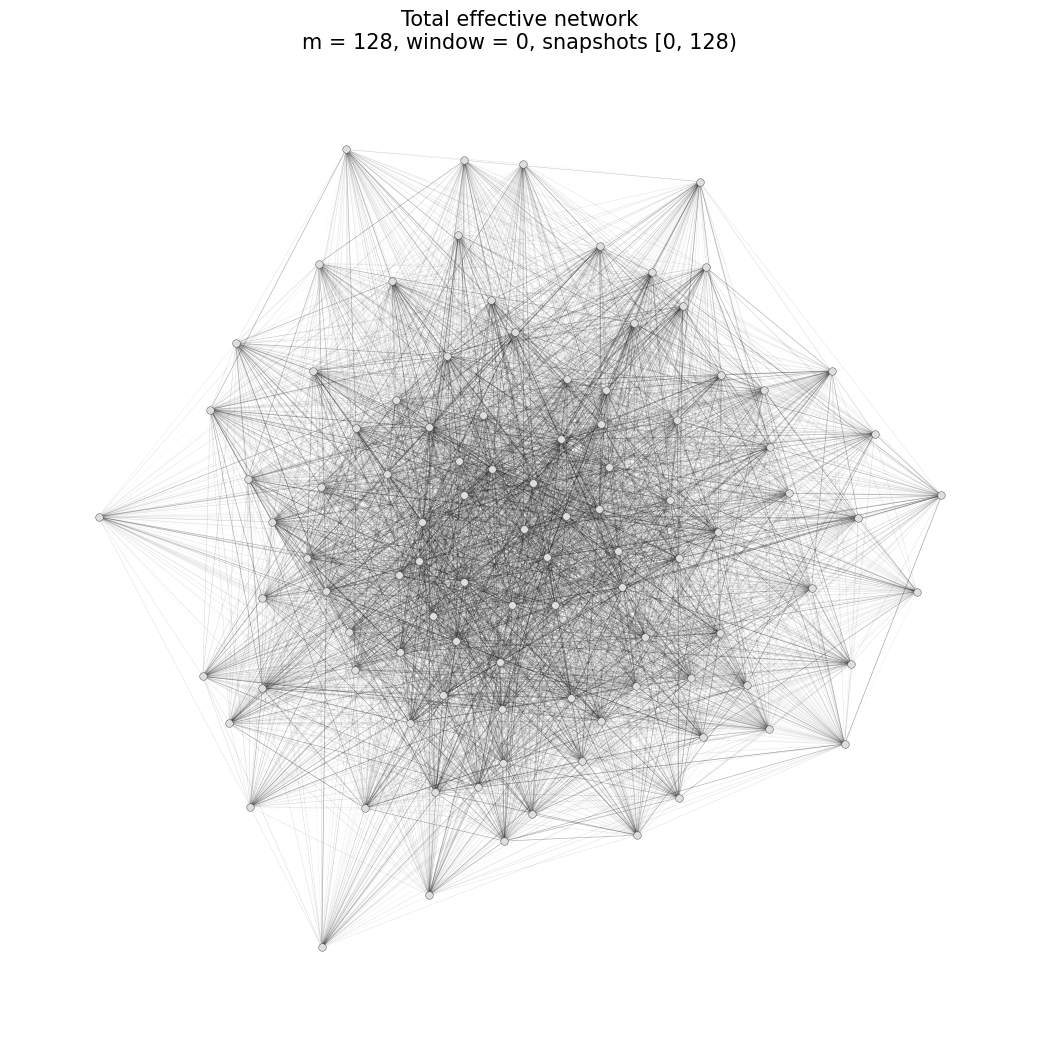

  [2/4] naive...
      saved: stage7_scaling_outputs\effective_w128_idx000_naive.png


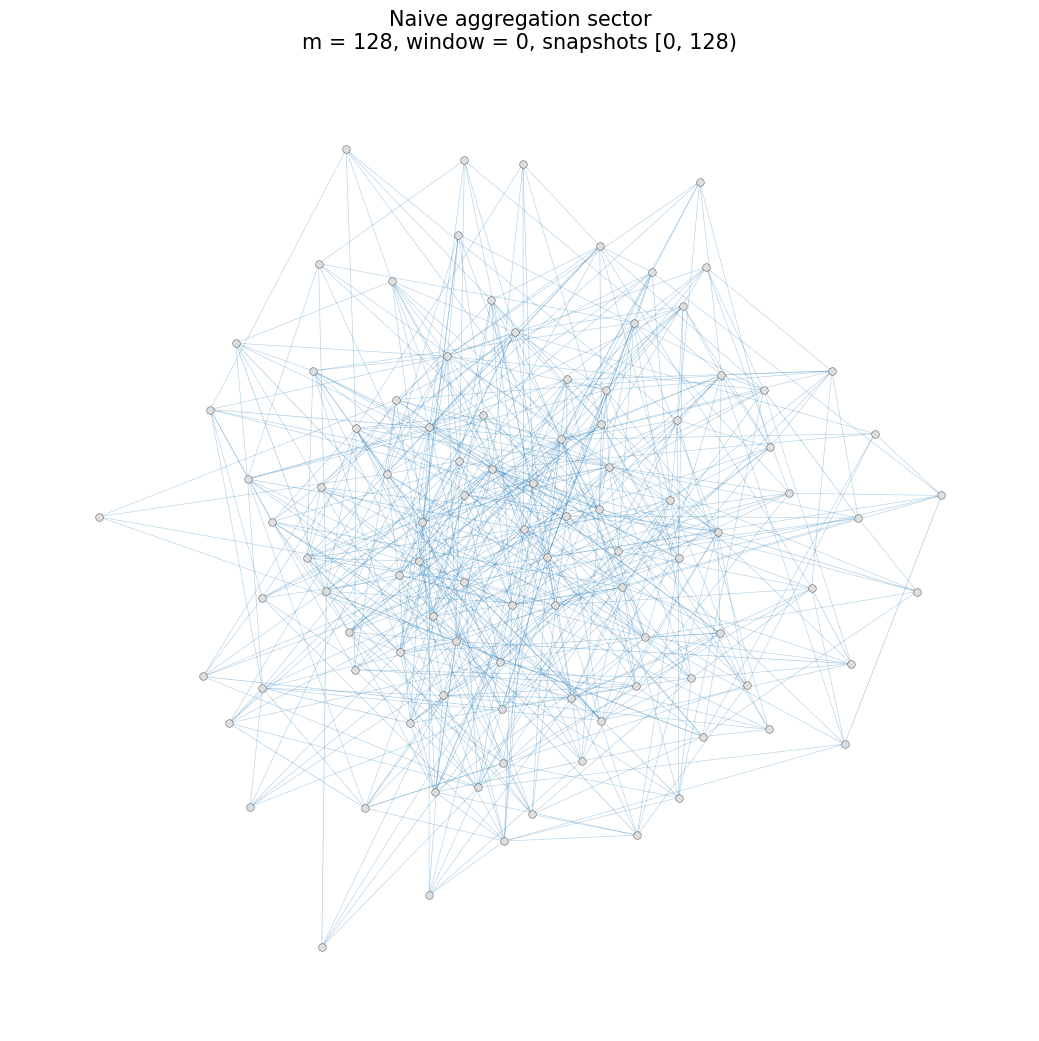

  [3/4] single commutator...
      saved: stage7_scaling_outputs\effective_w128_idx000_single_commutator.png


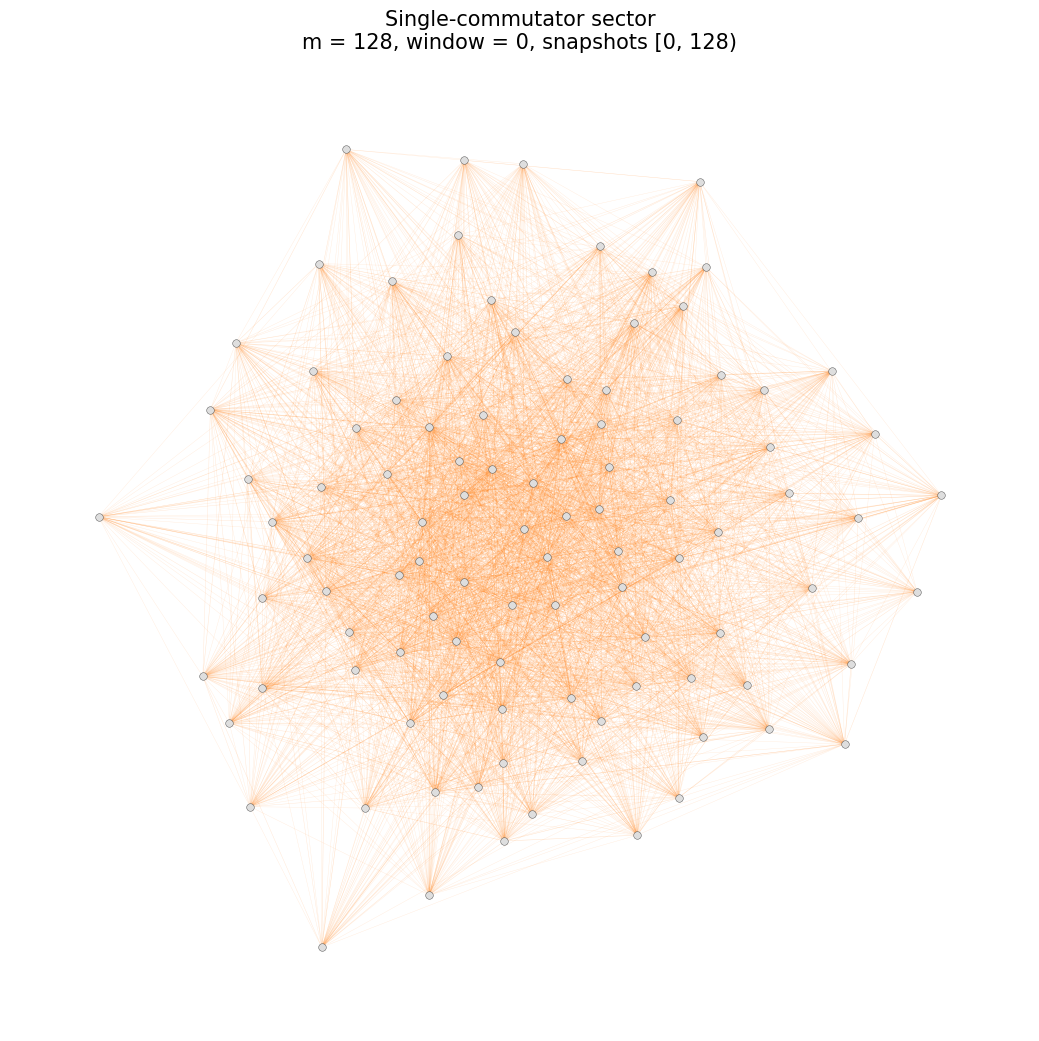

  [4/4] double commutator...
      saved: stage7_scaling_outputs\effective_w128_idx000_double_commutator.png


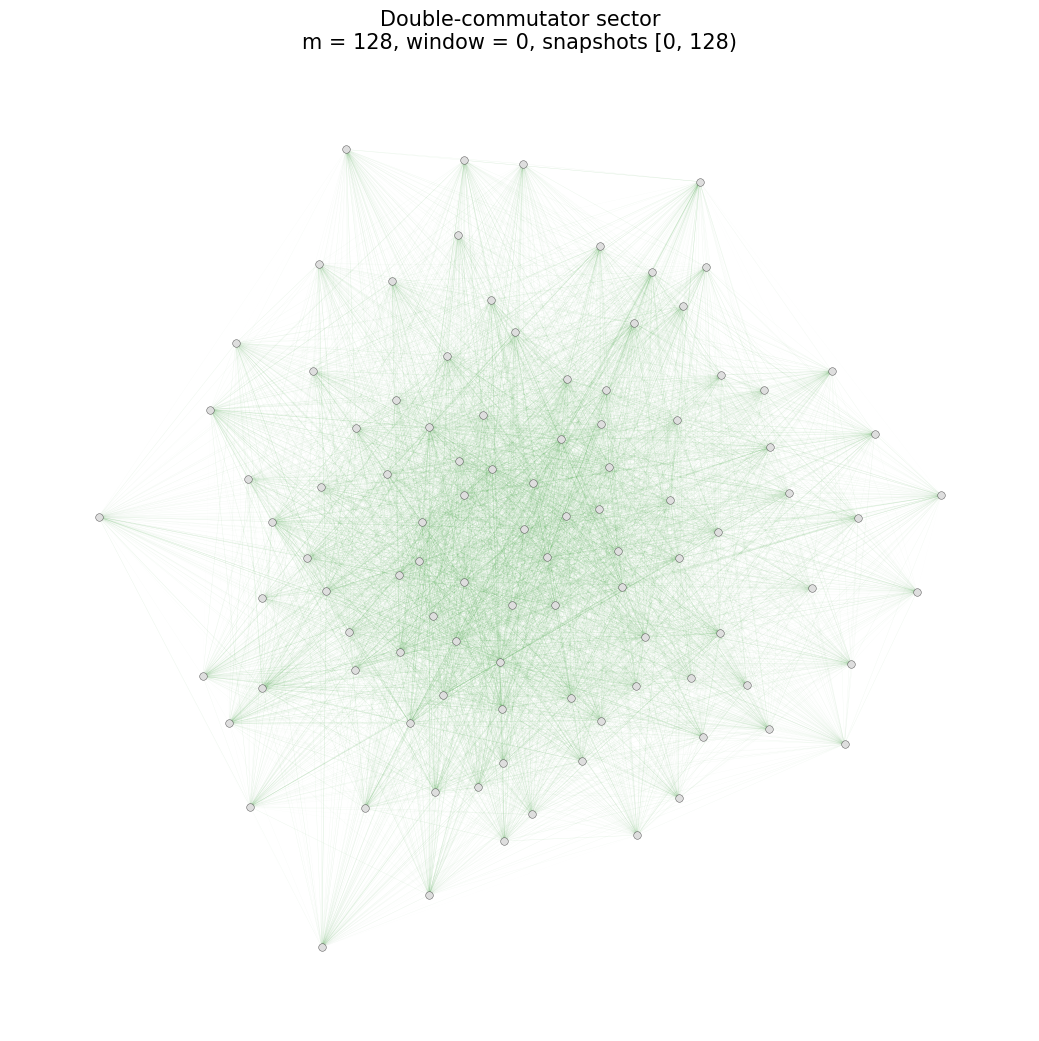

  done.


In [24]:
# ============================================================
# Cell 7.5b — Full-time effective network, m = 128
# ============================================================

summary_w128 = plot_effective_decomposition(
    result=effective_by_scale[128][0],
    window_size=128,
    window_idx=0,
    pos=pos,
    total_mode="black",
    show=True
)

m=2 effective-network ensemble
number of windows              = 64
windows with cross-time wedge = 29 / 64
windows with commutator       = 29 / 64
windows with nested sector    = 29 / 64

Cross-wedge -> commutator audit
-------------------------------
iff mismatches                 = 0

Microscopic motif vs commutator strength
----------------------------------------
cross wedges: Pearson r       = 0.971810
cross wedges: Spearman rho    = 0.997503
unique triads: Pearson r      = 0.971810
unique triads: Spearman rho   = 0.997503

m=2 ensemble summary


,mean,std,min,median,max
n_edges_t0,5.250000,2.861901,0.000000,5.000000,14.000000
n_edges_t1,5.000000,2.938524,0.000000,4.000000,16.000000
shared_nodes,0.734375,0.963495,0.000000,0.000000,4.000000
cross_wedges,1.250000,1.661898,0.000000,0.000000,6.000000
unique_cross_triads,1.250000,1.661898,0.000000,0.000000,6.000000
n_naive_pairs,10.218750,4.161306,2.000000,10.000000,20.000000
n_comm_pairs,3.078125,3.989290,0.000000,0.000000,16.000000
n_nested_pairs,5.953125,7.806041,0.000000,0.000000,31.000000
n_bch_pairs,14.359375,8.495316,2.000000,13.000000,41.000000
n_comm_generated,1.250000,1.661898,0.000000,0.000000,6.000000



m=2 ensemble mean vs m=128 global network


,sector,global_norm,local_ensemble_mean_norm,residual_norm,residual_over_global,local_to_global_norm_ratio,cosine_similarity
0,naive,1.145537,1.145537,1.691867e-16,1.476920e-16,1.000000,1.000000
1,single_commutator,0.058205,0.004800,5.817231e-02,9.994368e-01,0.082468,0.048061
2,double_commutator,0.010732,0.000197,1.070683e-02,9.976256e-01,0.018342,0.138471
3,BCH_total,1.149191,1.145565,5.914942e-02,5.147047e-02,0.996844,0.998676
4,exact_total,1.149210,1.145565,5.985922e-02,5.208728e-02,0.996828,0.998644



Naive aggregation identity
--------------------------
|| <K_avg^(2)> - K_avg^(128) || / ||K_avg^(128)||
= 1.476920e-16

Cross-block temporal contribution
---------------------------------
||global comm||             = 5.820509e-02
||within-m2 mean comm||     = 4.800080e-03
||cross-block comm||        = 5.817231e-02

||global nested||           = 1.073232e-02
||within-m2 mean nested||   = 1.968527e-04
||cross-block nested||      = 1.070683e-02

Saved figure: stage7_scaling_outputs\effective_w002_cross_wedges_vs_comm_norm.png


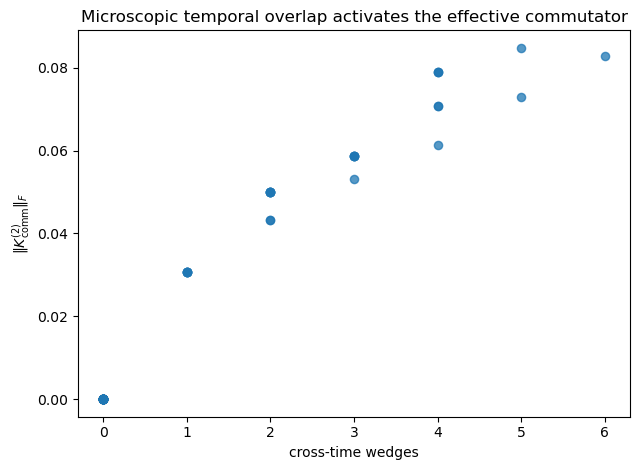

Saved figure: stage7_scaling_outputs\effective_w002_pair_counts_across_ensemble.png


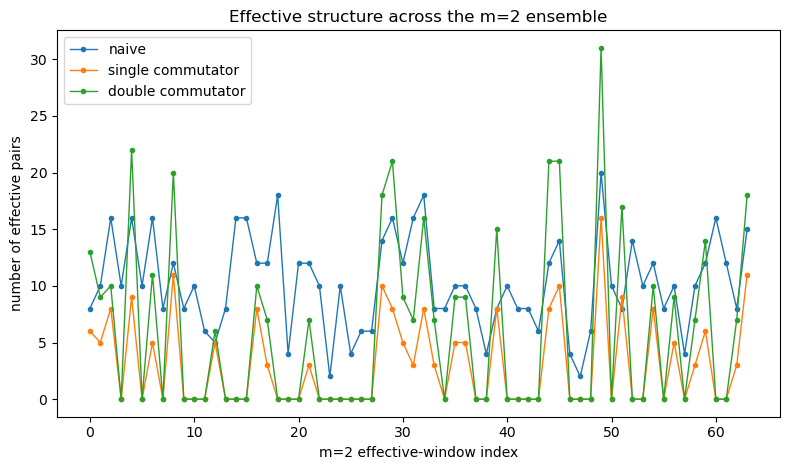


Saved all m=2 analysis outputs.


In [25]:
# ============================================================
# Cell 8 — Analysis of the m = 2 effective-network ensemble
# ============================================================
#
# There are 64 aligned effective windows:
#
#   [0,2), [2,4), ..., [126,128)
#
# For each window we analyze:
#
#   A. microscopic temporal structure
#      - edge counts
#      - shared edges
#      - shared nodes
#      - cross-time wedges
#      - unique cross-time triads
#
#   B. effective structure
#      - naive support
#      - commutator support
#      - nested support
#      - newly generated supports
#      - sector norms / relative strengths
#
#   C. relation to the m=128 global effective network
#
# A key identity for equal non-overlapping windows is:
#
#   mean_r K_avg^(2,r) = K_avg^(128)
#
# exactly (up to floating-point precision).
#
# But:
#
#   mean_r K_comm^(2,r) != K_comm^(128)
#
# because the global commutator also contains temporal
# compositions BETWEEN different m=2 blocks.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Setup
# ------------------------------------------------------------

M = 2

m2_results = effective_by_scale[M]

assert len(m2_results) == 64

global_result = effective_by_scale[128][0]


def dense_matrix(M):
    if sparse.issparse(M):
        return M.toarray()
    return np.asarray(M, dtype=float)


def fro(M):
    return float(
        np.linalg.norm(
            dense_matrix(M),
            ord="fro"
        )
    )


def pair_strength_all(M):
    """
    Strength for every unordered pair {i,j}.
    """
    M = dense_matrix(M)

    n = M.shape[0]

    iu = np.triu_indices(
        n,
        k=1
    )

    return np.sqrt(
        0.5 * (
            M[iu]**2
            + M.T[iu]**2
        )
    )


# ------------------------------------------------------------
# Microscopic cross-time motif helper
# ------------------------------------------------------------

def temporal_pair_structure(
    edges_a,
    edges_b
):
    """
    Structural relationship between two microscopic snapshots.

    cross_wedge:
        one edge from snapshot a and one edge from snapshot b
        sharing exactly one node.

    Example:
        (i,j)_a + (j,k)_b

    unique_cross_triads:
        number of distinct 3-node sets participating in at
        least one such cross-time wedge.
    """

    edges_a = set(edges_a)
    edges_b = set(edges_b)

    nodes_a = set()
    nodes_b = set()

    for u, v in edges_a:
        nodes_a.add(u)
        nodes_a.add(v)

    for u, v in edges_b:
        nodes_b.add(u)
        nodes_b.add(v)

    shared_edges = (
        edges_a & edges_b
    )

    shared_nodes = (
        nodes_a & nodes_b
    )

    cross_wedges = 0
    cross_triads = set()

    for e_a in edges_a:

        set_a = set(e_a)

        for e_b in edges_b:

            set_b = set(e_b)

            intersection = (
                set_a & set_b
            )

            # Exactly one common node:
            # genuine cross-time wedge.
            if len(intersection) == 1:

                cross_wedges += 1

                triad = frozenset(
                    set_a | set_b
                )

                if len(triad) == 3:
                    cross_triads.add(
                        triad
                    )

    return {
        "n_edges_t0":
            len(edges_a),

        "n_edges_t1":
            len(edges_b),

        "shared_edges":
            len(shared_edges),

        "shared_nodes":
            len(shared_nodes),

        "cross_wedges":
            cross_wedges,

        "unique_cross_triads":
            len(cross_triads),
    }


# ============================================================
# A. Window-by-window m=2 analysis
# ============================================================

m2_rows = []

for r, result in enumerate(
    m2_results
):

    start = int(
        result["start"]
    )

    end = int(
        result["end"]
    )

    assert end - start == 2

    # --------------------------------------------------------
    # Microscopic structural relationship
    # --------------------------------------------------------

    micro = temporal_pair_structure(
        edge_sets[start],
        edge_sets[start + 1]
    )

    # --------------------------------------------------------
    # BCH sectors
    # --------------------------------------------------------

    K_avg = dense_matrix(
        result["K_avg"]
    )

    K_comm = dense_matrix(
        result["K_comm"]
    )

    K_nested = dense_matrix(
        result["K_nested"]
    )

    K_bch = (
        K_avg
        + K_comm
        + K_nested
    )

    s_avg = pair_strength_all(
        K_avg
    )

    s_comm = pair_strength_all(
        K_comm
    )

    s_nested = pair_strength_all(
        K_nested
    )

    s_bch = pair_strength_all(
        K_bch
    )

    mask_avg = (
        s_avg > PLOT_EDGE_TOL
    )

    mask_comm = (
        s_comm > PLOT_EDGE_TOL
    )

    mask_nested = (
        s_nested > PLOT_EDGE_TOL
    )

    mask_bch = (
        s_bch > PLOT_EDGE_TOL
    )

    # Exclusive new effective pairs
    mask_comm_generated = (
        (~mask_avg)
        & mask_comm
    )

    mask_nested_generated = (
        (~mask_avg)
        & (~mask_comm)
        & mask_nested
    )

    norm_avg = fro(
        K_avg
    )

    norm_comm = fro(
        K_comm
    )

    norm_nested = fro(
        K_nested
    )

    norm_bch = fro(
        K_bch
    )

    comm_active = (
        norm_comm > PLOT_EDGE_TOL
    )

    nested_active = (
        norm_nested > PLOT_EDGE_TOL
    )

    row = {
        "window_idx": r,

        "start": start,
        "end": end,

        "physical_start":
            start * TAU_SNAPSHOT,

        "physical_end":
            end * TAU_SNAPSHOT,

        **micro,

        # Structural activity
        "cross_wedge_active":
            micro["cross_wedges"] > 0,

        "comm_active":
            comm_active,

        "nested_active":
            nested_active,

        # Pair supports
        "n_naive_pairs":
            int(mask_avg.sum()),

        "n_comm_pairs":
            int(mask_comm.sum()),

        "n_nested_pairs":
            int(mask_nested.sum()),

        "n_bch_pairs":
            int(mask_bch.sum()),

        "n_comm_generated":
            int(
                mask_comm_generated.sum()
            ),

        "n_nested_generated":
            int(
                mask_nested_generated.sum()
            ),

        # Norms
        "norm_avg":
            norm_avg,

        "norm_comm":
            norm_comm,

        "norm_nested":
            norm_nested,

        "norm_bch":
            norm_bch,

        # Relative sector strengths
        "ratio_comm_to_avg":
            (
                norm_comm / norm_avg
                if norm_avg > 0
                else 0.0
            ),

        "ratio_nested_to_avg":
            (
                norm_nested / norm_avg
                if norm_avg > 0
                else 0.0
            ),

        "ratio_nested_to_comm":
            (
                norm_nested / norm_comm
                if norm_comm > 0
                else 0.0
            ),

        # Typical weights
        "median_naive_strength":
            (
                float(
                    np.median(
                        s_avg[mask_avg]
                    )
                )
                if mask_avg.any()
                else 0.0
            ),

        "median_comm_strength":
            (
                float(
                    np.median(
                        s_comm[mask_comm]
                    )
                )
                if mask_comm.any()
                else 0.0
            ),

        "median_nested_strength":
            (
                float(
                    np.median(
                        s_nested[
                            mask_nested
                        ]
                    )
                )
                if mask_nested.any()
                else 0.0
            ),
    }


    # --------------------------------------------------------
    # Exact-BCH error for this local window, if available
    # --------------------------------------------------------

    if "K_exact" in result:

        K_exact = dense_matrix(
            result["K_exact"]
        )

        norm_exact = fro(
            K_exact
        )

        row[
            "exact_bch_relative_error"
        ] = (
            fro(
                K_bch
                - K_exact
            )
            / norm_exact
            if norm_exact > 0
            else 0.0
        )


    m2_rows.append(
        row
    )


m2_df = pd.DataFrame(
    m2_rows
)


# ============================================================
# B. Basic ensemble diagnostics
# ============================================================

print(
    "m=2 effective-network ensemble"
)
print(
    "=============================="
)

print(
    f"number of windows              = "
    f"{len(m2_df)}"
)

print(
    f"windows with cross-time wedge = "
    f"{m2_df['cross_wedge_active'].sum()} "
    f"/ {len(m2_df)}"
)

print(
    f"windows with commutator       = "
    f"{m2_df['comm_active'].sum()} "
    f"/ {len(m2_df)}"
)

print(
    f"windows with nested sector    = "
    f"{m2_df['nested_active'].sum()} "
    f"/ {len(m2_df)}"
)


# ------------------------------------------------------------
# Structural trigger audit
# ------------------------------------------------------------

comm_trigger_mismatch = (
    m2_df[
        "cross_wedge_active"
    ]
    !=
    m2_df[
        "comm_active"
    ]
)

print()
print(
    "Cross-wedge -> commutator audit"
)
print(
    "-------------------------------"
)

print(
    f"iff mismatches                 = "
    f"{comm_trigger_mismatch.sum()}"
)

if comm_trigger_mismatch.any():

    display(
        m2_df.loc[
            comm_trigger_mismatch,
            [
                "window_idx",
                "start",
                "end",
                "shared_nodes",
                "cross_wedges",
                "unique_cross_triads",
                "norm_comm",
                "n_comm_pairs",
            ]
        ]
    )


# ------------------------------------------------------------
# Correlation between microscopic motifs and effective strength
# ------------------------------------------------------------

pearson_cross_comm = (
    m2_df[
        "cross_wedges"
    ].corr(
        m2_df[
            "norm_comm"
        ],
        method="pearson"
    )
)

spearman_cross_comm = (
    m2_df[
        "cross_wedges"
    ].corr(
        m2_df[
            "norm_comm"
        ],
        method="spearman"
    )
)

pearson_triads_comm = (
    m2_df[
        "unique_cross_triads"
    ].corr(
        m2_df[
            "norm_comm"
        ],
        method="pearson"
    )
)

spearman_triads_comm = (
    m2_df[
        "unique_cross_triads"
    ].corr(
        m2_df[
            "norm_comm"
        ],
        method="spearman"
    )
)


print()
print(
    "Microscopic motif vs commutator strength"
)
print(
    "----------------------------------------"
)

print(
    f"cross wedges: Pearson r       = "
    f"{pearson_cross_comm:.6f}"
)

print(
    f"cross wedges: Spearman rho    = "
    f"{spearman_cross_comm:.6f}"
)

print(
    f"unique triads: Pearson r      = "
    f"{pearson_triads_comm:.6f}"
)

print(
    f"unique triads: Spearman rho   = "
    f"{spearman_triads_comm:.6f}"
)


# ============================================================
# C. Ensemble summary
# ============================================================

summary_columns = [
    "n_edges_t0",
    "n_edges_t1",
    "shared_nodes",
    "cross_wedges",
    "unique_cross_triads",

    "n_naive_pairs",
    "n_comm_pairs",
    "n_nested_pairs",
    "n_bch_pairs",

    "n_comm_generated",
    "n_nested_generated",

    "norm_avg",
    "norm_comm",
    "norm_nested",

    "ratio_comm_to_avg",
    "ratio_nested_to_avg",
    "ratio_nested_to_comm",

    "median_naive_strength",
    "median_comm_strength",
    "median_nested_strength",
]


m2_ensemble_summary = (
    m2_df[
        summary_columns
    ]
    .agg([
        "mean",
        "std",
        "min",
        "median",
        "max"
    ])
    .T
)


print()
print(
    "m=2 ensemble summary"
)
print(
    "===================="
)

display(
    m2_ensemble_summary
)


# ============================================================
# D. Local ensemble mean vs global m=128 network
# ============================================================

def mean_sector(
    results,
    key
):

    return np.mean(
        np.stack([
            dense_matrix(
                r[key]
            )
            for r in results
        ]),
        axis=0
    )


# Local m=2 ensemble means

K2_mean_avg = mean_sector(
    m2_results,
    "K_avg"
)

K2_mean_comm = mean_sector(
    m2_results,
    "K_comm"
)

K2_mean_nested = mean_sector(
    m2_results,
    "K_nested"
)

K2_mean_bch = (
    K2_mean_avg
    + K2_mean_comm
    + K2_mean_nested
)


# Global m=128 sectors

K128_avg = dense_matrix(
    global_result["K_avg"]
)

K128_comm = dense_matrix(
    global_result["K_comm"]
)

K128_nested = dense_matrix(
    global_result["K_nested"]
)

K128_bch = (
    K128_avg
    + K128_comm
    + K128_nested
)


def matrix_cosine(
    A,
    B
):

    a = A.ravel()
    b = B.ravel()

    na = np.linalg.norm(a)
    nb = np.linalg.norm(b)

    if na == 0 or nb == 0:
        return np.nan

    return float(
        np.dot(a, b)
        /
        (na * nb)
    )


comparison_rows = []

for (
    sector,
    local_mean,
    global_matrix
) in [

    (
        "naive",
        K2_mean_avg,
        K128_avg
    ),

    (
        "single_commutator",
        K2_mean_comm,
        K128_comm
    ),

    (
        "double_commutator",
        K2_mean_nested,
        K128_nested
    ),

    (
        "BCH_total",
        K2_mean_bch,
        K128_bch
    ),
]:

    residual = (
        global_matrix
        - local_mean
    )

    global_norm = fro(
        global_matrix
    )

    local_norm = fro(
        local_mean
    )

    residual_norm = fro(
        residual
    )

    comparison_rows.append({
        "sector":
            sector,

        "global_norm":
            global_norm,

        "local_ensemble_mean_norm":
            local_norm,

        "residual_norm":
            residual_norm,

        "residual_over_global":
            (
                residual_norm
                / global_norm
                if global_norm > 0
                else np.nan
            ),

        "local_to_global_norm_ratio":
            (
                local_norm
                / global_norm
                if global_norm > 0
                else np.nan
            ),

        "cosine_similarity":
            matrix_cosine(
                local_mean,
                global_matrix
            ),
    })


# ------------------------------------------------------------
# Exact effective generators as an additional comparison
# ------------------------------------------------------------

if (
    all(
        "K_exact" in r
        for r in m2_results
    )
    and
    "K_exact" in global_result
):

    K2_mean_exact = np.mean(
        np.stack([
            dense_matrix(
                r["K_exact"]
            )
            for r in m2_results
        ]),
        axis=0
    )

    K128_exact = dense_matrix(
        global_result["K_exact"]
    )

    residual_exact = (
        K128_exact
        - K2_mean_exact
    )

    comparison_rows.append({
        "sector":
            "exact_total",

        "global_norm":
            fro(
                K128_exact
            ),

        "local_ensemble_mean_norm":
            fro(
                K2_mean_exact
            ),

        "residual_norm":
            fro(
                residual_exact
            ),

        "residual_over_global":
            (
                fro(
                    residual_exact
                )
                /
                fro(
                    K128_exact
                )
            ),

        "local_to_global_norm_ratio":
            (
                fro(
                    K2_mean_exact
                )
                /
                fro(
                    K128_exact
                )
            ),

        "cosine_similarity":
            matrix_cosine(
                K2_mean_exact,
                K128_exact
            ),
    })


m2_vs_global_df = pd.DataFrame(
    comparison_rows
)


print()
print(
    "m=2 ensemble mean vs m=128 global network"
)
print(
    "=========================================="
)

display(
    m2_vs_global_df
)


# ------------------------------------------------------------
# Exact naive identity audit
# ------------------------------------------------------------

naive_identity_error = (
    fro(
        K2_mean_avg
        - K128_avg
    )
    /
    fro(
        K128_avg
    )
)

print()
print(
    "Naive aggregation identity"
)
print(
    "--------------------------"
)

print(
    "|| <K_avg^(2)> - K_avg^(128) || "
    "/ ||K_avg^(128)||"
)

print(
    f"= {naive_identity_error:.6e}"
)


# ------------------------------------------------------------
# Cross-block temporal contribution
# ------------------------------------------------------------

K_cross_comm = (
    K128_comm
    - K2_mean_comm
)

K_cross_nested = (
    K128_nested
    - K2_mean_nested
)

K_cross_total = (
    K128_bch
    - K2_mean_bch
)


print()
print(
    "Cross-block temporal contribution"
)
print(
    "---------------------------------"
)

print(
    f"||global comm||             = "
    f"{fro(K128_comm):.6e}"
)

print(
    f"||within-m2 mean comm||     = "
    f"{fro(K2_mean_comm):.6e}"
)

print(
    f"||cross-block comm||        = "
    f"{fro(K_cross_comm):.6e}"
)

print()

print(
    f"||global nested||           = "
    f"{fro(K128_nested):.6e}"
)

print(
    f"||within-m2 mean nested||   = "
    f"{fro(K2_mean_nested):.6e}"
)

print(
    f"||cross-block nested||      = "
    f"{fro(K_cross_nested):.6e}"
)


# ============================================================
# E. Two compact diagnostic figures
# ============================================================

# ------------------------------------------------------------
# Figure 1:
# microscopic cross-time wedges vs effective commutator strength
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(6.5, 4.8)
)

ax.scatter(
    m2_df["cross_wedges"],
    m2_df["norm_comm"],
    s=35,
    alpha=0.75
)

ax.set_xlabel(
    "cross-time wedges"
)

ax.set_ylabel(
    r"$\|K_{\rm comm}^{(2)}\|_F$"
)

ax.set_title(
    "Microscopic temporal overlap activates "
    "the effective commutator"
)

plt.tight_layout()

path = (
    OUTDIR
    /
    "effective_w002_cross_wedges_vs_comm_norm.png"
)

fig.savefig(
    path,
    dpi=250,
    bbox_inches="tight"
)

print(
    f"\nSaved figure: {path}"
)

plt.show()


# ------------------------------------------------------------
# Figure 2:
# effective pair counts over the m=2 ensemble
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(8.0, 4.8)
)

ax.plot(
    m2_df["window_idx"],
    m2_df["n_naive_pairs"],
    marker="o",
    markersize=3,
    linewidth=1,
    label="naive"
)

ax.plot(
    m2_df["window_idx"],
    m2_df["n_comm_pairs"],
    marker="o",
    markersize=3,
    linewidth=1,
    label="single commutator"
)

ax.plot(
    m2_df["window_idx"],
    m2_df["n_nested_pairs"],
    marker="o",
    markersize=3,
    linewidth=1,
    label="double commutator"
)

ax.set_xlabel(
    "m=2 effective-window index"
)

ax.set_ylabel(
    "number of effective pairs"
)

ax.set_title(
    "Effective structure across the m=2 ensemble"
)

ax.legend()

plt.tight_layout()

path = (
    OUTDIR
    /
    "effective_w002_pair_counts_across_ensemble.png"
)

fig.savefig(
    path,
    dpi=250,
    bbox_inches="tight"
)

print(
    f"Saved figure: {path}"
)

plt.show()


# ============================================================
# F. Save
# ============================================================

m2_df.to_csv(
    OUTDIR
    /
    "effective_w002_window_analysis.csv",
    index=False
)

m2_ensemble_summary.to_csv(
    OUTDIR
    /
    "effective_w002_ensemble_summary.csv"
)

m2_vs_global_df.to_csv(
    OUTDIR
    /
    "effective_w002_vs_global_w128.csv",
    index=False
)

np.savez_compressed(
    OUTDIR
    /
    "effective_w002_cross_block_decomposition.npz",

    K2_mean_avg=K2_mean_avg,
    K2_mean_comm=K2_mean_comm,
    K2_mean_nested=K2_mean_nested,
    K2_mean_bch=K2_mean_bch,

    K128_avg=K128_avg,
    K128_comm=K128_comm,
    K128_nested=K128_nested,
    K128_bch=K128_bch,

    K_cross_comm=K_cross_comm,
    K_cross_nested=K_cross_nested,
    K_cross_total=K_cross_total,
)

print()
print(
    "Saved all m=2 analysis outputs."
)

Analyzing 4950 unordered node pairs across 64 m=2 windows.

Single-commutator: m=2 pair statistics vs m=128 global structure


,predictor,target,pearson_r,spearman_rho
0,local_occupancy,global_abs,0.265904,0.177379
1,local_mean_abs,global_abs,0.280139,0.177927
2,local_rms,global_abs,0.275771,0.177932
3,local_std,global_abs,0.275958,0.177639
4,local_max_abs,global_abs,0.270906,0.177873
5,local_signed_mean,global_signed,0.048064,0.046193



Double-commutator: m=2 pair statistics vs m=128 global structure


,predictor,target,pearson_r,spearman_rho
0,local_occupancy,global_abs,0.189746,0.118365
1,local_mean_abs,global_abs,0.179179,0.118914
2,local_rms,global_abs,0.168847,0.118900
3,local_std,global_abs,0.168781,0.119118
4,local_max_abs,global_abs,0.161422,0.118832
5,local_signed_mean,global_signed,0.113570,0.068466



Local m=2 support vs global m=128 support


...


Single-commutator occupancy classes


,local_active_count,n_pairs,mean_global_abs,median_global_abs,q90_global_abs,fraction_global_active,local_occupancy
0,0,4759,0.000287,0.000195,0.000586,0.670519,0.000000
1,1,185,0.000930,0.000586,0.002344,0.908108,0.015625
2,2,6,0.001725,0.000781,0.004102,1.000000,0.031250



Double-commutator occupancy classes


,local_active_count,n_pairs,mean_global_abs,median_global_abs,q90_global_abs,fraction_global_active,local_occupancy
0,0,4584,0.000052,0.000033,0.000114,0.982330,0.000000
1,1,351,0.000104,0.000050,0.000262,0.991453,0.015625
2,2,15,0.000234,0.000142,0.000617,1.000000,0.031250


Saved figure: stage7_scaling_outputs\effective_w002_pair_rms_vs_global_comm.png


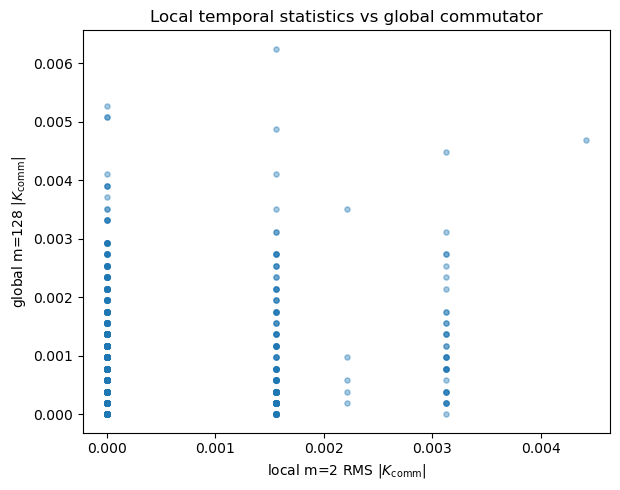

Saved figure: stage7_scaling_outputs\effective_w002_pair_rms_vs_global_nested.png


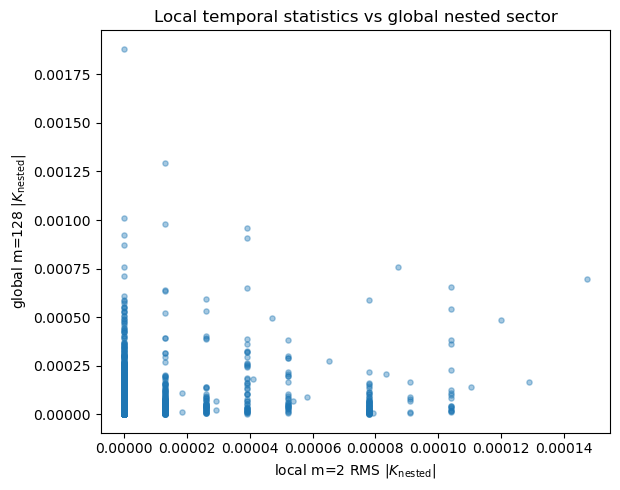

Saved figure: stage7_scaling_outputs\effective_w002_occupancy_vs_global_comm.png


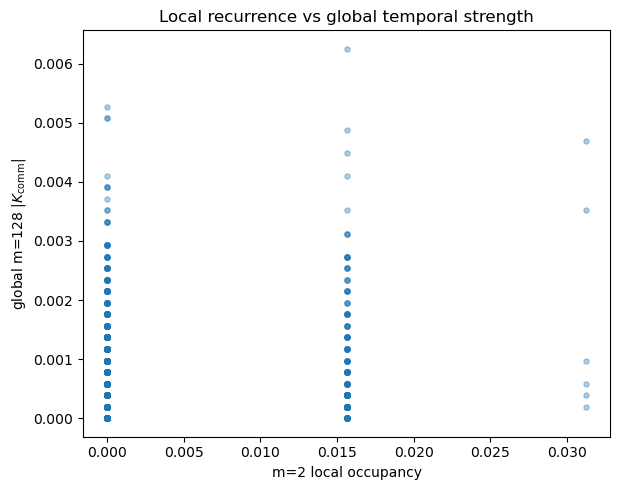


Saved all m=2 pair-level temporal statistics.


In [26]:
# ============================================================
# Cell 9 — Pair-level temporal ensemble statistics at m = 2
# ============================================================
#
# We deliberately EXCLUDE the naive aggregation sector.
#
# For every unordered node pair {i,j}, we ask whether the
# statistics of its LOCAL m=2 temporal corrections predict
# its GLOBAL m=128 temporal correction.
#
# Sectors:
#
#   K_comm
#   K_nested
#
# For every pair we compute across the 64 m=2 windows:
#
#   occupancy
#   signed mean
#   mean absolute strength
#   RMS strength
#   standard deviation
#   maximum absolute strength
#
# Targets:
#
#   K_comm^(128)
#   K_nested^(128)
#
# This tests statistical predictability across observation
# scales, rather than trivial linear additivity.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Setup
# ------------------------------------------------------------

M = 2

m2_results = effective_by_scale[M]
global_result = effective_by_scale[128][0]

N_M2 = len(m2_results)

assert N_M2 == 64


def dense(M):
    if sparse.issparse(M):
        return M.toarray()
    return np.asarray(M, dtype=float)


# ------------------------------------------------------------
# Common unordered pair indexing
# ------------------------------------------------------------

n_nodes = dense(
    m2_results[0]["K_comm"]
).shape[0]

iu = np.triu_indices(
    n_nodes,
    k=1
)

pair_i = iu[0]
pair_j = iu[1]

N_PAIRS = len(pair_i)

print(
    f"Analyzing {N_PAIRS} unordered node pairs "
    f"across {N_M2} m=2 windows."
)


# ------------------------------------------------------------
# Extract one oriented coefficient per unordered pair
# ------------------------------------------------------------
#
# We consistently use matrix element K_ij for i < j.
#
# For K_comm:
#     K_ji = -K_ij
#
# so this retains the antisymmetric sign/orientation.
#
# For K_nested:
#     K_ji = K_ij
#
# so the same convention works naturally.
# ------------------------------------------------------------

def upper_pair_vector(M):

    M = dense(M)

    return M[
        pair_i,
        pair_j
    ]


# ------------------------------------------------------------
# Stack local m=2 temporal sectors
# ------------------------------------------------------------

comm_local = np.stack([
    upper_pair_vector(
        result["K_comm"]
    )
    for result in m2_results
])

nested_local = np.stack([
    upper_pair_vector(
        result["K_nested"]
    )
    for result in m2_results
])

# shape:
#   (64, 4950)

assert comm_local.shape == (
    N_M2,
    N_PAIRS
)

assert nested_local.shape == (
    N_M2,
    N_PAIRS
)


# ------------------------------------------------------------
# Global targets
# ------------------------------------------------------------

comm_global = upper_pair_vector(
    global_result["K_comm"]
)

nested_global = upper_pair_vector(
    global_result["K_nested"]
)


# ------------------------------------------------------------
# Ensemble-feature builder
# ------------------------------------------------------------

def build_pair_features(
    local_values,
    global_values,
    sector_name,
    tol=PLOT_EDGE_TOL
):
    """
    local_values:
        shape (n_windows, n_pairs)

    global_values:
        shape (n_pairs,)
    """

    abs_local = np.abs(
        local_values
    )

    active = (
        abs_local > tol
    )

    occupancy = np.mean(
        active,
        axis=0
    )

    signed_mean = np.mean(
        local_values,
        axis=0
    )

    mean_abs = np.mean(
        abs_local,
        axis=0
    )

    rms = np.sqrt(
        np.mean(
            local_values**2,
            axis=0
        )
    )

    std = np.std(
        local_values,
        axis=0,
        ddof=1
    )

    max_abs = np.max(
        abs_local,
        axis=0
    )

    count_active = np.sum(
        active,
        axis=0
    )

    global_abs = np.abs(
        global_values
    )

    global_active = (
        global_abs > tol
    )

    df = pd.DataFrame({
        "sector":
            sector_name,

        "i":
            pair_i,

        "j":
            pair_j,

        "local_active_count":
            count_active,

        "local_occupancy":
            occupancy,

        "local_signed_mean":
            signed_mean,

        "local_mean_abs":
            mean_abs,

        "local_rms":
            rms,

        "local_std":
            std,

        "local_max_abs":
            max_abs,

        "global_signed":
            global_values,

        "global_abs":
            global_abs,

        "global_active":
            global_active,
    })

    return df


comm_pair_df = build_pair_features(
    local_values=comm_local,
    global_values=comm_global,
    sector_name="single_commutator"
)

nested_pair_df = build_pair_features(
    local_values=nested_local,
    global_values=nested_global,
    sector_name="double_commutator"
)


# ============================================================
# Correlation analysis
# ============================================================

def correlation_table(
    df
):
    """
    For magnitude predictors:
        compare to |global coefficient|.

    For signed mean:
        compare to signed global coefficient.
    """

    rows = []

    magnitude_predictors = [
        "local_occupancy",
        "local_mean_abs",
        "local_rms",
        "local_std",
        "local_max_abs",
    ]

    for predictor in magnitude_predictors:

        pearson = df[
            predictor
        ].corr(
            df["global_abs"],
            method="pearson"
        )

        spearman = df[
            predictor
        ].corr(
            df["global_abs"],
            method="spearman"
        )

        rows.append({
            "predictor":
                predictor,

            "target":
                "global_abs",

            "pearson_r":
                pearson,

            "spearman_rho":
                spearman,
        })


    # Signed relation
    rows.append({
        "predictor":
            "local_signed_mean",

        "target":
            "global_signed",

        "pearson_r":
            df[
                "local_signed_mean"
            ].corr(
                df["global_signed"],
                method="pearson"
            ),

        "spearman_rho":
            df[
                "local_signed_mean"
            ].corr(
                df["global_signed"],
                method="spearman"
            ),
    })


    return pd.DataFrame(
        rows
    )


comm_corr_df = (
    correlation_table(
        comm_pair_df
    )
)

nested_corr_df = (
    correlation_table(
        nested_pair_df
    )
)


print()
print(
    "Single-commutator: m=2 pair statistics "
    "vs m=128 global structure"
)
print(
    "======================================================"
)

display(
    comm_corr_df
)


print()
print(
    "Double-commutator: m=2 pair statistics "
    "vs m=128 global structure"
)
print(
    "======================================================"
)

display(
    nested_corr_df
)


# ============================================================
# Structural coverage
# ============================================================

def structural_summary(
    df,
    sector_name
):

    local_ever = (
        df["local_active_count"]
        > 0
    )

    global_active = (
        df["global_active"]
    )

    both = (
        local_ever
        & global_active
    )

    local_only = (
        local_ever
        & (~global_active)
    )

    global_only = (
        (~local_ever)
        & global_active
    )

    neither = (
        (~local_ever)
        & (~global_active)
    )

    return {
        "sector":
            sector_name,

        "pairs_seen_locally":
            int(local_ever.sum()),

        "pairs_active_globally":
            int(global_active.sum()),

        "local_and_global":
            int(both.sum()),

        "local_only":
            int(local_only.sum()),

        "global_only":
            int(global_only.sum()),

        "neither":
            int(neither.sum()),

        "fraction_global_seen_locally":
            (
                float(
                    both.sum()
                    / global_active.sum()
                )
                if global_active.sum() > 0
                else np.nan
            ),
    }


temporal_structure_df = pd.DataFrame([
    structural_summary(
        comm_pair_df,
        "single_commutator"
    ),

    structural_summary(
        nested_pair_df,
        "double_commutator"
    )
])


print()
print(
    "Local m=2 support vs global m=128 support"
)
print(
    "========================================"
)

display(
    temporal_structure_df
)


# ============================================================
# Conditional global strength by local occupancy
# ============================================================
#
# Since m=2 occupancy is quantized:
#
#     0/64, 1/64, 2/64, ...
#
# we can ask whether pairs that recur more frequently in the
# local ensemble become stronger globally.
# ============================================================

def occupancy_strength_table(
    df
):

    out = (
        df
        .groupby(
            "local_active_count"
        )
        .agg(
            n_pairs=(
                "global_abs",
                "size"
            ),

            mean_global_abs=(
                "global_abs",
                "mean"
            ),

            median_global_abs=(
                "global_abs",
                "median"
            ),

            q90_global_abs=(
                "global_abs",
                lambda x:
                    np.quantile(
                        x,
                        0.90
                    )
            ),

            fraction_global_active=(
                "global_active",
                "mean"
            ),
        )
        .reset_index()
    )

    out[
        "local_occupancy"
    ] = (
        out[
            "local_active_count"
        ]
        / N_M2
    )

    return out


comm_occupancy_df = (
    occupancy_strength_table(
        comm_pair_df
    )
)

nested_occupancy_df = (
    occupancy_strength_table(
        nested_pair_df
    )
)


print()
print(
    "Single-commutator occupancy classes"
)
print(
    "==================================="
)

display(
    comm_occupancy_df
)


print()
print(
    "Double-commutator occupancy classes"
)
print(
    "==================================="
)

display(
    nested_occupancy_df
)


# ============================================================
# Figures
# ============================================================

# ------------------------------------------------------------
# Figure 1 — local RMS vs global commutator strength
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(6.3, 5.0)
)

ax.scatter(
    comm_pair_df[
        "local_rms"
    ],
    comm_pair_df[
        "global_abs"
    ],
    s=14,
    alpha=0.40
)

ax.set_xlabel(
    r"local m=2 RMS $|K_{\rm comm}|$"
)

ax.set_ylabel(
    r"global m=128 $|K_{\rm comm}|$"
)

ax.set_title(
    "Local temporal statistics vs global commutator"
)

plt.tight_layout()

path = (
    OUTDIR
    /
    "effective_w002_pair_rms_vs_global_comm.png"
)

fig.savefig(
    path,
    dpi=250,
    bbox_inches="tight"
)

print(
    f"Saved figure: {path}"
)

plt.show()


# ------------------------------------------------------------
# Figure 2 — local RMS vs global nested strength
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(6.3, 5.0)
)

ax.scatter(
    nested_pair_df[
        "local_rms"
    ],
    nested_pair_df[
        "global_abs"
    ],
    s=14,
    alpha=0.40
)

ax.set_xlabel(
    r"local m=2 RMS $|K_{\rm nested}|$"
)

ax.set_ylabel(
    r"global m=128 $|K_{\rm nested}|$"
)

ax.set_title(
    "Local temporal statistics vs global nested sector"
)

plt.tight_layout()

path = (
    OUTDIR
    /
    "effective_w002_pair_rms_vs_global_nested.png"
)

fig.savefig(
    path,
    dpi=250,
    bbox_inches="tight"
)

print(
    f"Saved figure: {path}"
)

plt.show()


# ------------------------------------------------------------
# Figure 3 — occupancy vs global commutator strength
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(6.3, 5.0)
)

ax.scatter(
    comm_pair_df[
        "local_occupancy"
    ],
    comm_pair_df[
        "global_abs"
    ],
    s=14,
    alpha=0.35
)

ax.set_xlabel(
    "m=2 local occupancy"
)

ax.set_ylabel(
    r"global m=128 $|K_{\rm comm}|$"
)

ax.set_title(
    "Local recurrence vs global temporal strength"
)

plt.tight_layout()

path = (
    OUTDIR
    /
    "effective_w002_occupancy_vs_global_comm.png"
)

fig.savefig(
    path,
    dpi=250,
    bbox_inches="tight"
)

print(
    f"Saved figure: {path}"
)

plt.show()


# ============================================================
# Save outputs
# ============================================================

comm_pair_df.to_csv(
    OUTDIR
    /
    "effective_w002_pair_statistics_comm.csv",
    index=False
)

nested_pair_df.to_csv(
    OUTDIR
    /
    "effective_w002_pair_statistics_nested.csv",
    index=False
)

comm_corr_df.to_csv(
    OUTDIR
    /
    "effective_w002_pair_correlations_comm.csv",
    index=False
)

nested_corr_df.to_csv(
    OUTDIR
    /
    "effective_w002_pair_correlations_nested.csv",
    index=False
)

temporal_structure_df.to_csv(
    OUTDIR
    /
    "effective_w002_local_vs_global_support.csv",
    index=False
)

print()
print(
    "Saved all m=2 pair-level temporal statistics."
)

In [27]:
# ============================================================
# Cell 10a — Helper for fixed-interval effective-window sampling
# ============================================================

import numpy as np
import pandas as pd


def choose_evenly_spaced_window_indices(n_windows, n_select=8):
    """
    Choose n_select evenly spaced indices from [0, n_windows-1].

    If n_windows <= n_select, return all indices.
    """

    if n_windows <= n_select:
        return list(range(n_windows))

    idx = np.linspace(
        0,
        n_windows - 1,
        n_select
    )

    idx = np.round(idx).astype(int)

    # Remove possible duplicates from rounding, while preserving order
    out = []
    seen = set()

    for k in idx:
        if int(k) not in seen:
            out.append(int(k))
            seen.add(int(k))

    # If rounding accidentally reduced the count, fill from left to right
    if len(out) < n_select:
        for k in range(n_windows):
            if k not in seen:
                out.append(k)
                seen.add(k)
            if len(out) == n_select:
                break

    return out


def fixed_interval_window_table(window_size, n_select=8):
    """
    Return a DataFrame describing the evenly spaced effective windows
    chosen at this observation scale.
    """

    results = effective_by_scale[window_size]
    n_windows = len(results)

    selected_idx = choose_evenly_spaced_window_indices(
        n_windows=n_windows,
        n_select=n_select
    )

    rows = []

    for idx in selected_idx:
        r = results[idx]

        rows.append({
            "window_size": window_size,
            "window_idx": idx,
            "start_snapshot": int(r["start"]),
            "end_snapshot": int(r["end"]),
            "start_time": float(r["start"] * TAU_SNAPSHOT),
            "end_time": float(r["end"] * TAU_SNAPSHOT),
        })

    return pd.DataFrame(rows)


Fixed-interval effective networks | m = 2


,window_size,window_idx,start_snapshot,end_snapshot,start_time,end_time
0,2,0,0,2,0.0,0.1
1,2,9,18,20,0.9,1.0
2,2,18,36,38,1.8,1.9
3,2,27,54,56,2.7,2.8
4,2,36,72,74,3.6,3.7
5,2,45,90,92,4.5,4.6
6,2,54,108,110,5.4,5.5
7,2,63,126,128,6.3,6.4



Plotting m=2, idx=0, snapshots [0, 2)

Effective decomposition: m=2, idx=0
  snapshots : [0, 2)
  time      : [0.000, 0.100)

Edge-source statistics


,sector,count,mean,median,q75,q90,q95,max,l2,fraction_of_all_pairs
0,naive,8,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,1.414214,0.001616
1,commutator,6,0.012500,0.012500,0.012500,0.012500,0.012500,0.012500,0.030619,0.001212
2,nested,13,0.000256,0.000208,0.000313,0.000563,0.000625,0.000625,0.001132,0.002626
3,BCH_total,17,0.236926,0.012516,0.500000,0.500469,0.500469,0.500469,1.414987,0.003434
4,exact_total,23,0.175121,0.000105,0.500000,0.500469,0.500469,0.500469,1.414988,0.004646
5,comm_generated_only,2,0.012500,0.012500,0.012500,0.012500,0.012500,0.012500,0.017678,0.000404
6,nested_generated_only,7,0.000119,0.000104,0.000104,0.000146,0.000177,0.000208,0.000329,0.001414


Saved source statistics: stage7_scaling_outputs\effective_w002_idx000_source_statistics.csv

  [1/4] total (overlay)...
      saved: stage7_scaling_outputs\effective_w002_idx000_total_overlay.png


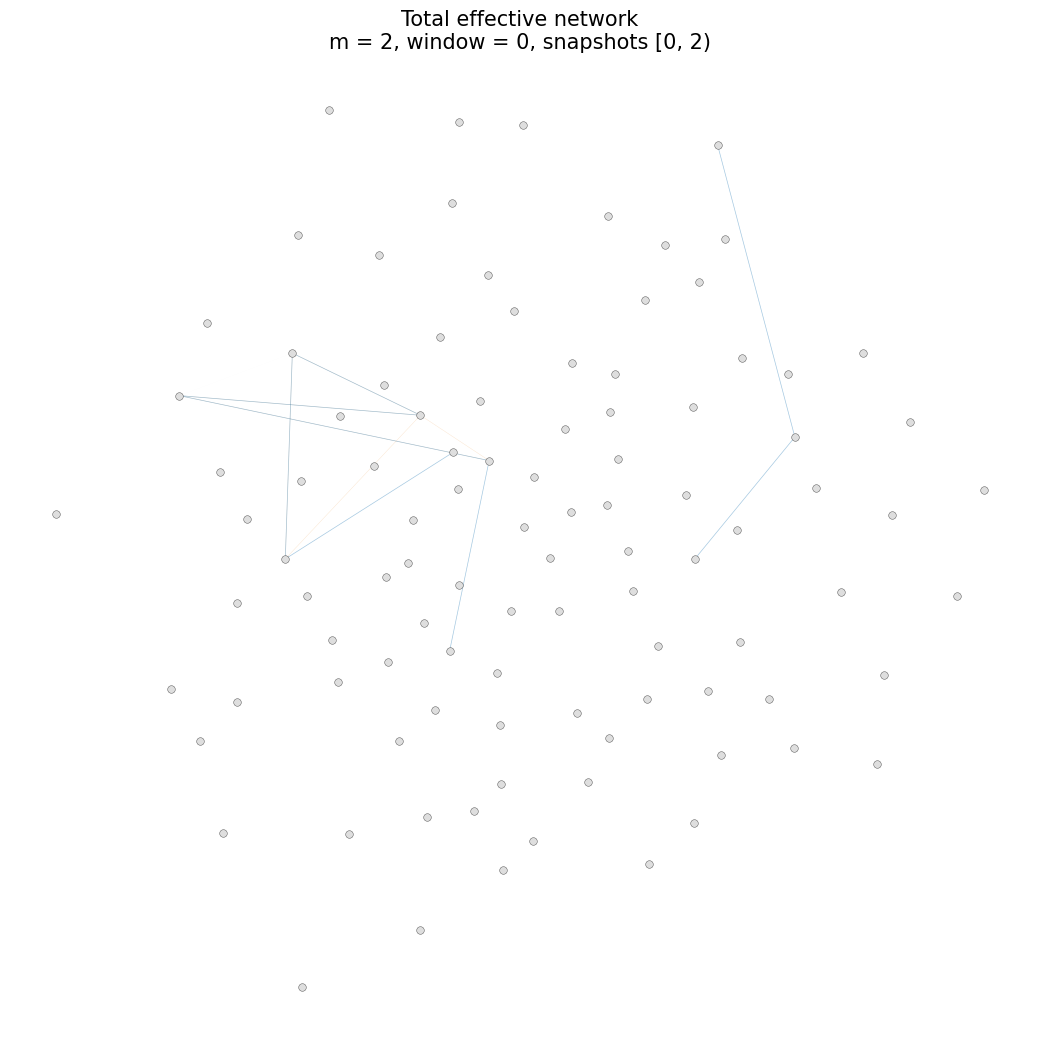

  [2/4] naive...
      saved: stage7_scaling_outputs\effective_w002_idx000_naive.png


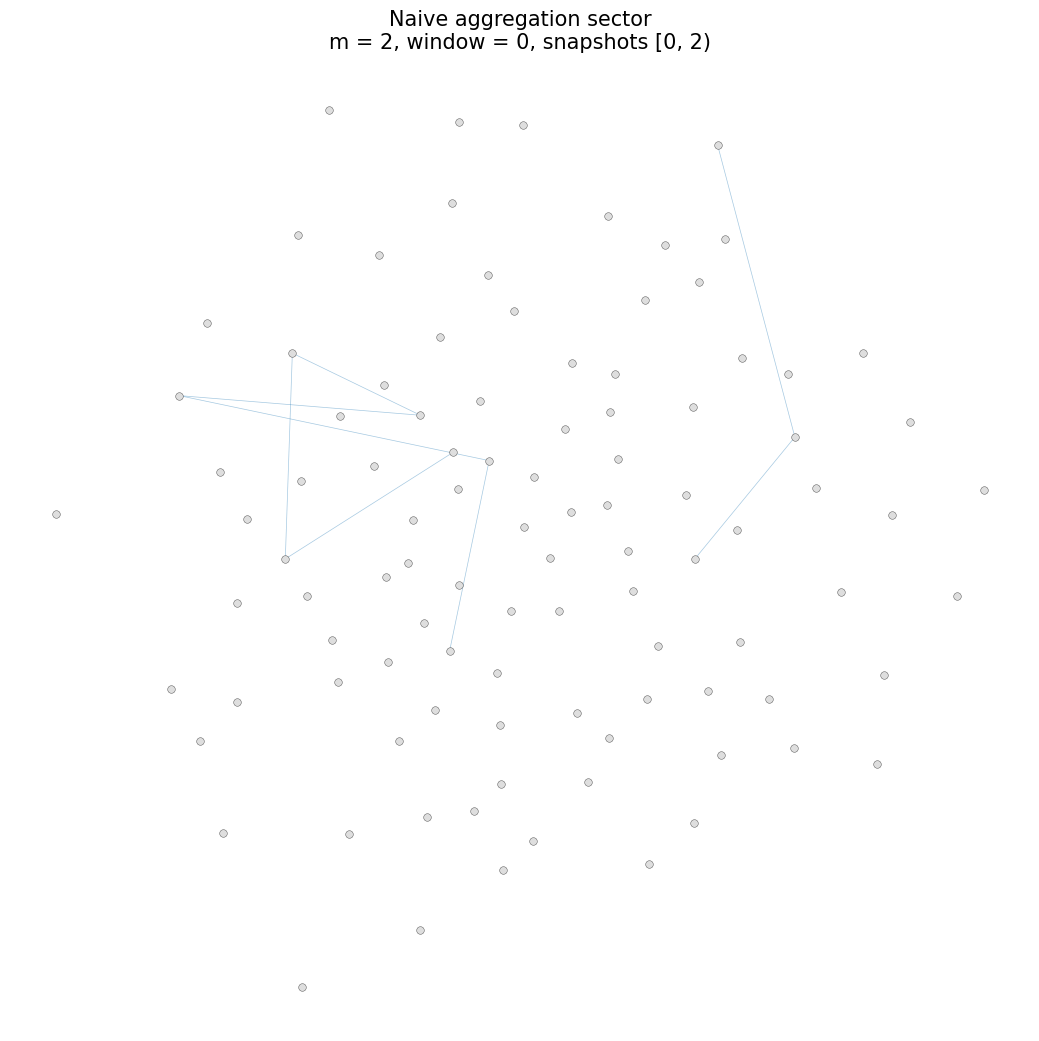

  [3/4] single commutator...
      saved: stage7_scaling_outputs\effective_w002_idx000_single_commutator.png


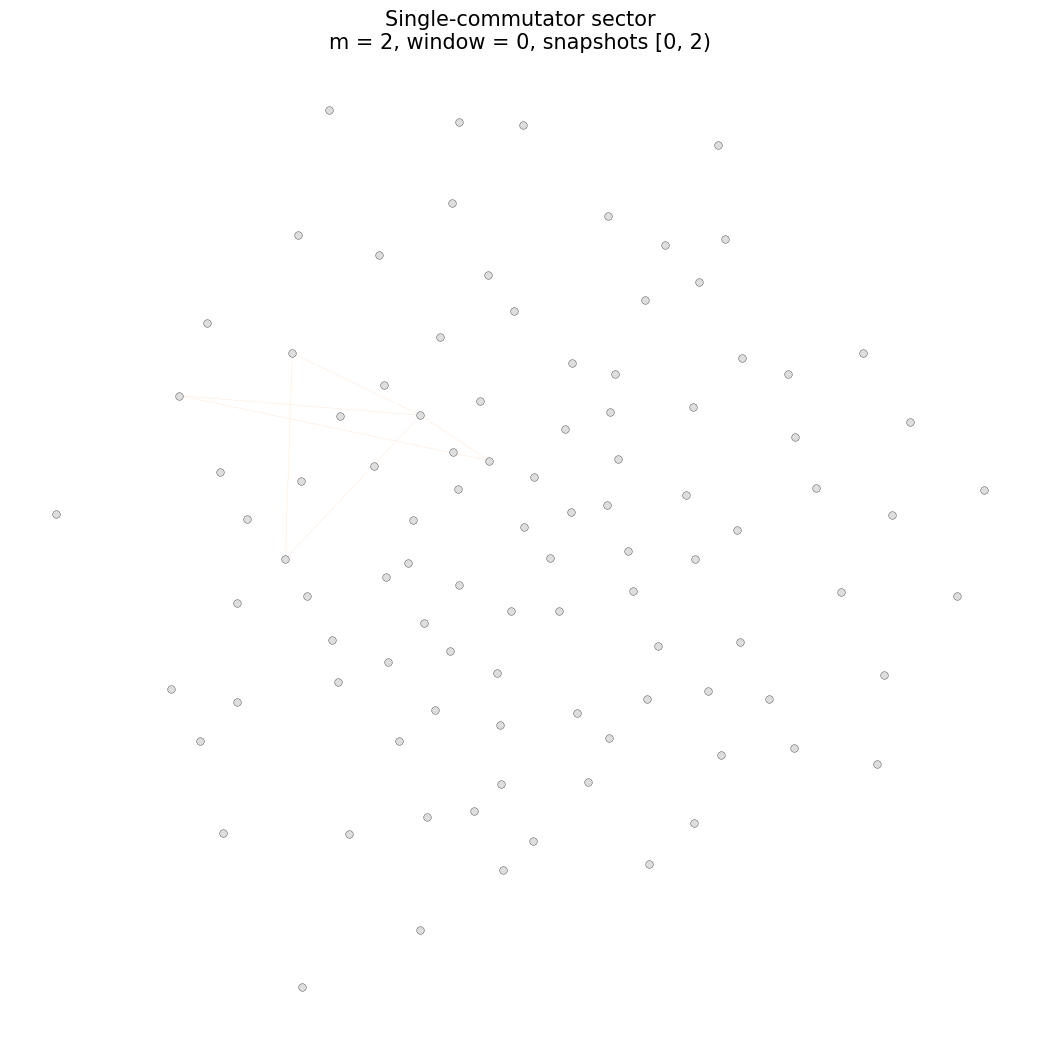

  [4/4] double commutator...
      saved: stage7_scaling_outputs\effective_w002_idx000_double_commutator.png


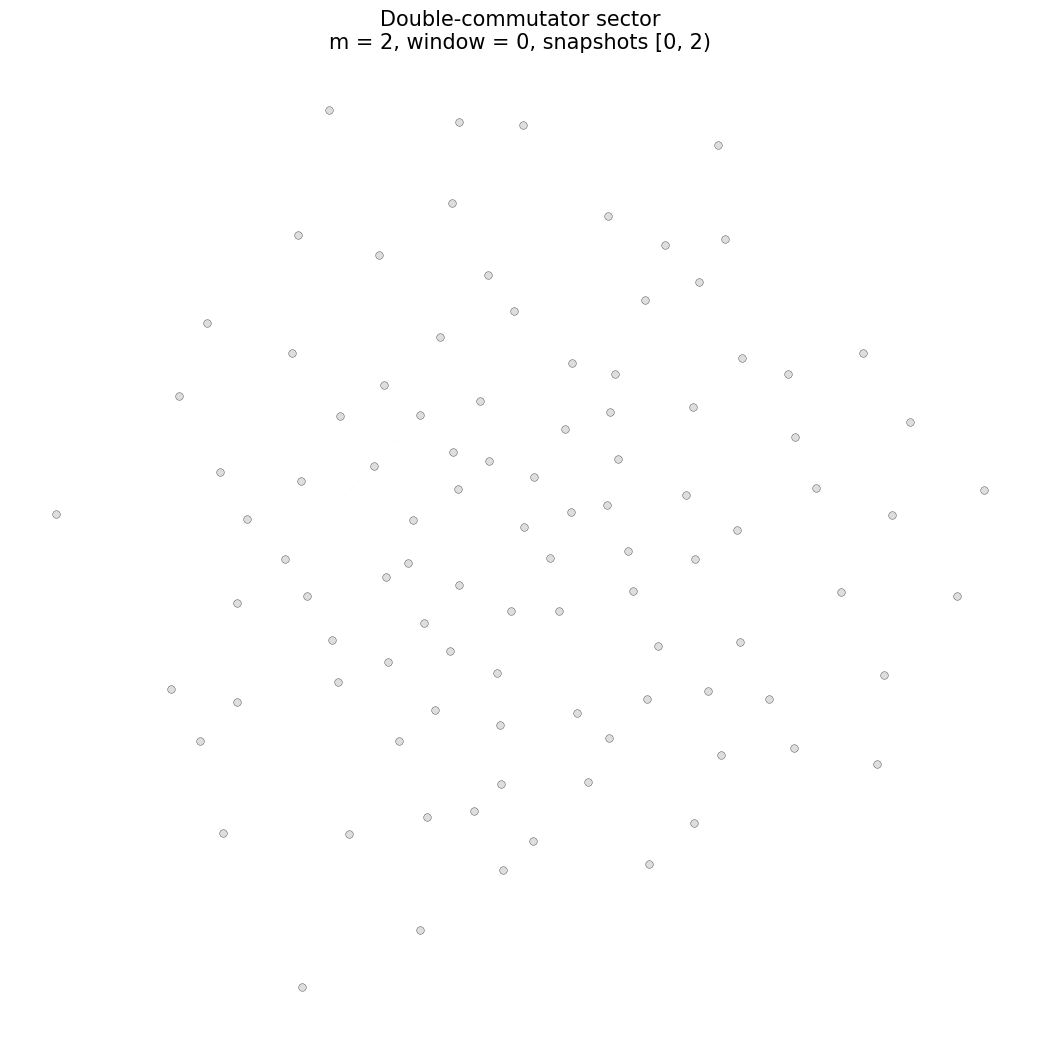

  done.

Plotting m=2, idx=9, snapshots [18, 20)

Effective decomposition: m=2, idx=9
  snapshots : [18, 20)
  time      : [0.900, 1.000)

Edge-source statistics


,sector,count,mean,median,q75,q90,q95,max,l2,fraction_of_all_pairs
0,naive,8,0.5,0.5,0.5,0.5,0.5,0.5,1.414214,0.001616
1,commutator,0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000
2,nested,0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000
3,BCH_total,8,0.5,0.5,0.5,0.5,0.5,0.5,1.414214,0.001616
4,exact_total,8,0.5,0.5,0.5,0.5,0.5,0.5,1.414214,0.001616
5,comm_generated_only,0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000
6,nested_generated_only,0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000


Saved source statistics: stage7_scaling_outputs\effective_w002_idx009_source_statistics.csv

  [1/4] total (overlay)...
      saved: stage7_scaling_outputs\effective_w002_idx009_total_overlay.png


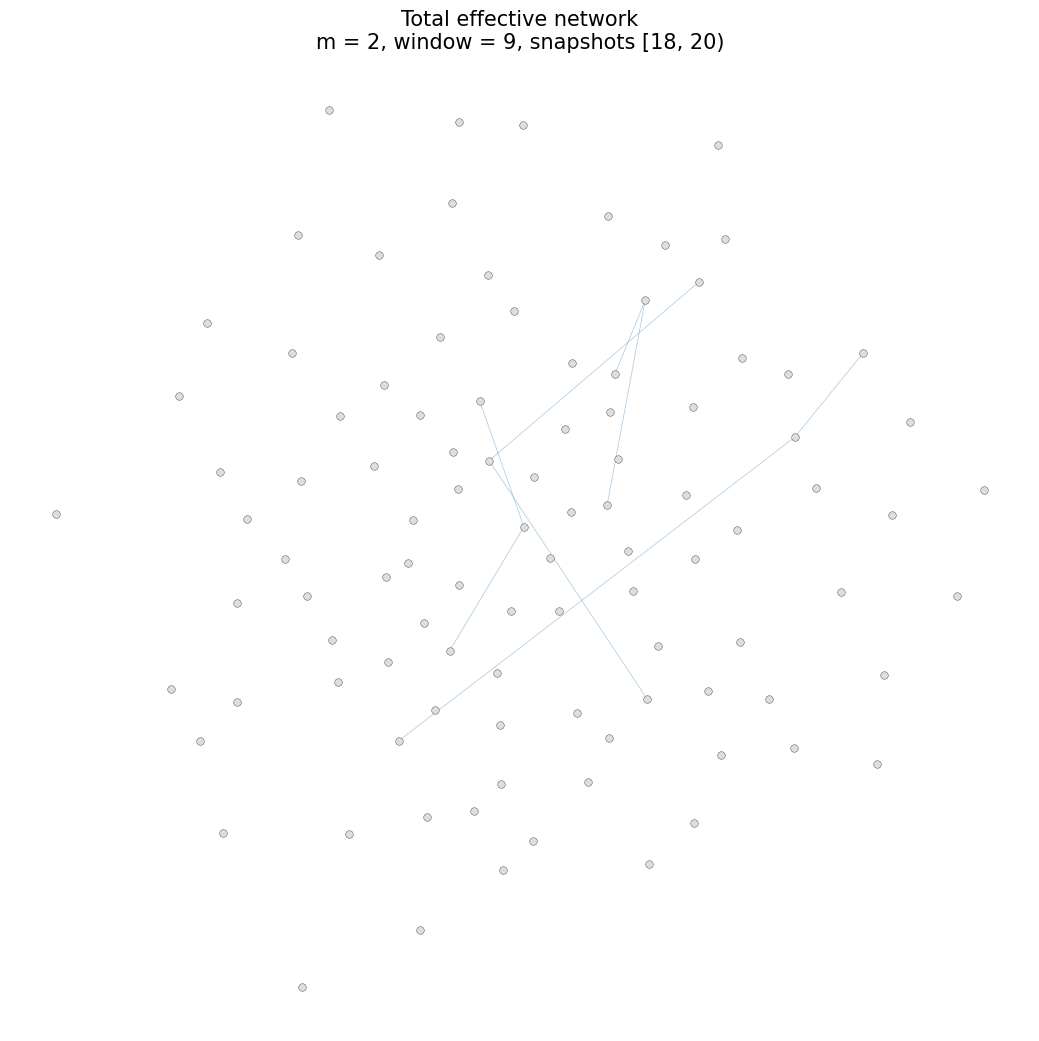

  [2/4] naive...
      saved: stage7_scaling_outputs\effective_w002_idx009_naive.png


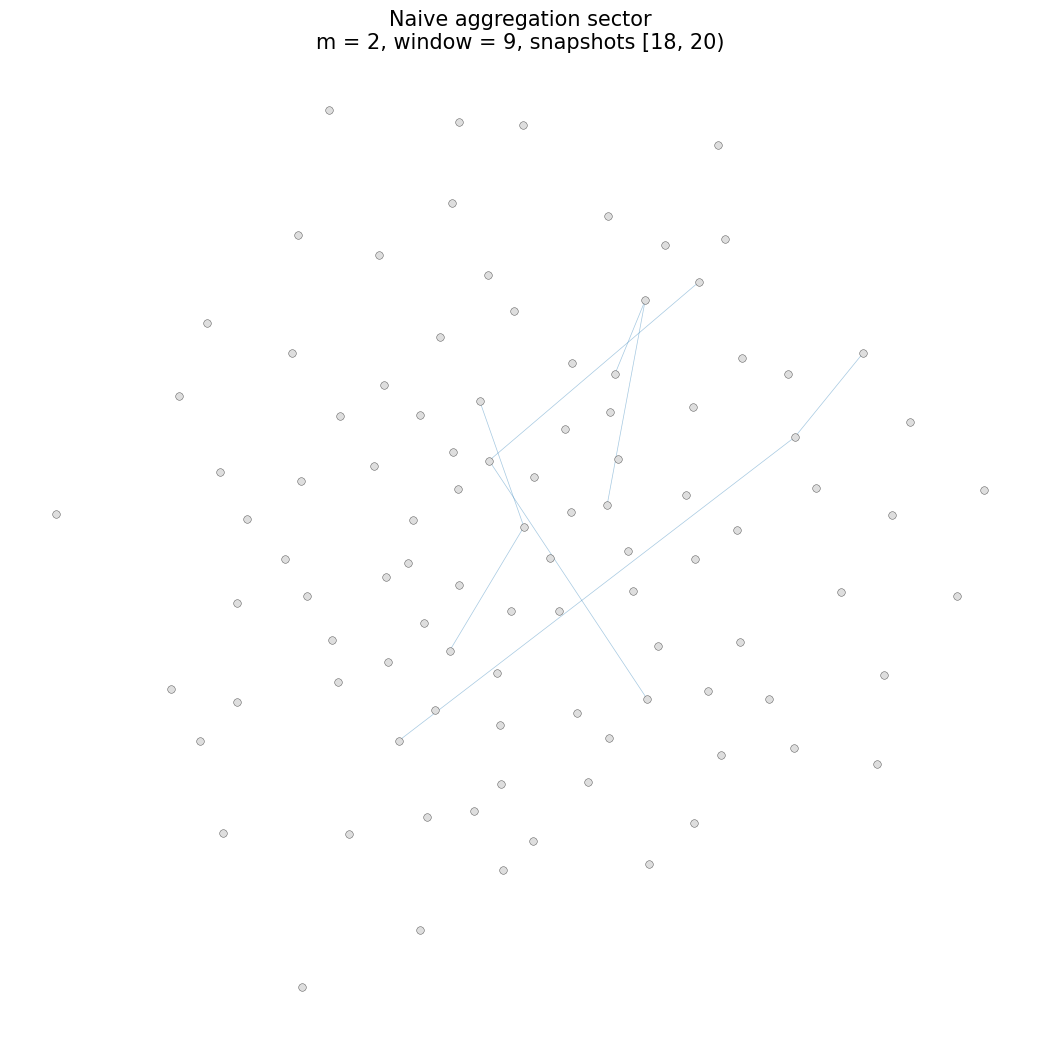

  [3/4] single commutator...
      saved: stage7_scaling_outputs\effective_w002_idx009_single_commutator.png


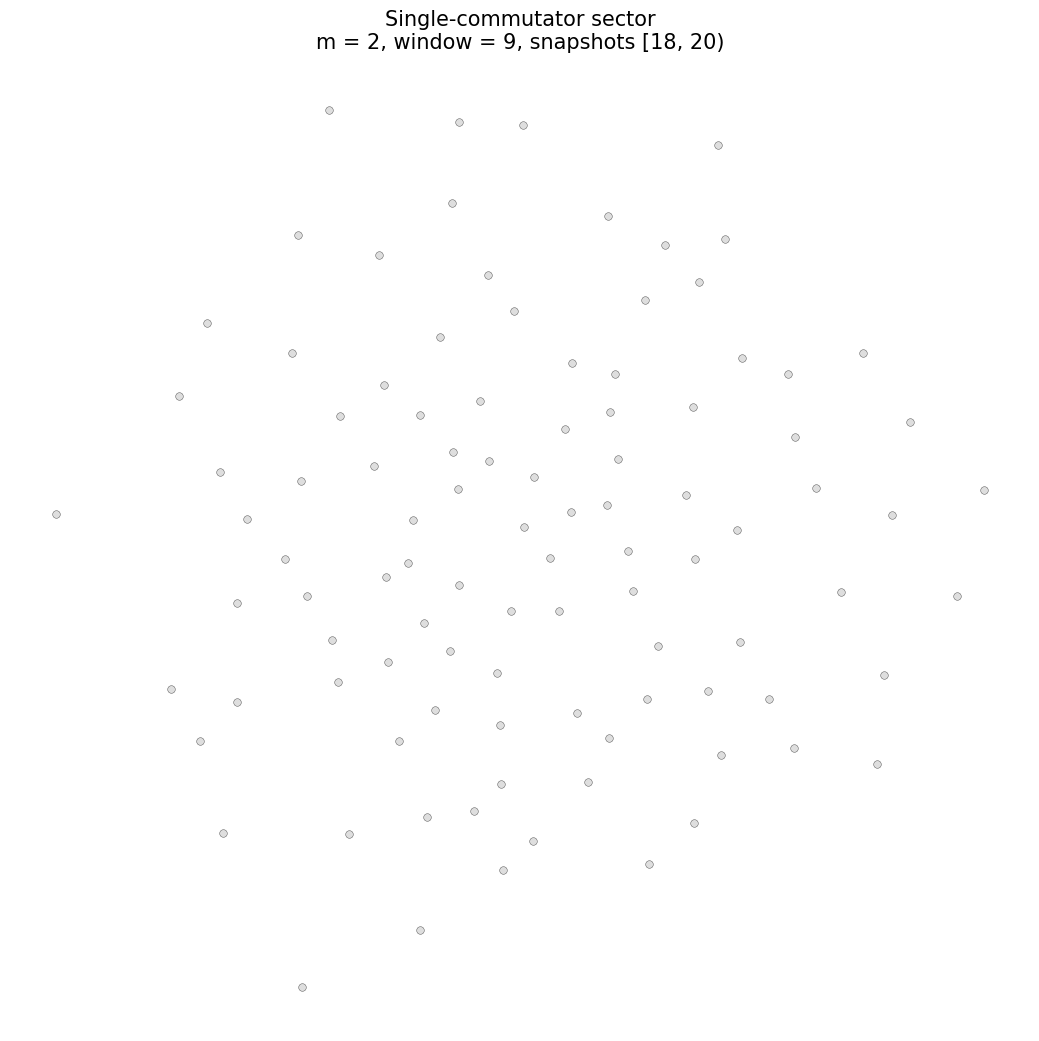

  [4/4] double commutator...
      saved: stage7_scaling_outputs\effective_w002_idx009_double_commutator.png


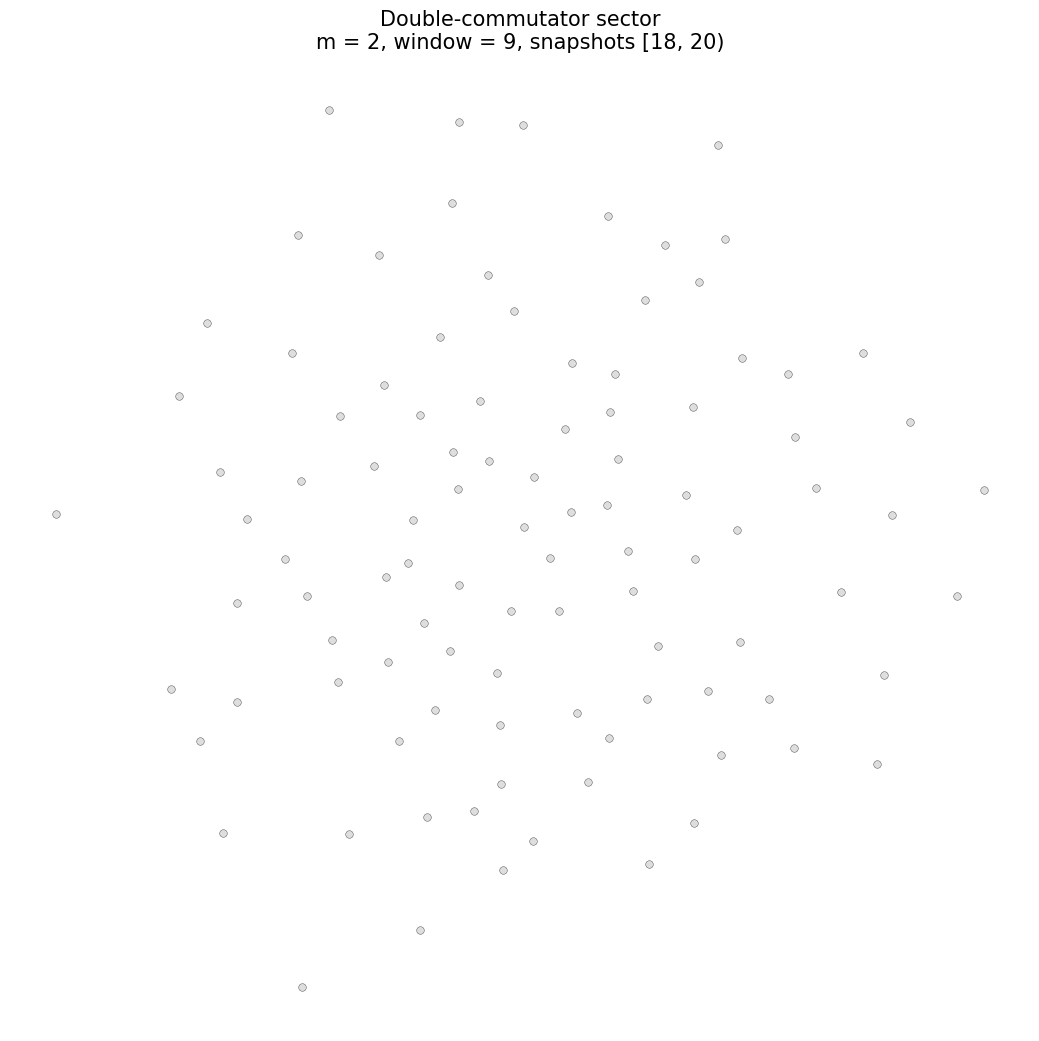

  done.

Plotting m=2, idx=18, snapshots [36, 38)

Effective decomposition: m=2, idx=18
  snapshots : [36, 38)
  time      : [1.800, 1.900)

Edge-source statistics


,sector,count,mean,median,q75,q90,q95,max,l2,fraction_of_all_pairs
0,naive,18,0.5,0.5,0.5,0.5,0.5,0.5,2.12132,0.003636
1,commutator,0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.000000
2,nested,0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.000000
3,BCH_total,18,0.5,0.5,0.5,0.5,0.5,0.5,2.12132,0.003636
4,exact_total,18,0.5,0.5,0.5,0.5,0.5,0.5,2.12132,0.003636
5,comm_generated_only,0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.000000
6,nested_generated_only,0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.000000


Saved source statistics: stage7_scaling_outputs\effective_w002_idx018_source_statistics.csv

  [1/4] total (overlay)...
      saved: stage7_scaling_outputs\effective_w002_idx018_total_overlay.png


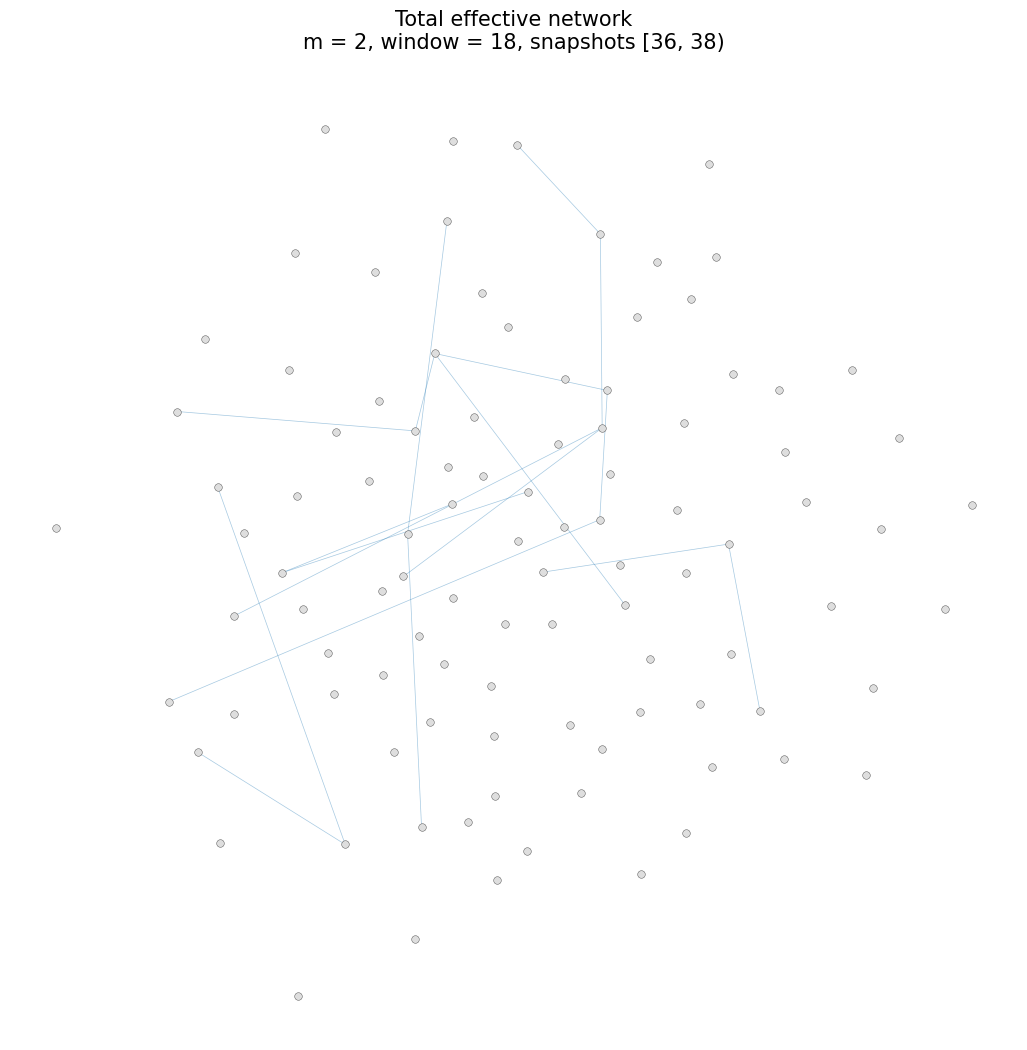

  [2/4] naive...
      saved: stage7_scaling_outputs\effective_w002_idx018_naive.png


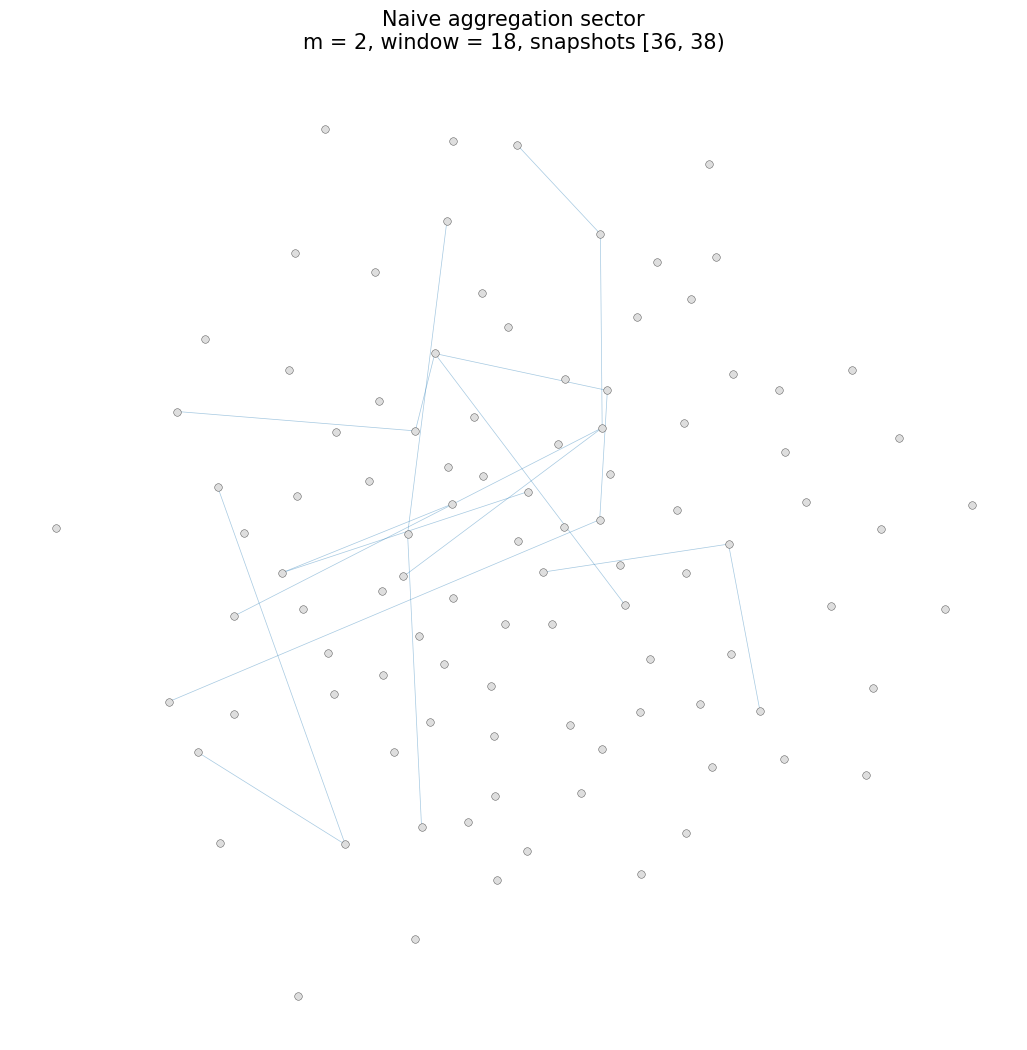

  [3/4] single commutator...
      saved: stage7_scaling_outputs\effective_w002_idx018_single_commutator.png


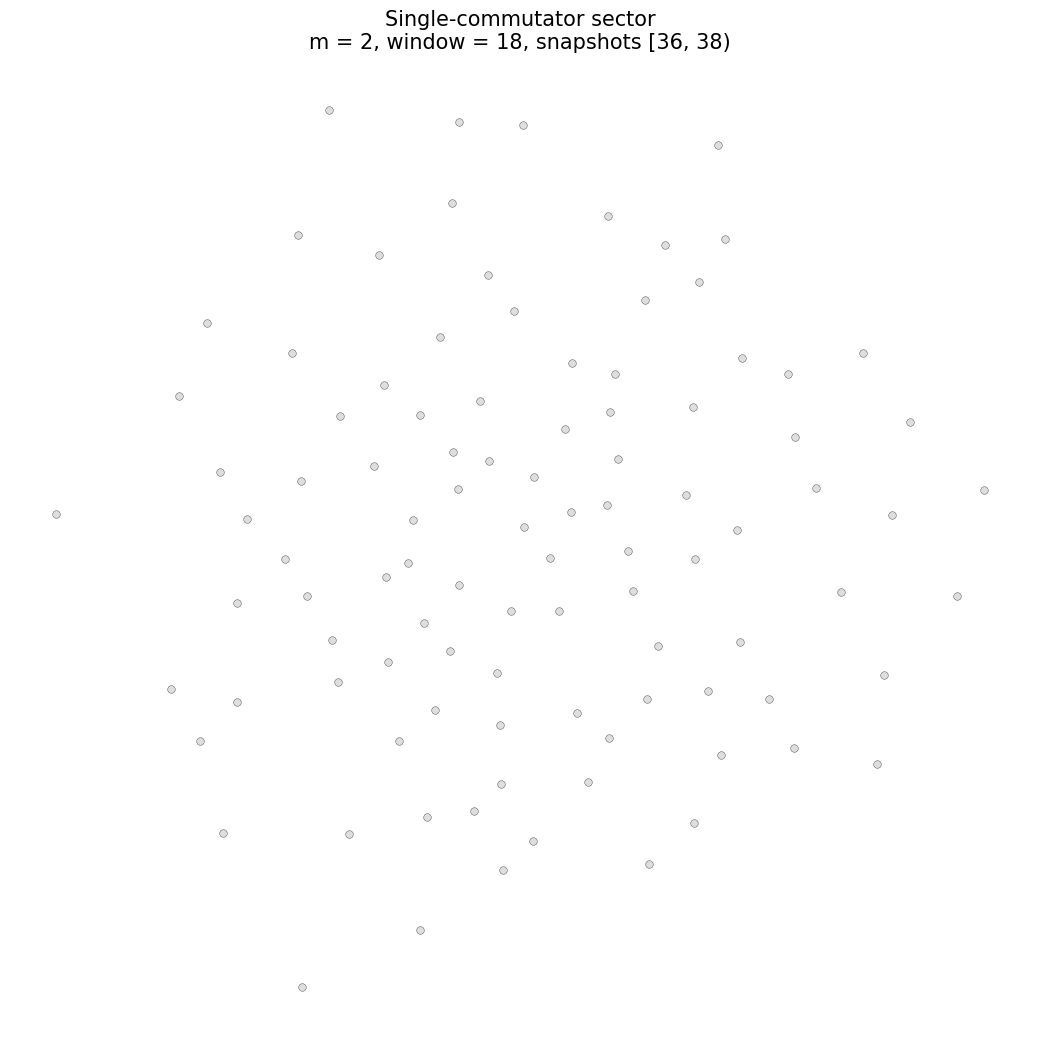

  [4/4] double commutator...
      saved: stage7_scaling_outputs\effective_w002_idx018_double_commutator.png


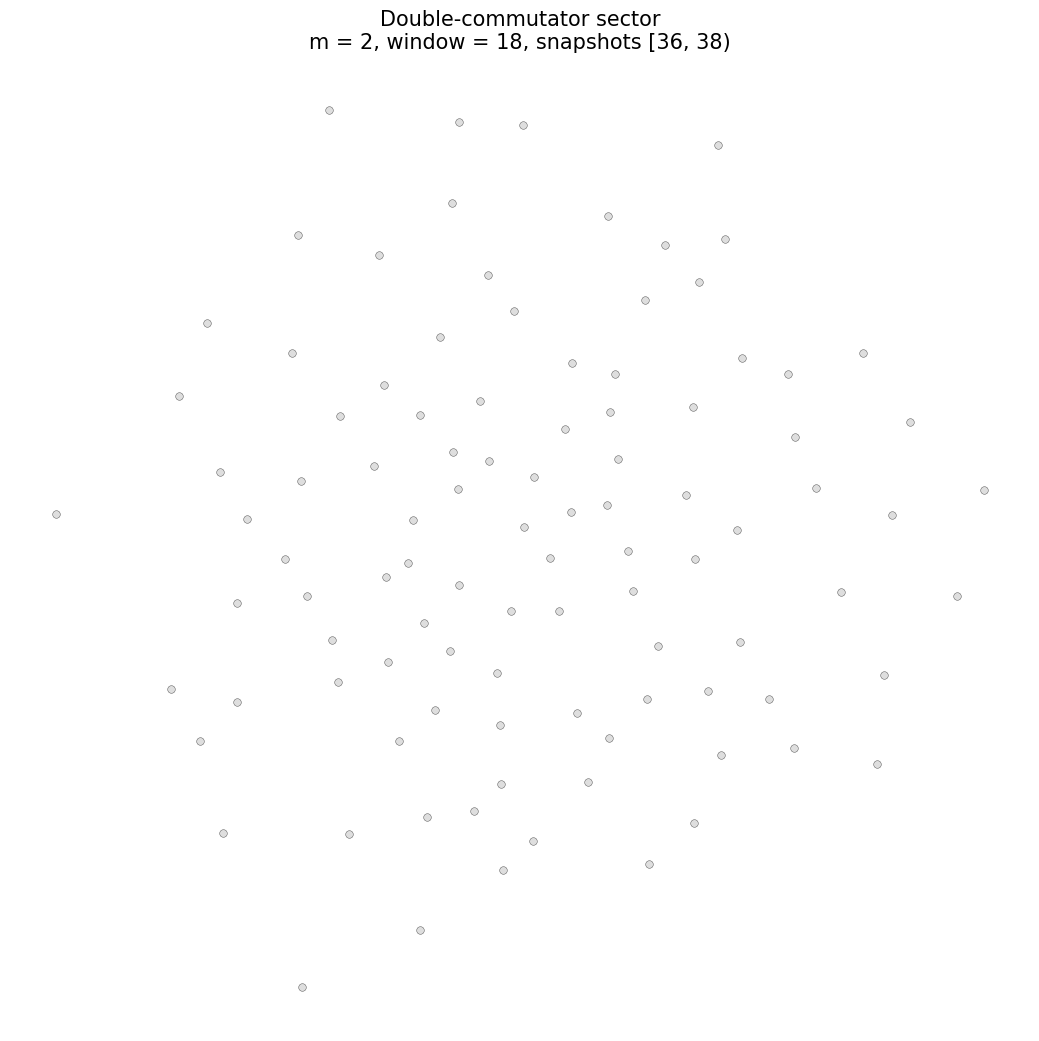

  done.

Plotting m=2, idx=27, snapshots [54, 56)

Effective decomposition: m=2, idx=27
  snapshots : [54, 56)
  time      : [2.700, 2.800)

Edge-source statistics


,sector,count,mean,median,q75,q90,q95,max,l2,fraction_of_all_pairs
0,naive,6,0.5,0.5,0.5,0.5,0.5,0.5,1.224745,0.001212
1,commutator,0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000
2,nested,0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000
3,BCH_total,6,0.5,0.5,0.5,0.5,0.5,0.5,1.224745,0.001212
4,exact_total,6,0.5,0.5,0.5,0.5,0.5,0.5,1.224745,0.001212
5,comm_generated_only,0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000
6,nested_generated_only,0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000


Saved source statistics: stage7_scaling_outputs\effective_w002_idx027_source_statistics.csv

  [1/4] total (overlay)...
      saved: stage7_scaling_outputs\effective_w002_idx027_total_overlay.png


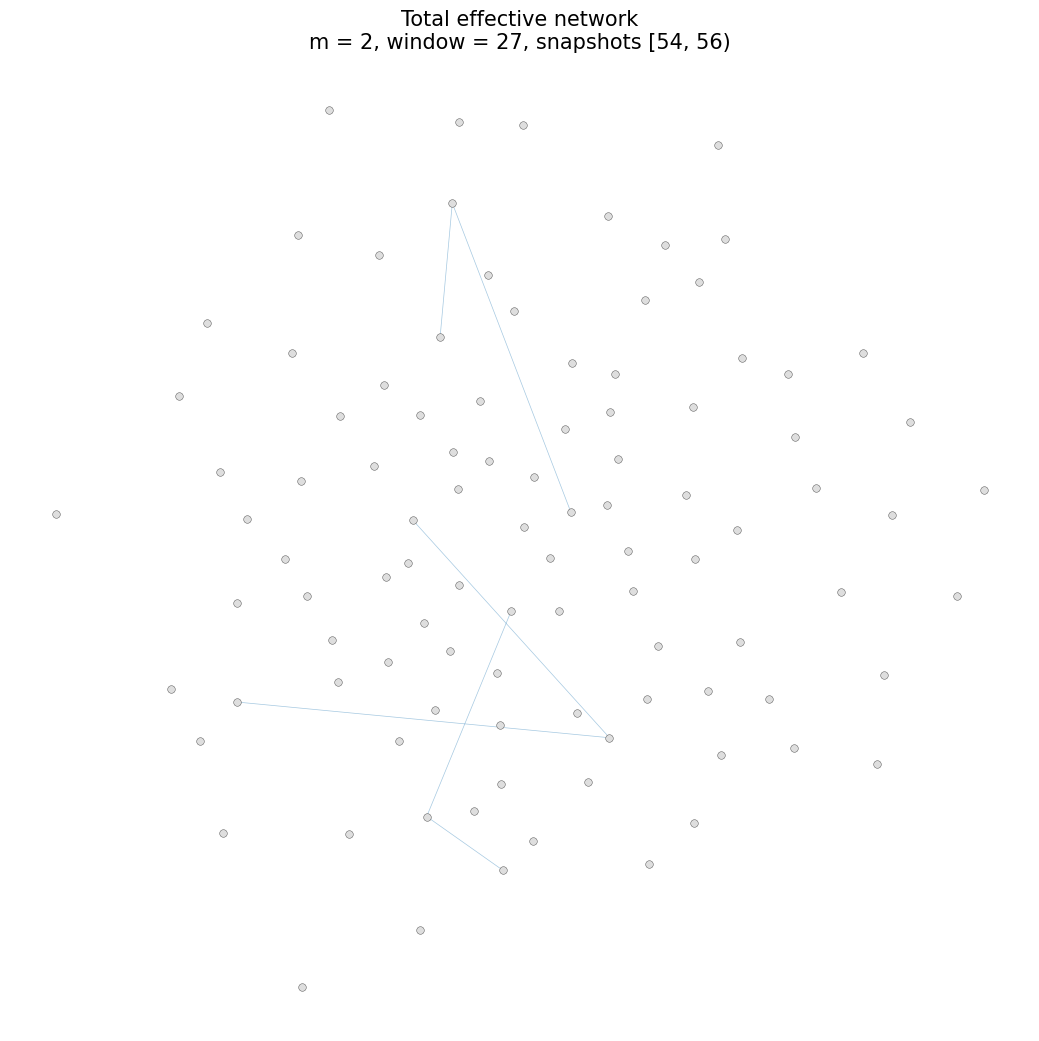

  [2/4] naive...
      saved: stage7_scaling_outputs\effective_w002_idx027_naive.png


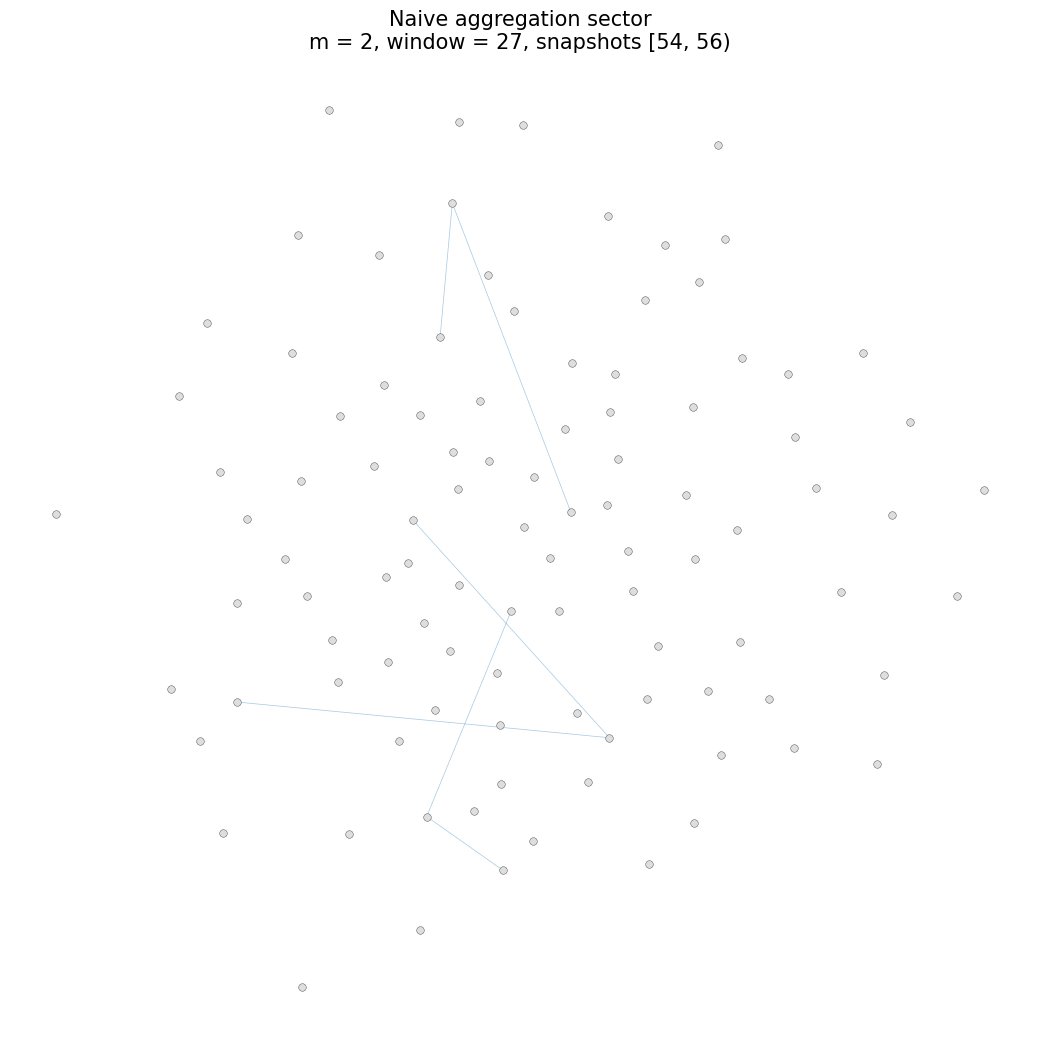

  [3/4] single commutator...
      saved: stage7_scaling_outputs\effective_w002_idx027_single_commutator.png


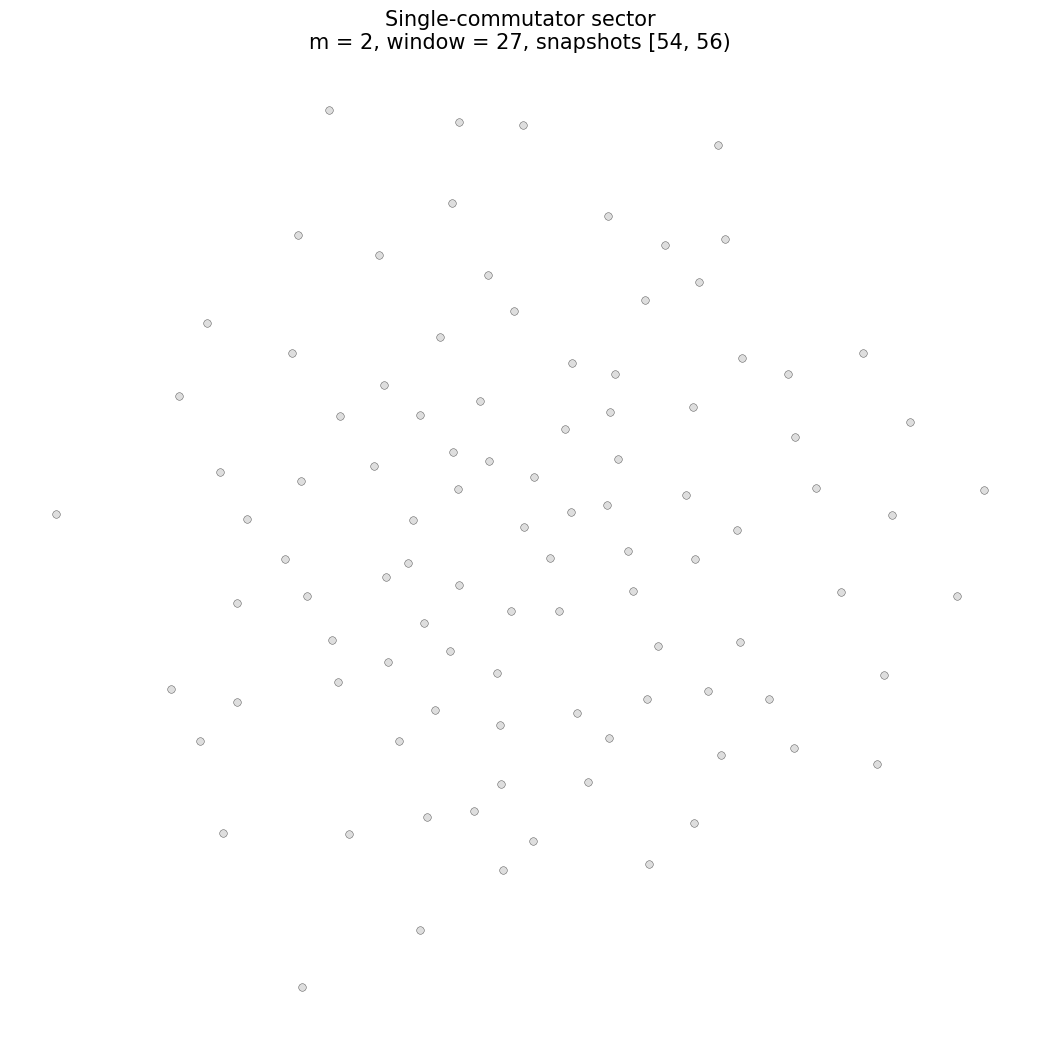

  [4/4] double commutator...
      saved: stage7_scaling_outputs\effective_w002_idx027_double_commutator.png


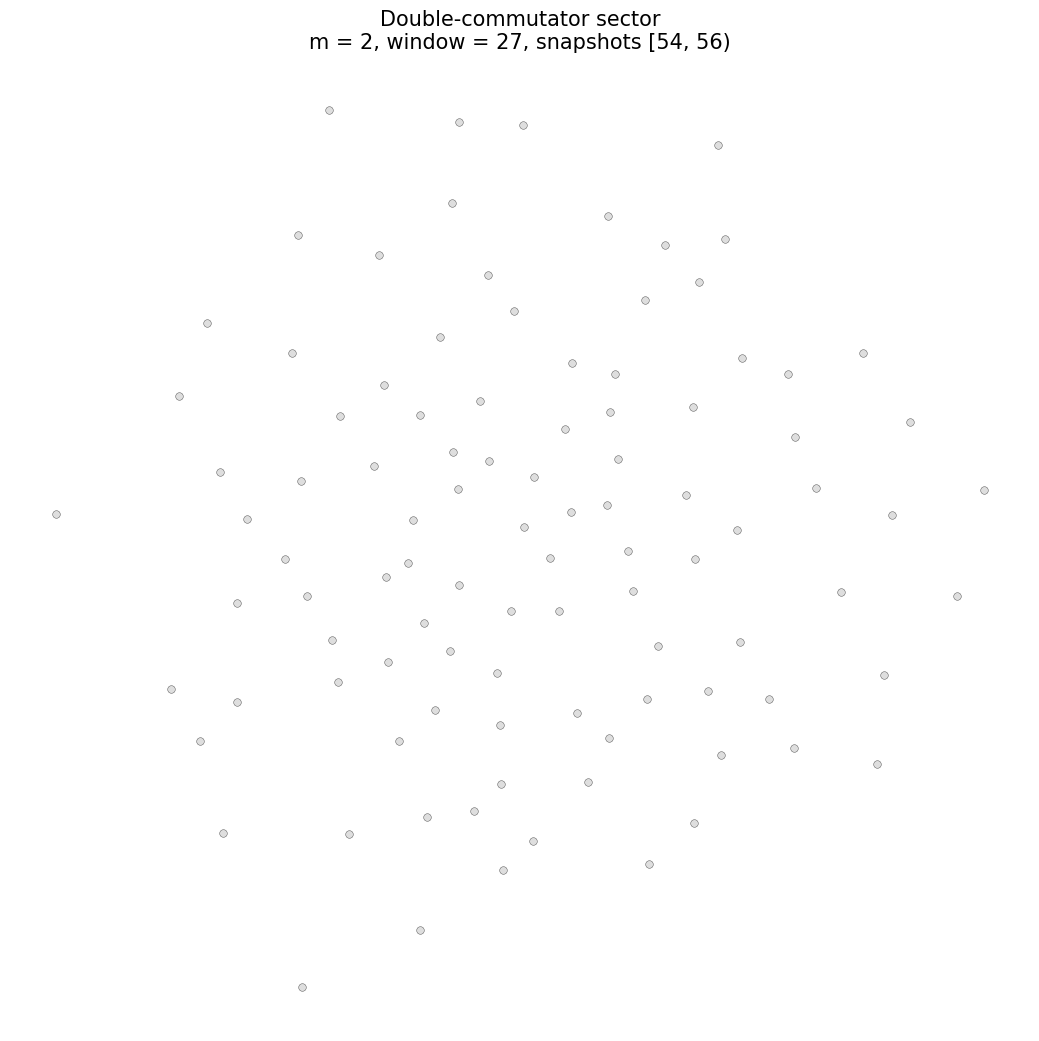

  done.

Plotting m=2, idx=36, snapshots [72, 74)

Effective decomposition: m=2, idx=36
  snapshots : [72, 74)
  time      : [3.600, 3.700)

Edge-source statistics


,sector,count,mean,median,q75,q90,q95,max,l2,fraction_of_all_pairs
0,naive,10,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,1.581139,0.002020
1,commutator,5,0.015000,0.012500,0.012500,0.020000,0.022500,0.025000,0.035355,0.001010
2,nested,9,0.000324,0.000208,0.000625,0.000667,0.000750,0.000833,0.001267,0.001818
3,BCH_total,16,0.314227,0.500000,0.500000,0.500260,0.500559,0.501457,1.581864,0.003232
4,exact_total,16,0.314229,0.500000,0.500000,0.500260,0.500560,0.501459,1.581865,0.003232
5,comm_generated_only,2,0.012500,0.012500,0.012500,0.012500,0.012500,0.012500,0.017678,0.000404
6,nested_generated_only,4,0.000156,0.000156,0.000208,0.000208,0.000208,0.000208,0.000329,0.000808


Saved source statistics: stage7_scaling_outputs\effective_w002_idx036_source_statistics.csv

  [1/4] total (overlay)...
      saved: stage7_scaling_outputs\effective_w002_idx036_total_overlay.png


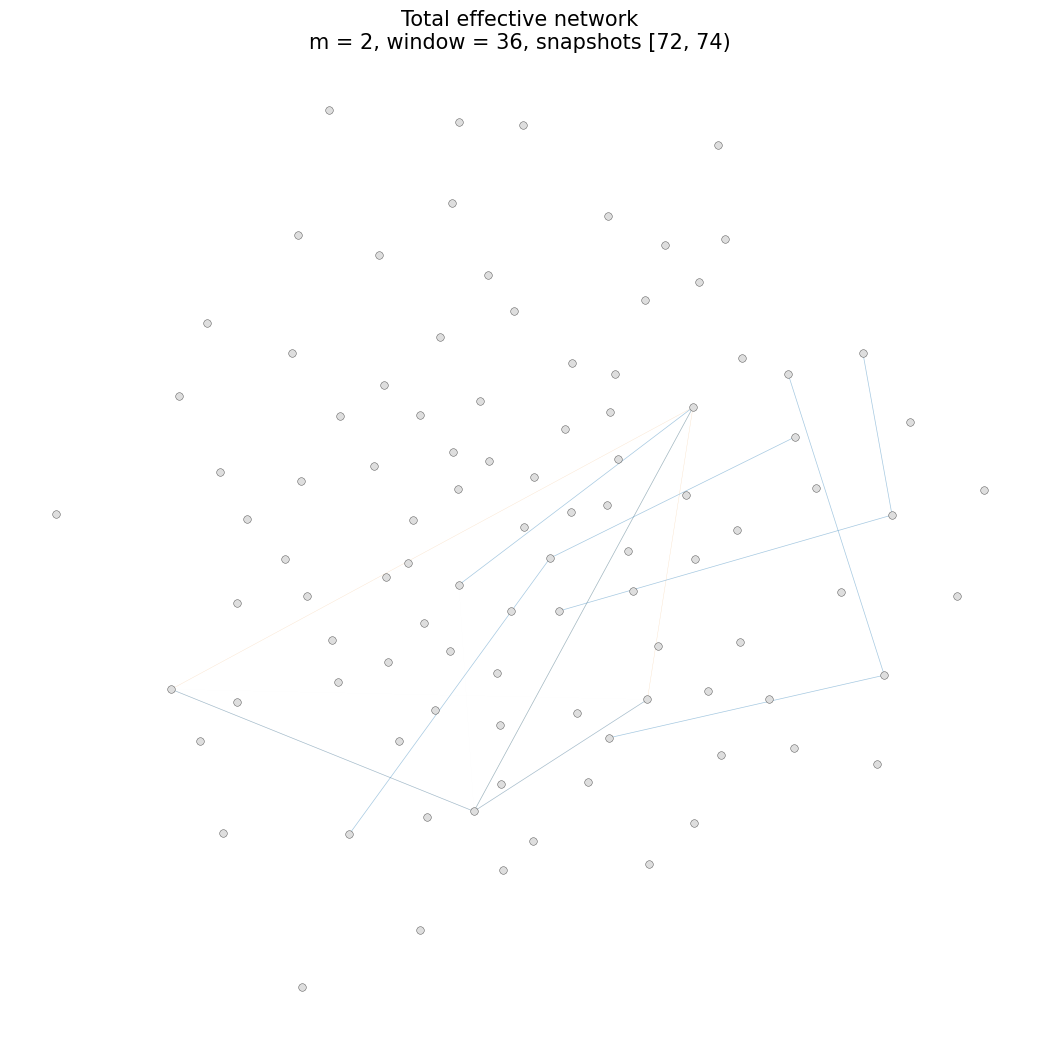

  [2/4] naive...
      saved: stage7_scaling_outputs\effective_w002_idx036_naive.png


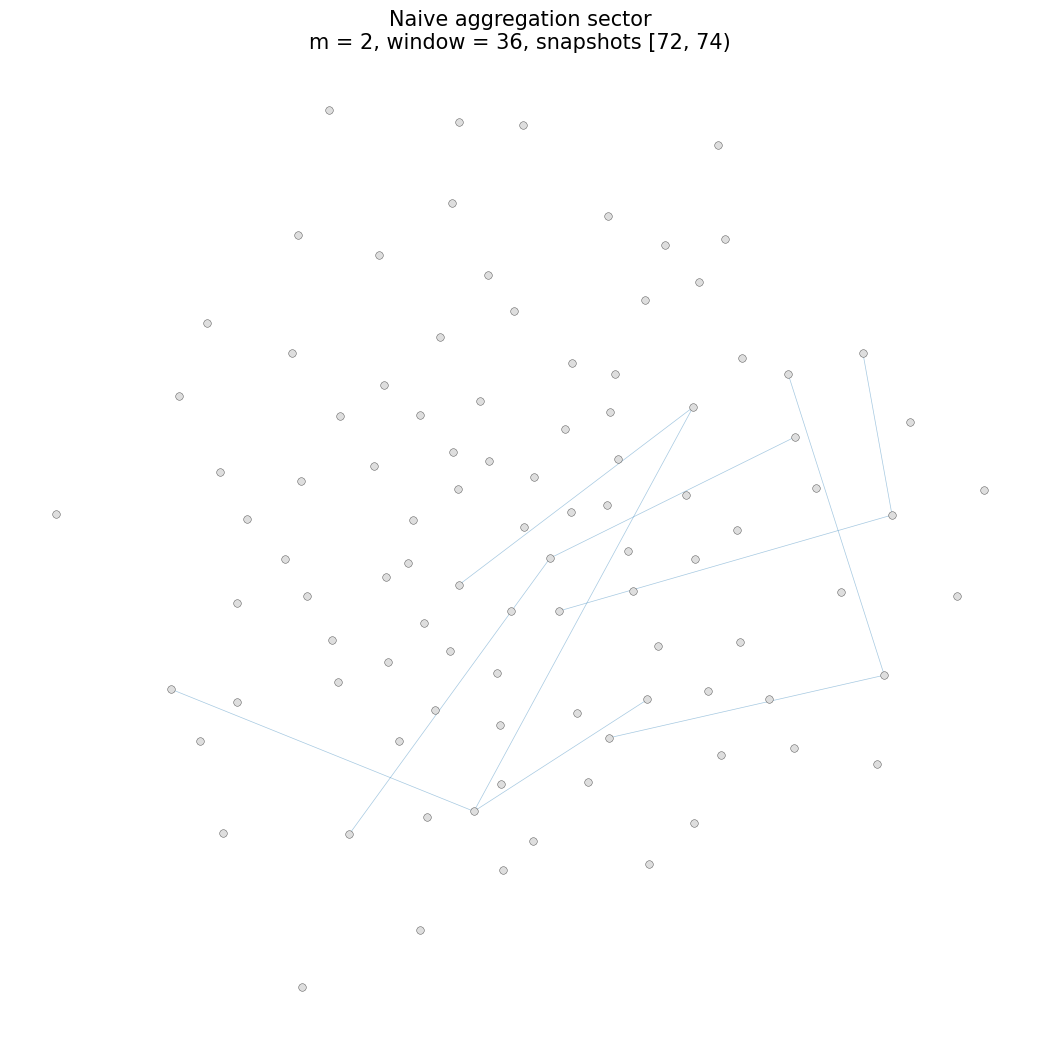

  [3/4] single commutator...
      saved: stage7_scaling_outputs\effective_w002_idx036_single_commutator.png


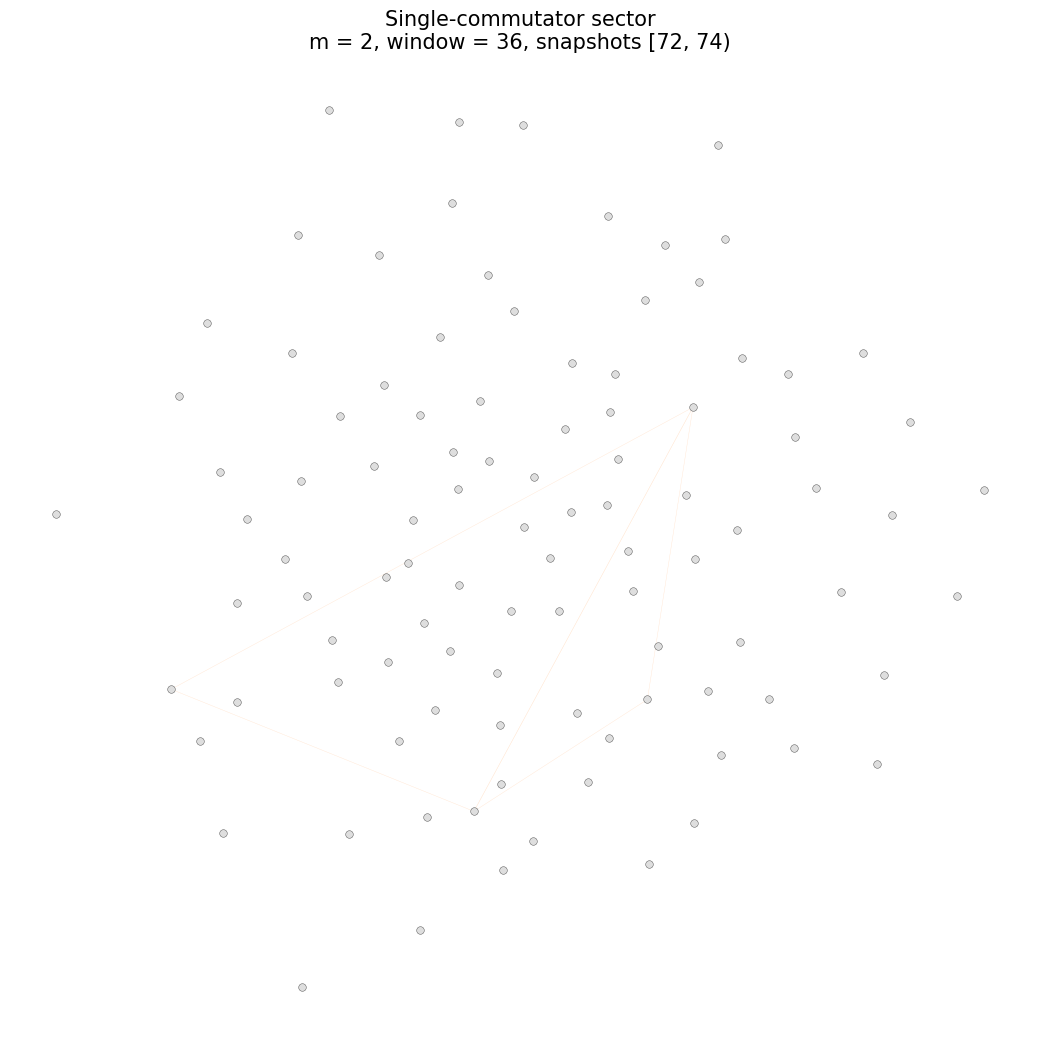

  [4/4] double commutator...
      saved: stage7_scaling_outputs\effective_w002_idx036_double_commutator.png


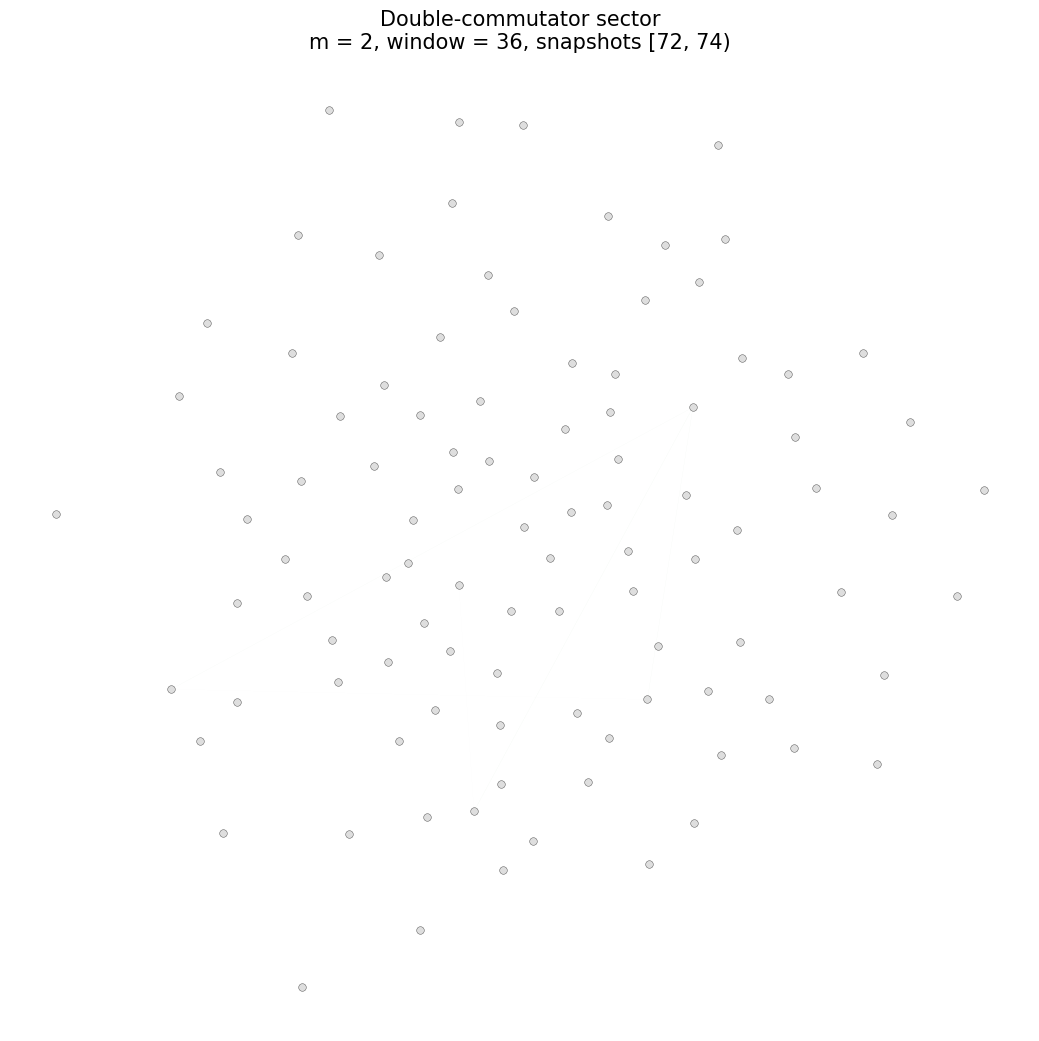

  done.

Plotting m=2, idx=45, snapshots [90, 92)

Effective decomposition: m=2, idx=45
  snapshots : [90, 92)
  time      : [4.500, 4.600)

Edge-source statistics


,sector,count,mean,median,q75,q90,q95,max,l2,fraction_of_all_pairs
0,naive,14,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,1.870829,0.002828
1,commutator,10,0.015000,0.012500,0.012500,0.025000,0.025000,0.025000,0.050000,0.002020
2,nested,21,0.000317,0.000208,0.000625,0.000729,0.000833,0.000833,0.001921,0.004242
3,BCH_total,29,0.243307,0.012521,0.500000,0.500364,0.501020,0.501457,1.872110,0.005859
4,exact_total,42,0.168000,0.000157,0.500000,0.500260,0.500365,0.501458,1.872111,0.008485
5,comm_generated_only,4,0.012500,0.012500,0.012500,0.012500,0.012500,0.012500,0.025000,0.000808
6,nested_generated_only,11,0.000152,0.000104,0.000156,0.000208,0.000313,0.000417,0.000589,0.002222


Saved source statistics: stage7_scaling_outputs\effective_w002_idx045_source_statistics.csv

  [1/4] total (overlay)...
      saved: stage7_scaling_outputs\effective_w002_idx045_total_overlay.png


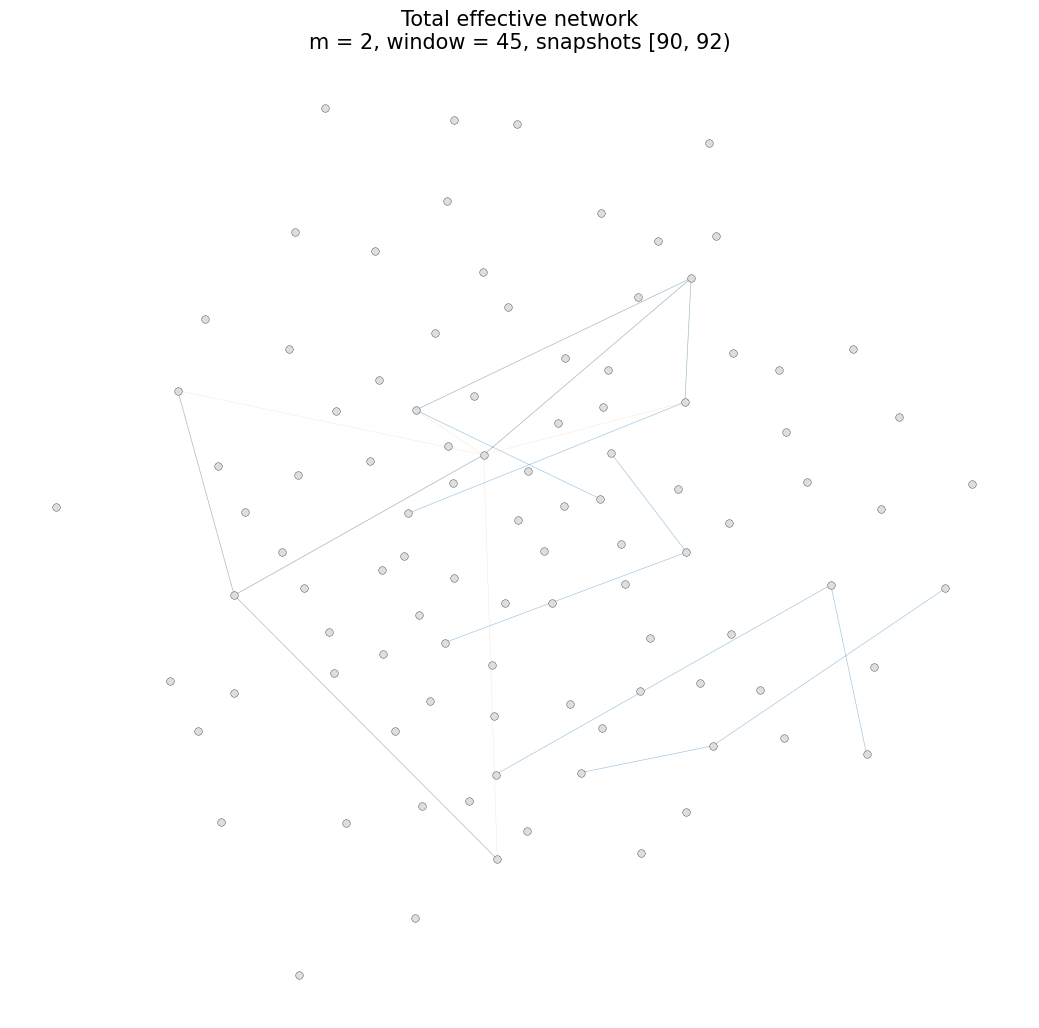

  [2/4] naive...
      saved: stage7_scaling_outputs\effective_w002_idx045_naive.png


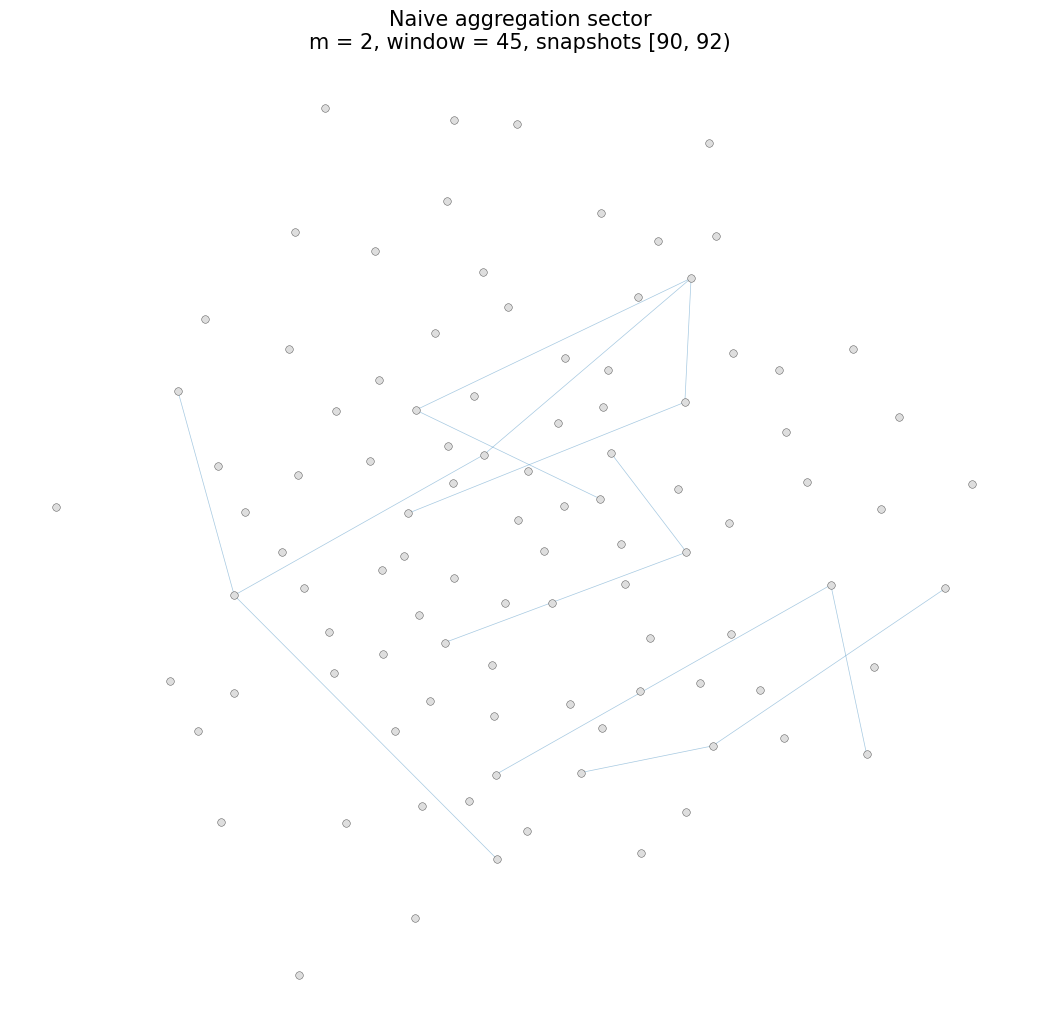

  [3/4] single commutator...
      saved: stage7_scaling_outputs\effective_w002_idx045_single_commutator.png


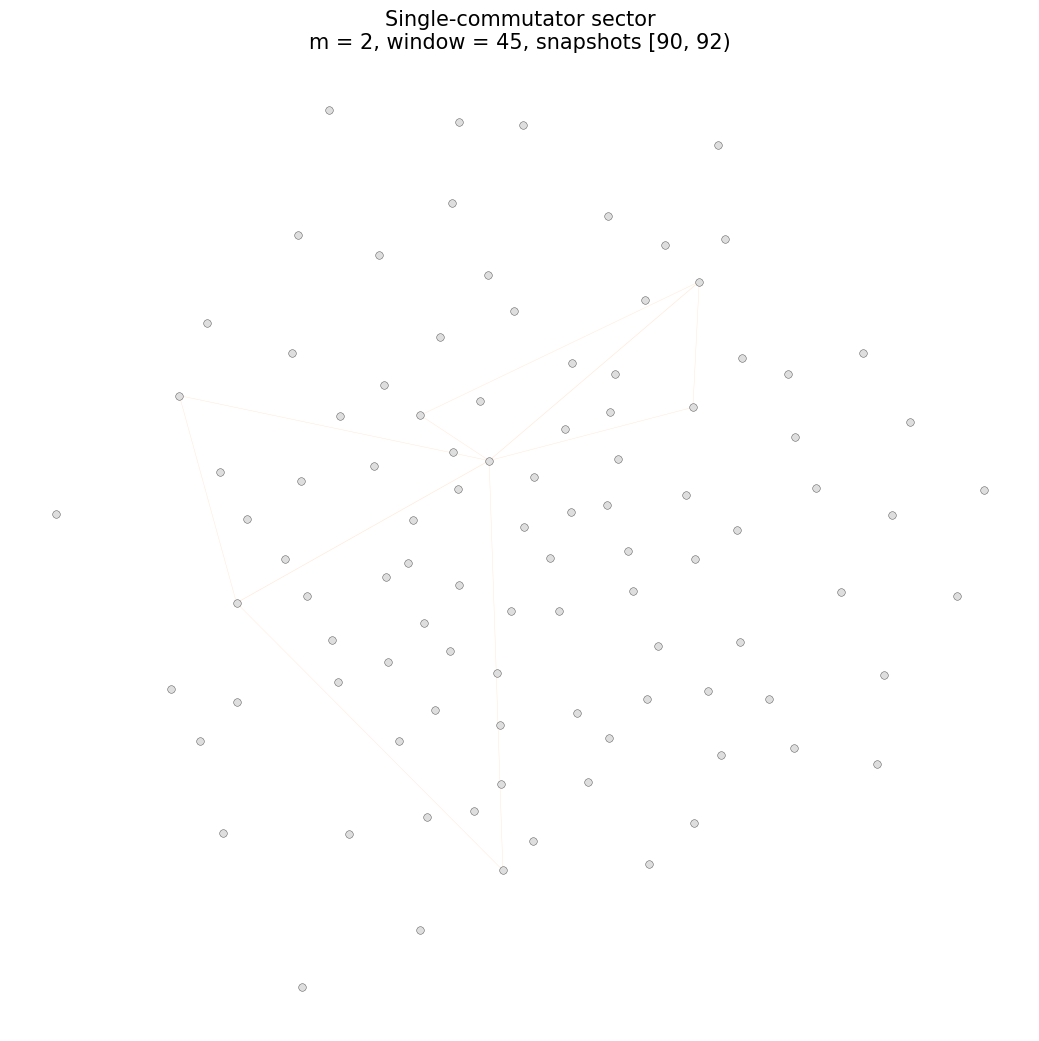

  [4/4] double commutator...
      saved: stage7_scaling_outputs\effective_w002_idx045_double_commutator.png


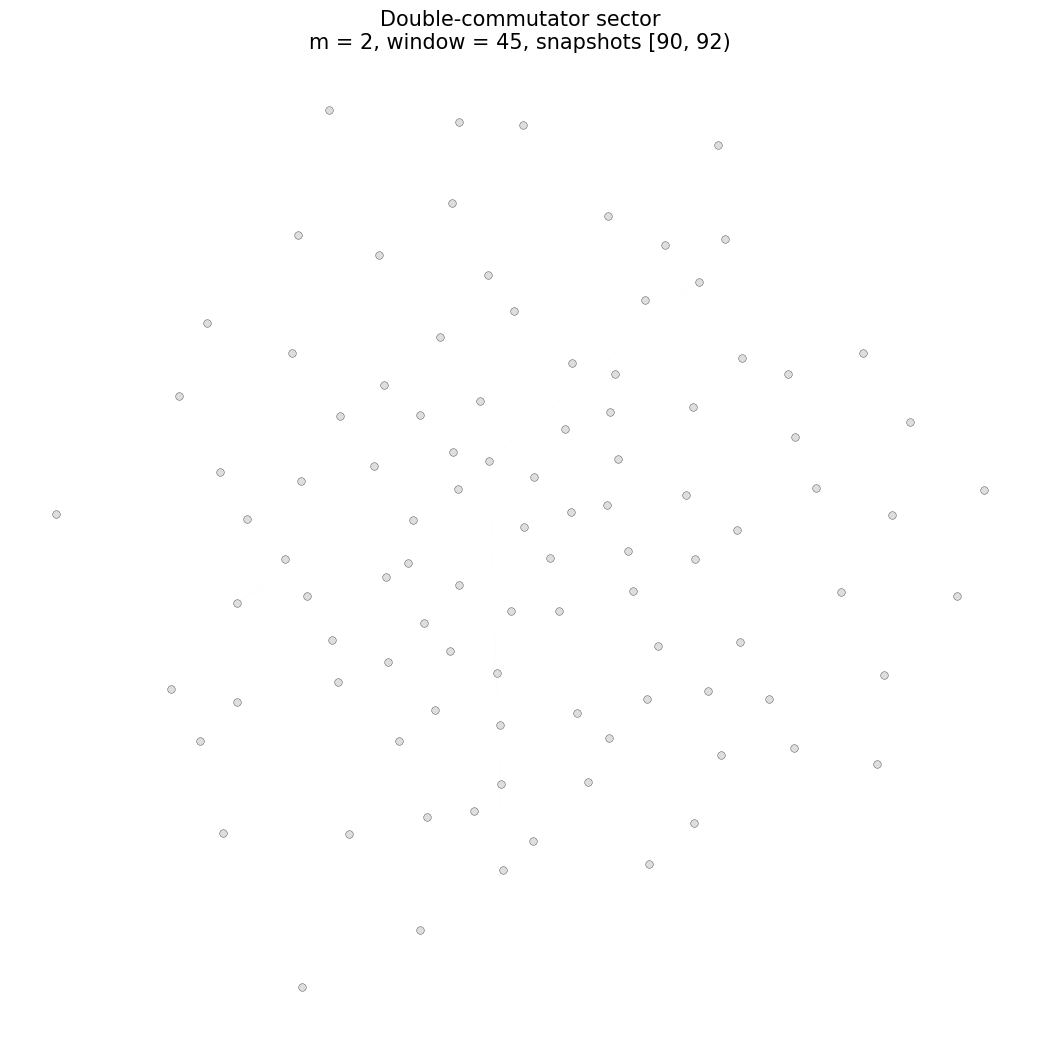

  done.

Plotting m=2, idx=54, snapshots [108, 110)

Effective decomposition: m=2, idx=54
  snapshots : [108, 110)
  time      : [5.400, 5.500)

Edge-source statistics


,sector,count,mean,median,q75,q90,q95,max,l2,fraction_of_all_pairs
0,naive,12,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,1.732051,0.002424
1,commutator,8,0.018750,0.018750,0.025000,0.025000,0.025000,0.025000,0.055902,0.001616
2,nested,10,0.000500,0.000417,0.000625,0.000625,0.000625,0.000625,0.001614,0.002020
3,BCH_total,18,0.336392,0.500000,0.500000,0.501041,0.501041,0.501041,1.733434,0.003636
4,exact_total,18,0.336393,0.500000,0.500000,0.501041,0.501041,0.501041,1.733434,0.003636
5,comm_generated_only,4,0.012500,0.012500,0.012500,0.012500,0.012500,0.012500,0.025000,0.000808
6,nested_generated_only,2,0.000417,0.000417,0.000417,0.000417,0.000417,0.000417,0.000589,0.000404


Saved source statistics: stage7_scaling_outputs\effective_w002_idx054_source_statistics.csv

  [1/4] total (overlay)...
      saved: stage7_scaling_outputs\effective_w002_idx054_total_overlay.png


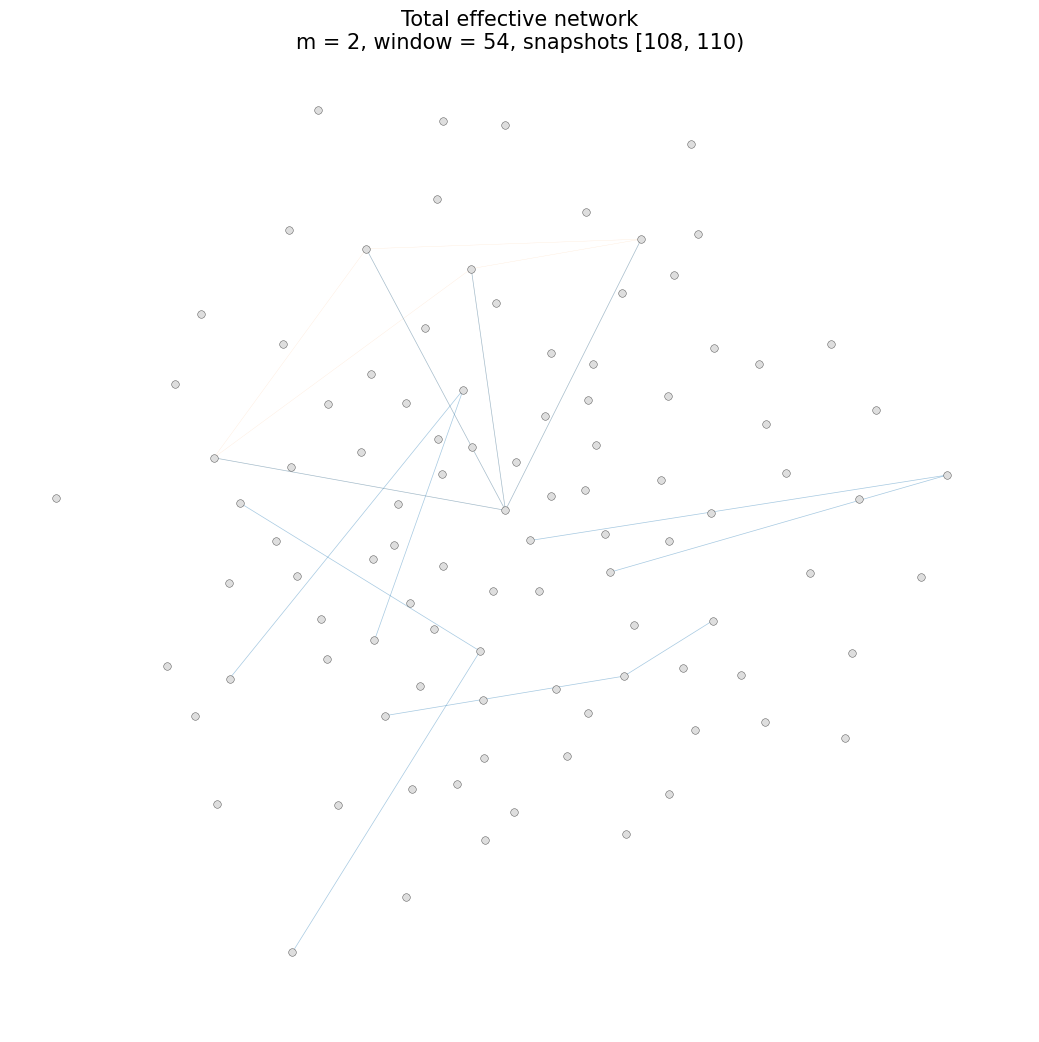

  [2/4] naive...
      saved: stage7_scaling_outputs\effective_w002_idx054_naive.png


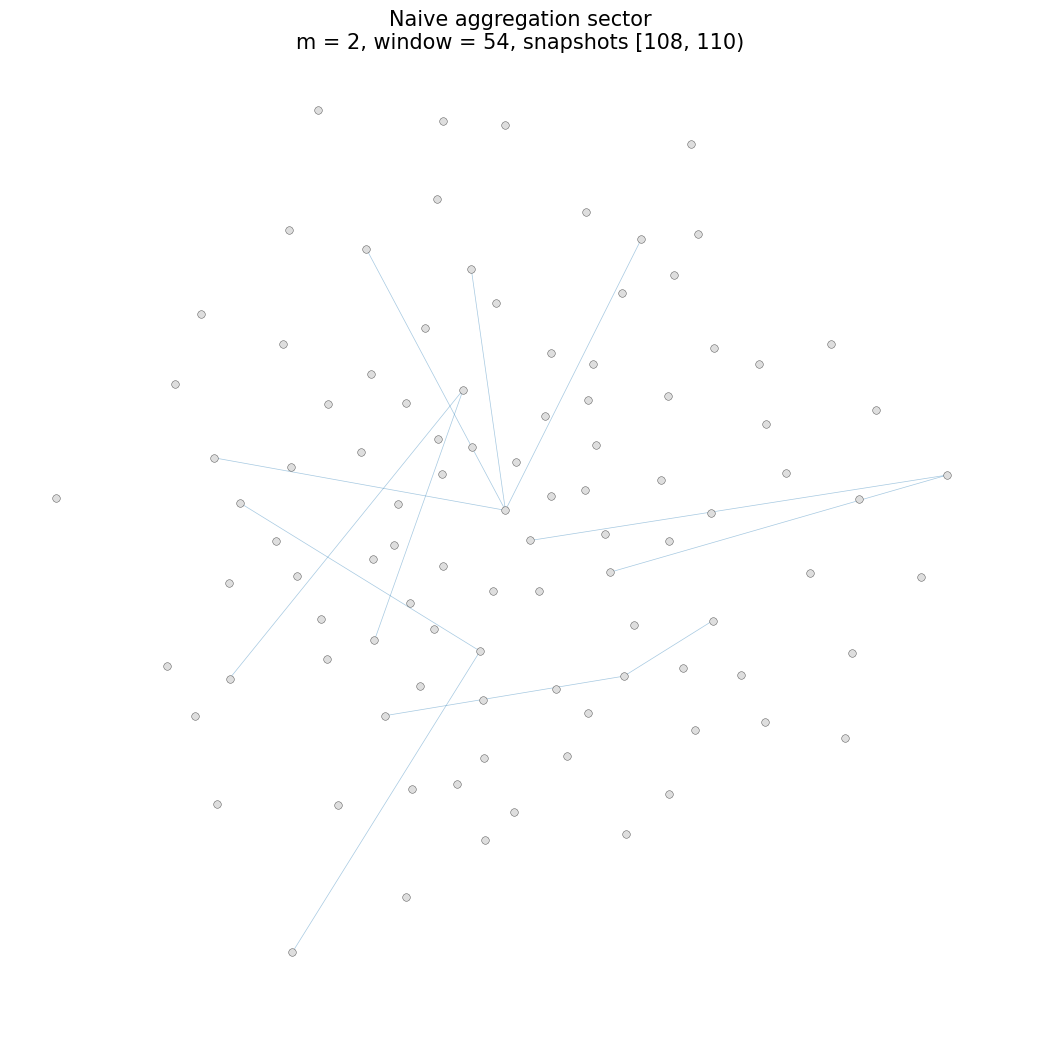

  [3/4] single commutator...
      saved: stage7_scaling_outputs\effective_w002_idx054_single_commutator.png


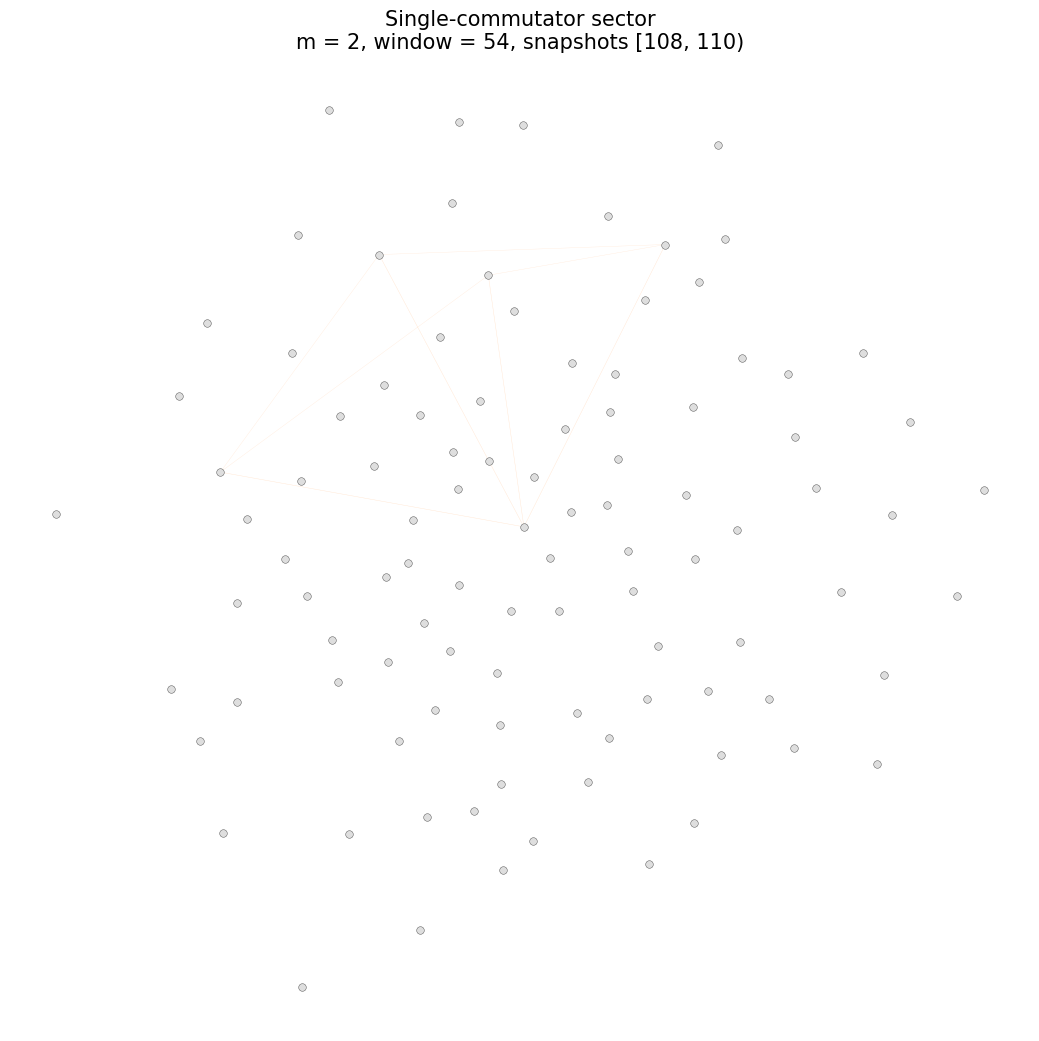

  [4/4] double commutator...
      saved: stage7_scaling_outputs\effective_w002_idx054_double_commutator.png


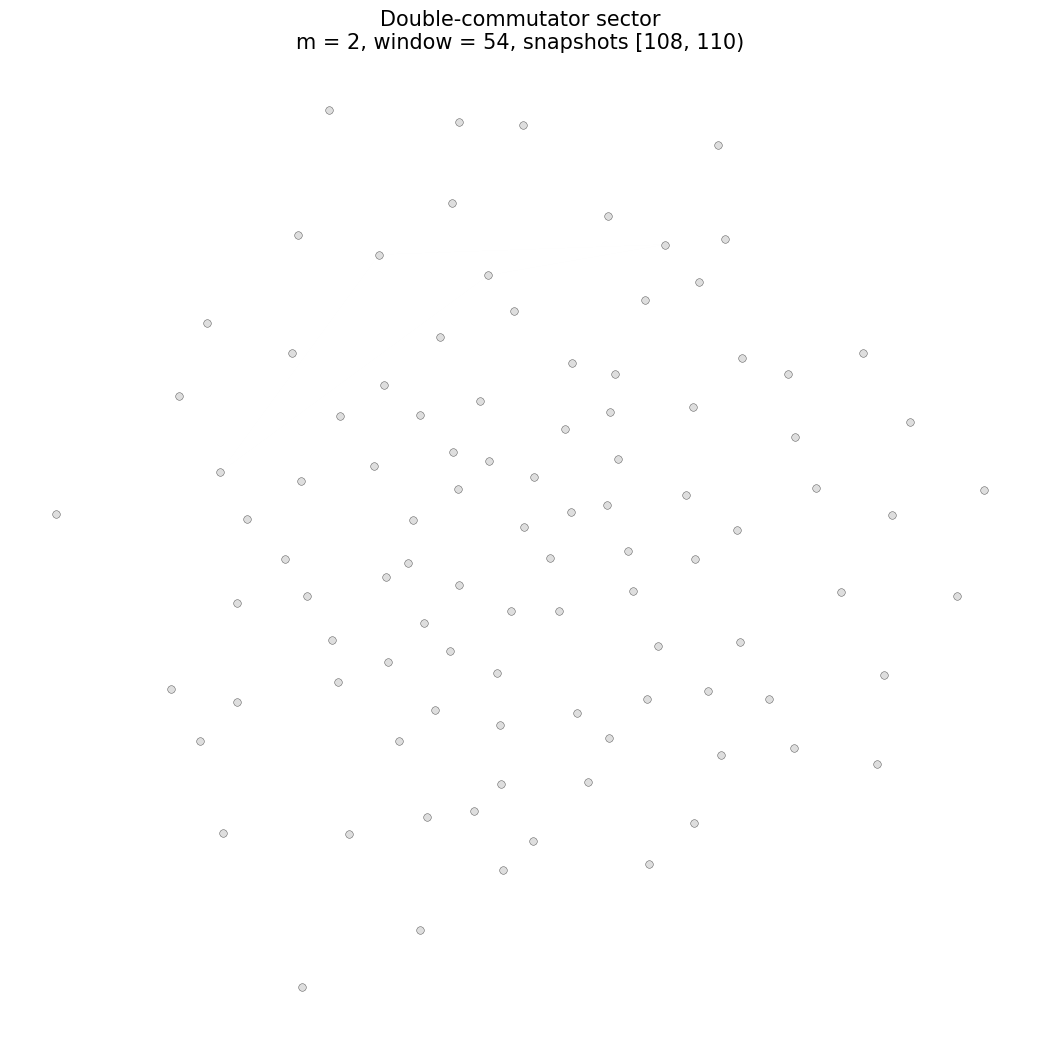

  done.

Plotting m=2, idx=63, snapshots [126, 128)

Effective decomposition: m=2, idx=63
  snapshots : [126, 128)
  time      : [6.300, 6.400)

Edge-source statistics


,sector,count,mean,median,q75,q90,q95,max,l2,fraction_of_all_pairs
0,naive,15,0.533333,0.500000,0.500000,0.500000,0.650000,1.000000,2.121320,0.003030
1,commutator,11,0.014773,0.012500,0.012500,0.025000,0.025000,0.025000,0.051539,0.002222
2,nested,18,0.000278,0.000208,0.000313,0.000552,0.000641,0.000729,0.001413,0.003636
3,BCH_total,29,0.278188,0.500000,0.500000,0.500562,0.501062,1.000495,2.122487,0.005859
4,exact_total,31,0.260241,0.012534,0.500000,0.500469,0.501040,1.000494,2.122486,0.006263
5,comm_generated_only,5,0.012500,0.012500,0.012500,0.012500,0.012500,0.012500,0.027951,0.001010
6,nested_generated_only,9,0.000139,0.000104,0.000208,0.000208,0.000208,0.000208,0.000442,0.001818


Saved source statistics: stage7_scaling_outputs\effective_w002_idx063_source_statistics.csv

  [1/4] total (overlay)...
      saved: stage7_scaling_outputs\effective_w002_idx063_total_overlay.png


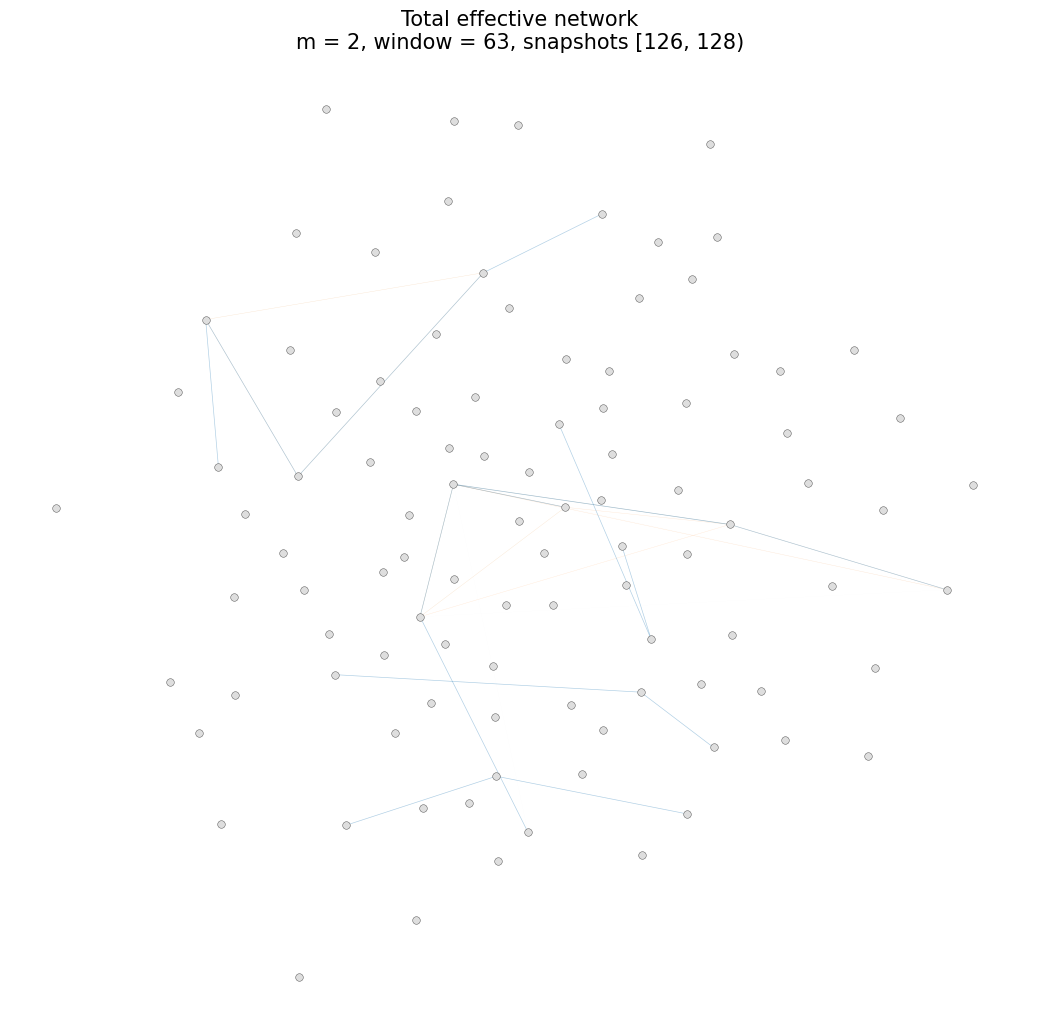

  [2/4] naive...
      saved: stage7_scaling_outputs\effective_w002_idx063_naive.png


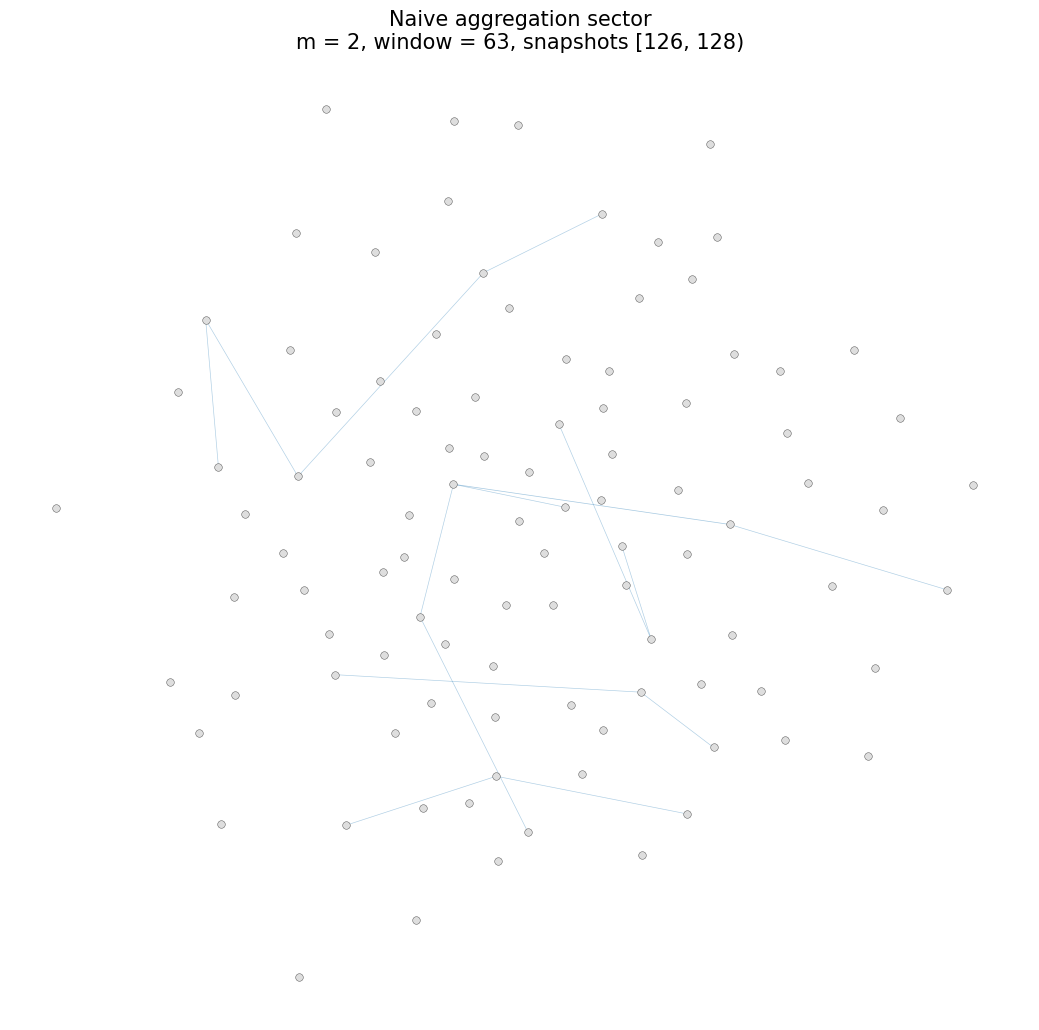

  [3/4] single commutator...
      saved: stage7_scaling_outputs\effective_w002_idx063_single_commutator.png


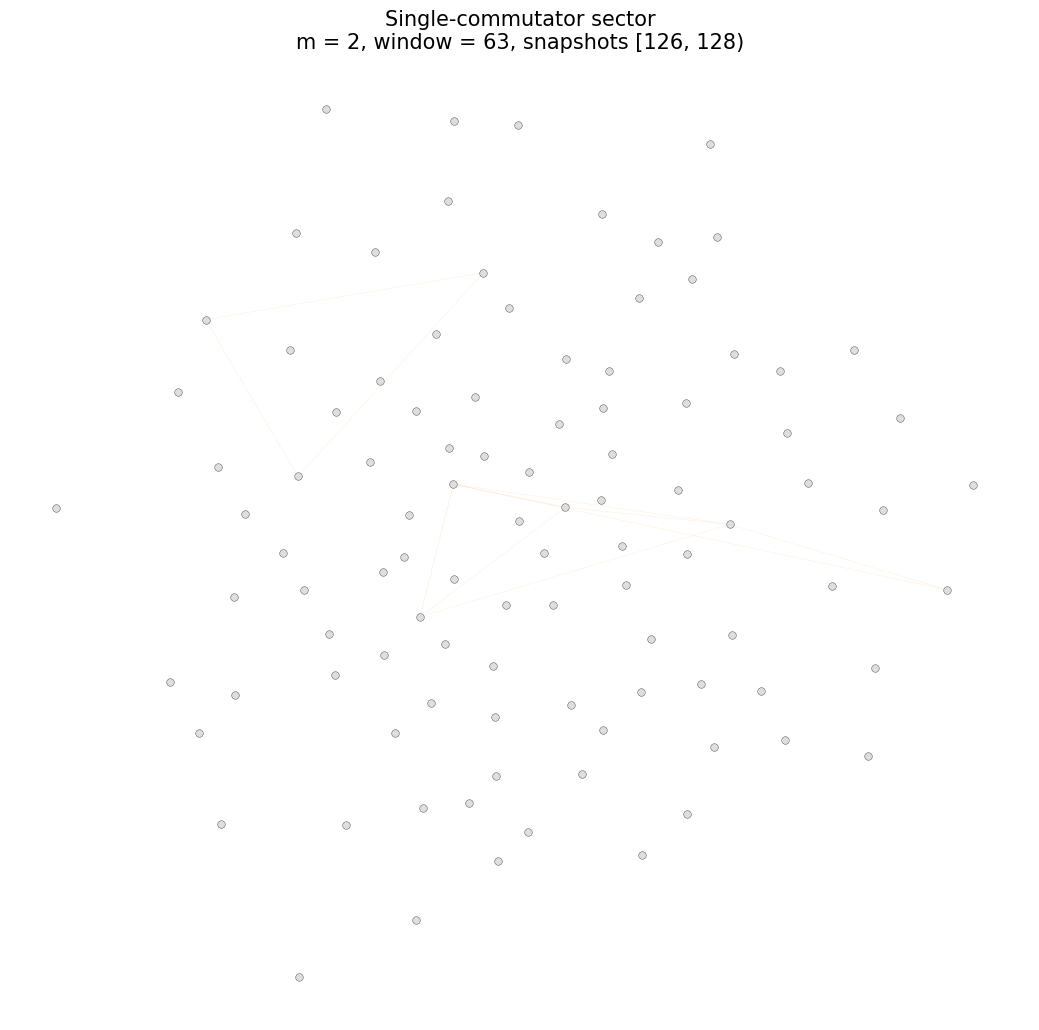

  [4/4] double commutator...
      saved: stage7_scaling_outputs\effective_w002_idx063_double_commutator.png


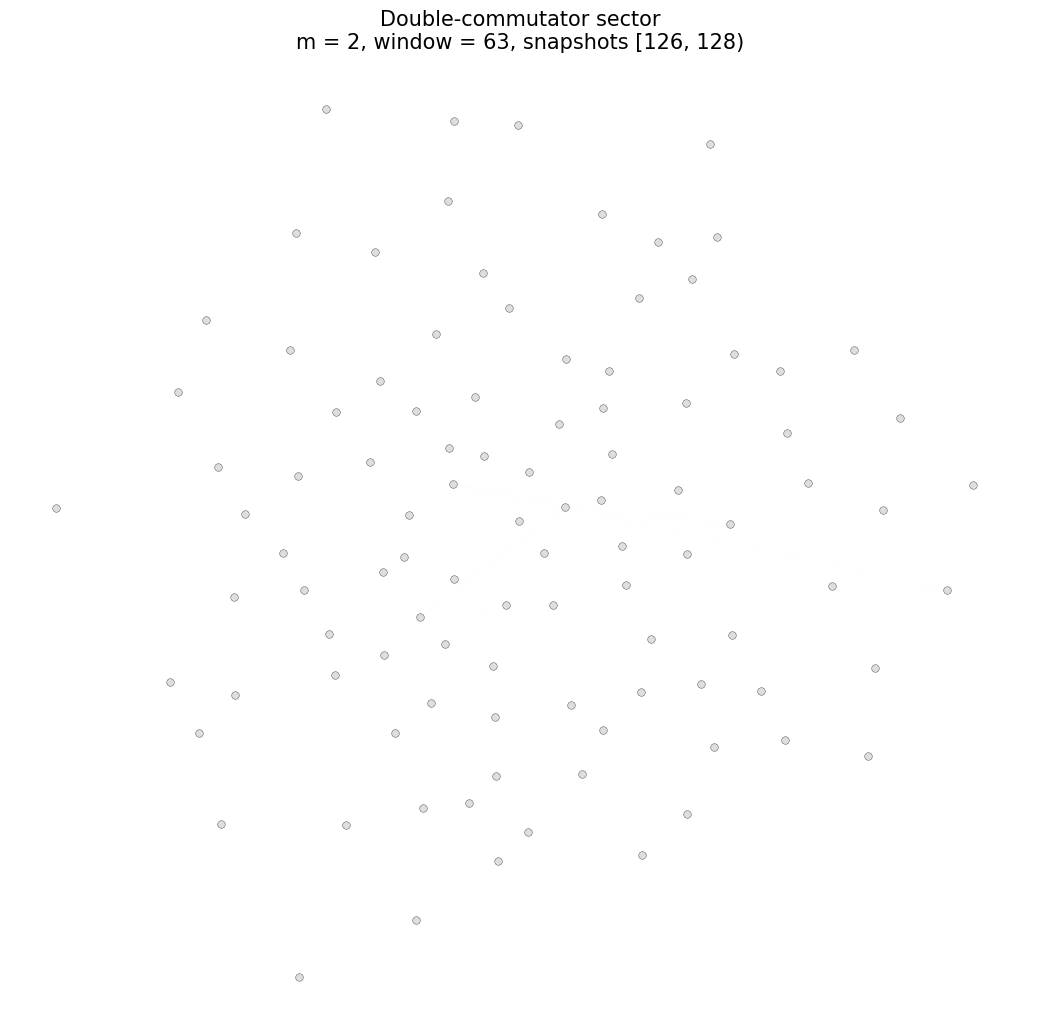

  done.

Saved selected-window table to: stage7_scaling_outputs\fixed_interval_effective_windows_overlay.csv


In [28]:
# ============================================================
# Cell 10b — Plot 8 evenly spaced effective networks (overlay)
# ============================================================

WINDOW_SIZES_TO_PLOT = [2]
N_SELECT = 8

all_selected_tables = []

for m in WINDOW_SIZES_TO_PLOT:

    print()
    print("=" * 60)
    print(f"Fixed-interval effective networks | m = {m}")
    print("=" * 60)

    table_m = fixed_interval_window_table(
        window_size=m,
        n_select=N_SELECT
    )

    display(table_m)

    all_selected_tables.append(table_m)

    for row in table_m.itertuples(index=False):

        print()
        print(
            f"Plotting m={row.window_size}, "
            f"idx={row.window_idx}, "
            f"snapshots [{row.start_snapshot}, {row.end_snapshot})"
        )

        _ = plot_effective_decomposition(
            result=effective_by_scale[m][row.window_idx],
            window_size=m,
            window_idx=row.window_idx,
            pos=pos,
            total_mode="overlay",
            show=True
        )


# Save the selected-window tables
selected_windows_df = pd.concat(
    all_selected_tables,
    ignore_index=True
)

selected_windows_csv = (
    OUTDIR /
    "fixed_interval_effective_windows_overlay.csv"
)

selected_windows_df.to_csv(
    selected_windows_csv,
    index=False
)

print()
print(f"Saved selected-window table to: {selected_windows_csv}")